Las tres clases analizadas y comparadas

In [1]:
import os, sys, re, math, h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
# Get the parent directory
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)

from class_analysis import metrics_creator, plot_roman_rubin_plt, graph_maker, create_df_to_plot
from fit_lc import model_rubin_roman
from fit_lc import fit_rubin_roman
from pyLIMA.outputs import pyLIMA_plots
sys.path.append(os.path.dirname(os.getcwd()))
from read_save import read_data

from bokeh.plotting import figure, show, output_file
from bokeh.layouts import gridplot, row, column
from bokeh.io import export_png
from plot_saveLC import plot_n_save
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import corner
import seaborn as sns
import matplotlib.lines as mlines

from tqdm.auto import tqdm
from connect_CHE_private_account import download_data

Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [2]:
param_latex = lambda p: fr"$\frac{{\left|{{{{{p}}}}}^{{\text{{fit}}}} - {{{{{p}}}}}^{{{{true}}}}\right|}}{{{{{{{p}}}}}^{{\text{{true}}}}}}$"
dictionary_class = {'USBL': 'Planets bounded', 'PSPL':'Stellar Mass Black Holes', 'FSPL':'Free Floating Planets'}
category_colors = {'A': 'royalblue', 'B': 'darkorange', 'C': 'cyan', 'D': 'crimson'}
category_names = {'A': 'Roman + Rubin', 'B': ' Rubin', 'C': ' Roman' , 'D': 'None'}

relative_bias = {
    "rho":      r"$\frac{|\rho - \hat{\rho}|}{\rho}$",
    "pi_E":     r"$\frac{|\pi_E - \hat{\pi}_E|}{\pi_E}$",
    "t_E":      r"$\frac{|t_E - \hat{t}_E|}{t_E}$",
    "u_0":      r"$\frac{|u_0 - \hat{u}_0|}{u_0}$",
    "t_0":      r"$\frac{|t_0 - \hat{t}_0|}{t_0}$",
    "alpha":    r"$\frac{|\alpha - \hat{\alpha}|}{\alpha}$",
    "q":        r"$\frac{|q - \hat{q}|}{q}$"
}

In [3]:
# Directorios base
base_path = os.path.join(parent_directory, 'all_results')
models = ['FSPL_3', 'USBL_6','PSPL_3']
suffixes = ['true', 'fit_rr', 'fit_roman']

# Carga de datos
data = {}
for model in models:
    model_key = model.split('_')[0]  # 'FSPL' o 'USBL'
    model_path = os.path.join(base_path, model)
    data[model_key] = {
        suffix: pd.read_csv(os.path.join(model_path, f'{suffix}.csv'))
        for suffix in suffixes
    }
    data[model_key]['true']['piE'] = np.sqrt(data[model_key]['true']['piEE']**2+data[model_key]['true']['piEN']**2)

# Cálculo de métricas
metrics = {}
for model_key, fits in data.items():
    metrics[model_key] = {}
    for fit_key in ['fit_rr', 'fit_roman']:
        metrics[model_key][fit_key] = metrics_creator(
            fits['true'], fits[fit_key], model_key
        )

# Armado del MultiIndex DataFrame
index_tuples = []
values = []
for model_key, fits in metrics.items():
    for fit_key, metric_tuple in fits.items():
        index_tuples.append((model_key, fit_key))
        values.append(metric_tuple)
multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['model', 'fit'])
df_metrics = pd.DataFrame(values, index=multi_index, columns=['metric1', 'metric2', 'metric3'])

In [4]:
# path = parent_directory+'/all_results/PSPL_1/'
# fit_rr = pd.read_csv(path+"/fit_rr.csv", engine='python')
# fit_roman =  pd.read_csv(path+"/fit_roman.csv", engine='python')
# true = pd.read_csv(path+"/true.csv", engine='python')
# true['piE']=np.sqrt(true['piEE']**2+true['piEN']**2)
# met_1, met_2, met_3 = metrics_creator(true, fit_rr, 'USBL')

In [5]:
# plt.hist(true['t0'])

# print(abs(max(true['t0'])-min(true['t0']))/365)

# How it look the distributions for $\chi^2$ in the three datasets PSPL,FSPL,USBL

In [6]:

for Class in ['FSPL','PSPL','USBL']:
    arr = data[Class]['fit_rr']['chichi'] / data[Class]['fit_rr']['dof']
    aroman = data[Class]['fit_roman']['chichi'] / data[Class]['fit_roman']['dof']
    print('Percentage of',Class,'lightcurves fitted using Roman+Rubin data with chi^2 <2  : ',100*len(arr[arr<2])/len(arr), '%')
    print('Percentage of',Class,'lightcurves fitted using Roman data with chi^2 <2  : ',100*len(aroman[aroman<2])/len(aroman), '%')
    print('')

Percentage of FSPL lightcurves fitted using Roman+Rubin data with chi^2 <2  :  99.88905566795015 %
Percentage of FSPL lightcurves fitted using Roman data with chi^2 <2  :  100.0 %

Percentage of PSPL lightcurves fitted using Roman+Rubin data with chi^2 <2  :  99.25776965265082 %
Percentage of PSPL lightcurves fitted using Roman data with chi^2 <2  :  100.0 %

Percentage of USBL lightcurves fitted using Roman+Rubin data with chi^2 <2  :  99.40670783387819 %
Percentage of USBL lightcurves fitted using Roman data with chi^2 <2  :  100.0 %



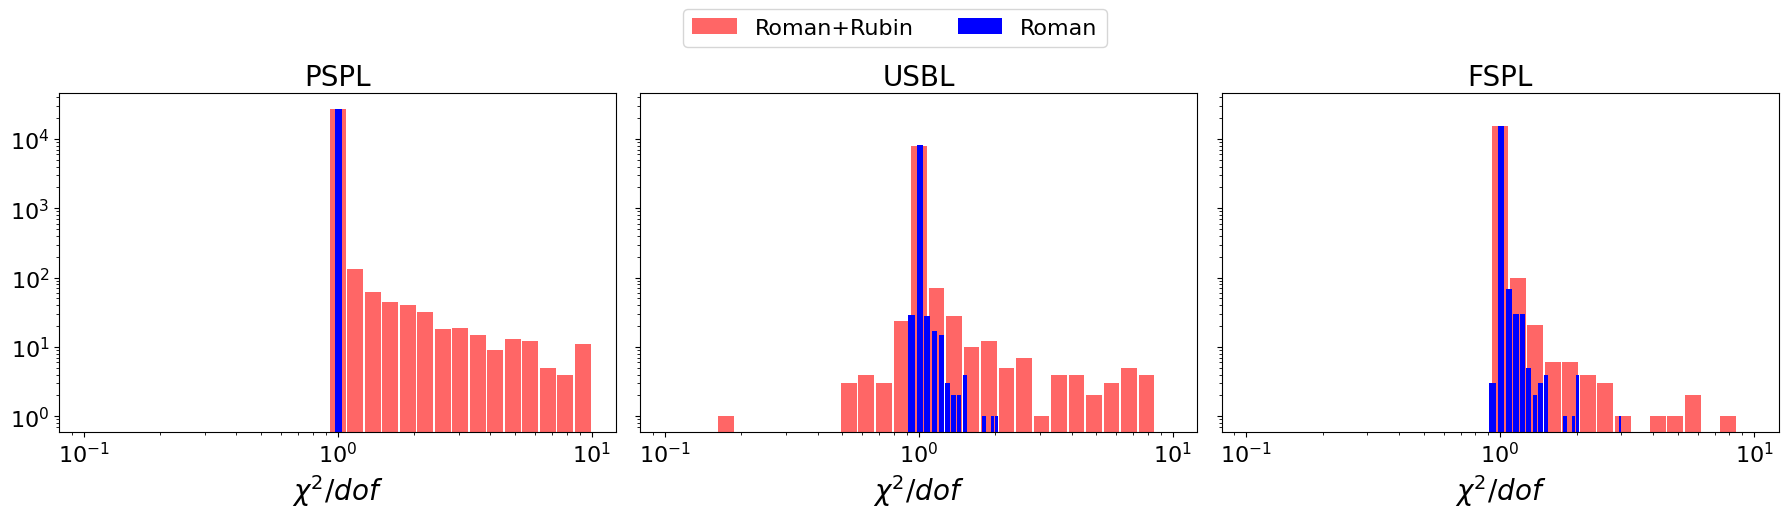

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# PSPL
pspl_rr = data['PSPL']['fit_rr']['chichi'] / data['PSPL']['fit_rr']['dof']
pspl_rom = data['PSPL']['fit_roman']['chichi'] / data['PSPL']['fit_roman']['dof']
h1 = axes[0].hist(pspl_rr, bins=np.logspace(-1, 1, 30), rwidth=0.9, color='red',alpha=0.6, label='Roman+Rubin')
h2 = axes[0].hist(pspl_rom, bins=np.linspace(0.9, 3, 30), rwidth=0.8, color='blue', label='Roman')

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('PSPL', fontsize=20)

# USBL
axes[1].hist(data['USBL']['fit_rr']['chichi'] / data['PSPL']['fit_rr']['dof'],
             bins=np.logspace(-1, 1, 30), color='red', rwidth=0.9,alpha=0.6)
axes[1].hist(data['USBL']['fit_roman']['chichi'] / data['PSPL']['fit_roman']['dof'],
             bins=np.linspace(0.9, 3, 30), rwidth=0.8, color='blue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('USBL', fontsize=20)

# FSPL
axes[2].hist(data['FSPL']['fit_rr']['chichi'] / data['PSPL']['fit_rr']['dof'],
             bins=np.logspace(-1, 1, 30), color='red',alpha=0.6, rwidth=0.9)
axes[2].hist(data['FSPL']['fit_roman']['chichi'] / data['PSPL']['fit_roman']['dof'],
             bins=np.linspace(0.9, 3, 30), rwidth=0.8, color='blue')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title('FSPL', fontsize=20)

for ax in axes:
    ax.set_xlabel('$\chi^2/dof$', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    # ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Global legend at top center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=16, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at the top for legend
plt.savefig('/home/anibal-pc/results_roman_rubin/chi2.png')
plt.show()


In [8]:
# data['USBL']['true']

# We can estimate the number of events that hit the boundaries set for the fit in each category

**${\bf Plot \ all \ metrics:}$**

Here we compare the three classes: FFP, BH, and USBL, within the same category and for the same metric evaluated on the same parameter.

**Notation:**
- True parameter: $p$  
- Estimated parameter: $\hat{p}$

For a parameter $p \in (t_E, \rho, \pi_{EE}, \pi_{EN}, \alpha, s, q)$, the interval in which the maximum of the likelihood is found is $[p - |p|, p + |p|]$.

We focus on the metric called Bias Relative to the True value:
$$
BRT(p) = \frac{|p - \hat{p}|}{p}.
$$

This metric ranges within the interval $0 \leq \frac{|p - \hat{p}|}{p} \leq 1$.  
A value close to 1 implies that the estimated parameter $\hat{p}$ lies near the boundary of the allowed interval.

If we want to determine when $\hat{p}$ is near the boundaries—specifically when $BRT(p) > 0.9$—this corresponds to:
$$
\hat{p} \in [0, 0.1p] \cup [1.9p, 2p].
$$

### Example:
For a typical case with $t_E = 100$ days:


\begin{aligned}
BRT(t_E) &= \frac{|t_E - \hat{t}_E|}{t_E} = \frac{|100 - \hat{t}_E|}{100} > 0.9 \\
1 &> \frac{|100 - \hat{t}_E|}{100} > 0.9 \\
100 &> |100 - \hat{t}_E| > 90 \\
\Rightarrow \hat{t}_E &\in (0, 10) \cup (190, 200)
\end{aligned}


With the following code, we identify the events where the estimated parameters $\hat{t}_E$, $\hat{\pi}_{EE}$, and $\hat{\pi}_{EN}$ satisfy $BRT > 0.9$.  
We separate the results by category, based on how the primary peak intersects with the observing seasons of the two surveys.

These three parameters were chosen because they are the only ones shared across all three models we considered.


/tmp/ipykernel_115830/2025017084.py:40: RuntimeWarning: Mean of empty slice
  sorted_classes = sorted(classes, key=lambda c: np.nanmean([
/tmp/ipykernel_115830/2025017084.py:40: RuntimeWarning: Mean of empty slice
  sorted_classes = sorted(classes, key=lambda c: np.nanmean([
/tmp/ipykernel_115830/2025017084.py:40: RuntimeWarning: Mean of empty slice
  sorted_classes = sorted(classes, key=lambda c: np.nanmean([


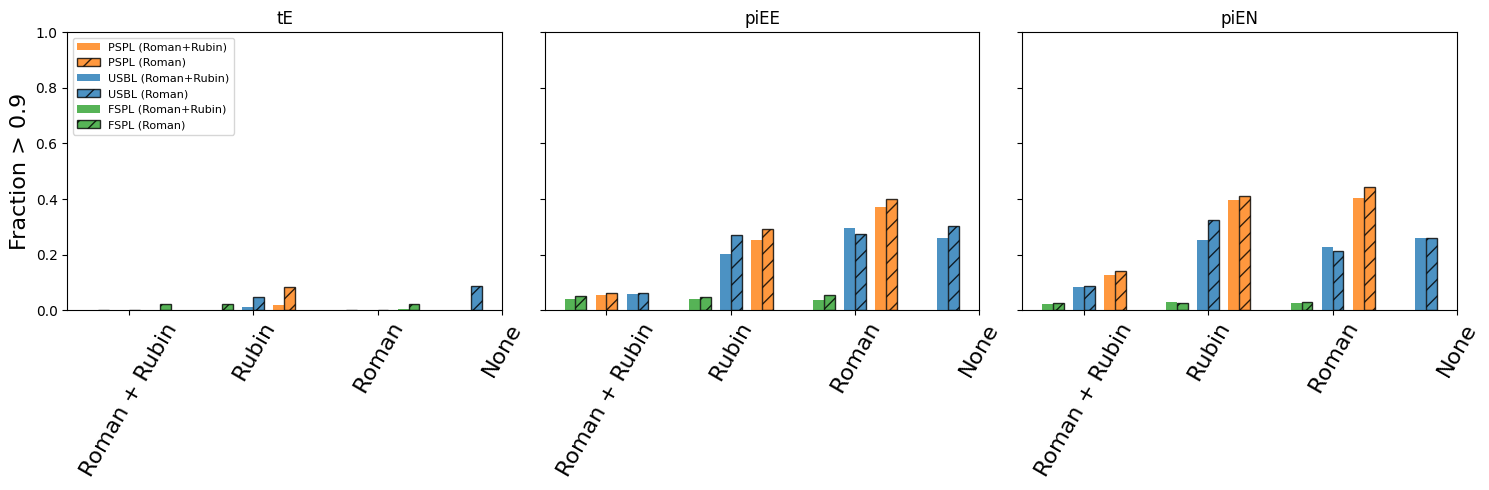

In [9]:
categories = ['A', 'B', 'C', 'D']
classes = ['USBL', 'PSPL', 'FSPL']
params = ['tE', 'piEE', 'piEN']

# Define color for each Class
class_colors = {
    'USBL': 'tab:blue',
    'PSPL': 'tab:orange',
    'FSPL': 'tab:green'
}

data_plot = {p: {cat: {} for cat in categories} for p in params}

# Fill in the data
for p in params:
    for cat in categories:
        for Class in classes:
            mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == cat
            df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
            df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]

            rr_values = df1[p]
            roman_values = df2[p]
            rr_frac = (rr_values > 0.9).sum() / len(rr_values) if len(rr_values) > 0 else np.nan
            roman_frac = (roman_values > 0.9).sum() / len(roman_values) if len(roman_values) > 0 else np.nan

            data_plot[p][cat][Class] = {'fit_rr': rr_frac, 'fit_roman': roman_frac}

# Plot sorted
fig, axs = plt.subplots(1, len(params), figsize=(15, 5), sharey=True)
width = 0.35

for i, p in enumerate(params):
    ax = axs[i]
    xtick_positions = []
    xtick_labels = []

    for xi, cat in enumerate(categories):
        # Sort class order by average
        sorted_classes = sorted(classes, key=lambda c: np.nanmean([
            data_plot[p][cat][c]['fit_rr'], data_plot[p][cat][c]['fit_roman']
        ]))
        x_base = xi * (len(classes) + 1)

        for j, Class in enumerate(sorted_classes):
            x_pos = x_base + j
            rr_val = data_plot[p][cat][Class]['fit_rr']
            roman_val = data_plot[p][cat][Class]['fit_roman']
            color = class_colors[Class]

            # RR (Rubin + Roman)
            ax.bar(x_pos - width/2, rr_val, width=width, color=color,
                   label=f'{Class} (Roman+Rubin)' if (xi == 0 and i == 0) else "", alpha=0.8)

            # R (solo Roman)
            ax.bar(x_pos + width/2, roman_val, width=width, color=color,
                   hatch='//', edgecolor='k', label=f'{Class} (Roman)' if (xi == 0 and i == 0) else "", alpha=0.8)

        # xticks
        center_pos = x_base + (len(classes) - 1) / 2
        xtick_positions.append(center_pos)
        xtick_labels.append(category_names[cat])

    ax.set_title(p)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=16, rotation=60)
    # print(xtick_labels)
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel('Fraction > 0.9', fontsize=16)
    
# Solo una leyenda
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles, labels, fontsize=8)

plt.tight_layout()

plt.savefig('/home/anibal-pc/results_roman_rubin/hit_bound_tE_piEN_piEE.png')
plt.show()


## How it looks these events


In [10]:
Class = 'PSPL'
p='piE'
# mask = (data['FSPL']['true']['crit_FFP_Rubin']==True) & 
mask = (data[Class]['true']['Category']=='B')#df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'A'
df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
df1
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources = df1[df1[p]>0.9].head(3)['Source'].values
candidates = df1[(df1[p]>0.9)].head(3)
display(candidates)
sources =candidates['Source'].values
sets = candidates['Set'].values
# sources= [i-i*int(i/10000) for i in ids]
print(sources)
print(sets)
download_data(sources, Class)


,id,Source,Set,Category,mass,sel_crit,t0,u0,tE,piEN,piEE,piE
1,10003,3,1,B,71.10663443919233 solMass,True,6.216150e-09,1.000000,0.006598,-1.000000,0.930867,0.945032
10,10015,15,1,B,18.710696567178857 solMass,True,1.810686e-09,-0.993691,0.160050,-0.999993,-0.999970,0.999971
28,10043,43,1,B,61.297587388668646 solMass,True,2.015186e-07,-1.000000,0.023890,-1.000000,1.000000,1.000000


[ 3 15 43]
[1 1 1]


  0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# I previously download these events
sources = np.array([26, 51, 88])
sets = np.array([1,1,1])
"""
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'USBL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'USBL')

# axes[0].annotate(f"|| = "+f" {round(chi2_rr/DOF_rr,3)}", 
#              xy=(xcoor, 0.4), xycoords='axes fraction',
#              ha='center', va='bottom',
#              fontsize=10, fontweight='bold')
plt.suptitle('Events that hit the boundaries in $\pi_E$.\nPlanetary systems (binary lens).\nOverlap Roman+Rubin',fontsize=20)
plt.tight_layout()

In [ ]:
# I previously download these events


sources = np.array([1032, 1355, 1410])
sets = np.array([1,1,1])
"""
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{t}_\mathrm{E} - \hat{\boldsymbol{t}}_\mathrm{E}|}{t_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'USBL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'USBL')

plt.suptitle('Events that hit the boundaries in $t_E$ (Roman).\nPlanetary systems (binary lens).\nOverlap Roman+Rubin',fontsize=20)
plt.tight_layout()

In [ ]:
sources = np.array([131772, 132218, 132369])
sets = np.array([1,1,1])
"""
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'FSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')

plt.suptitle('Events that hit the boundaries in $\pi_E$.\nPlanetary systems (Free Floating Planet).\nOverlap Roman+Rubin',fontsize=20)   
plt.tight_layout()    

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the t

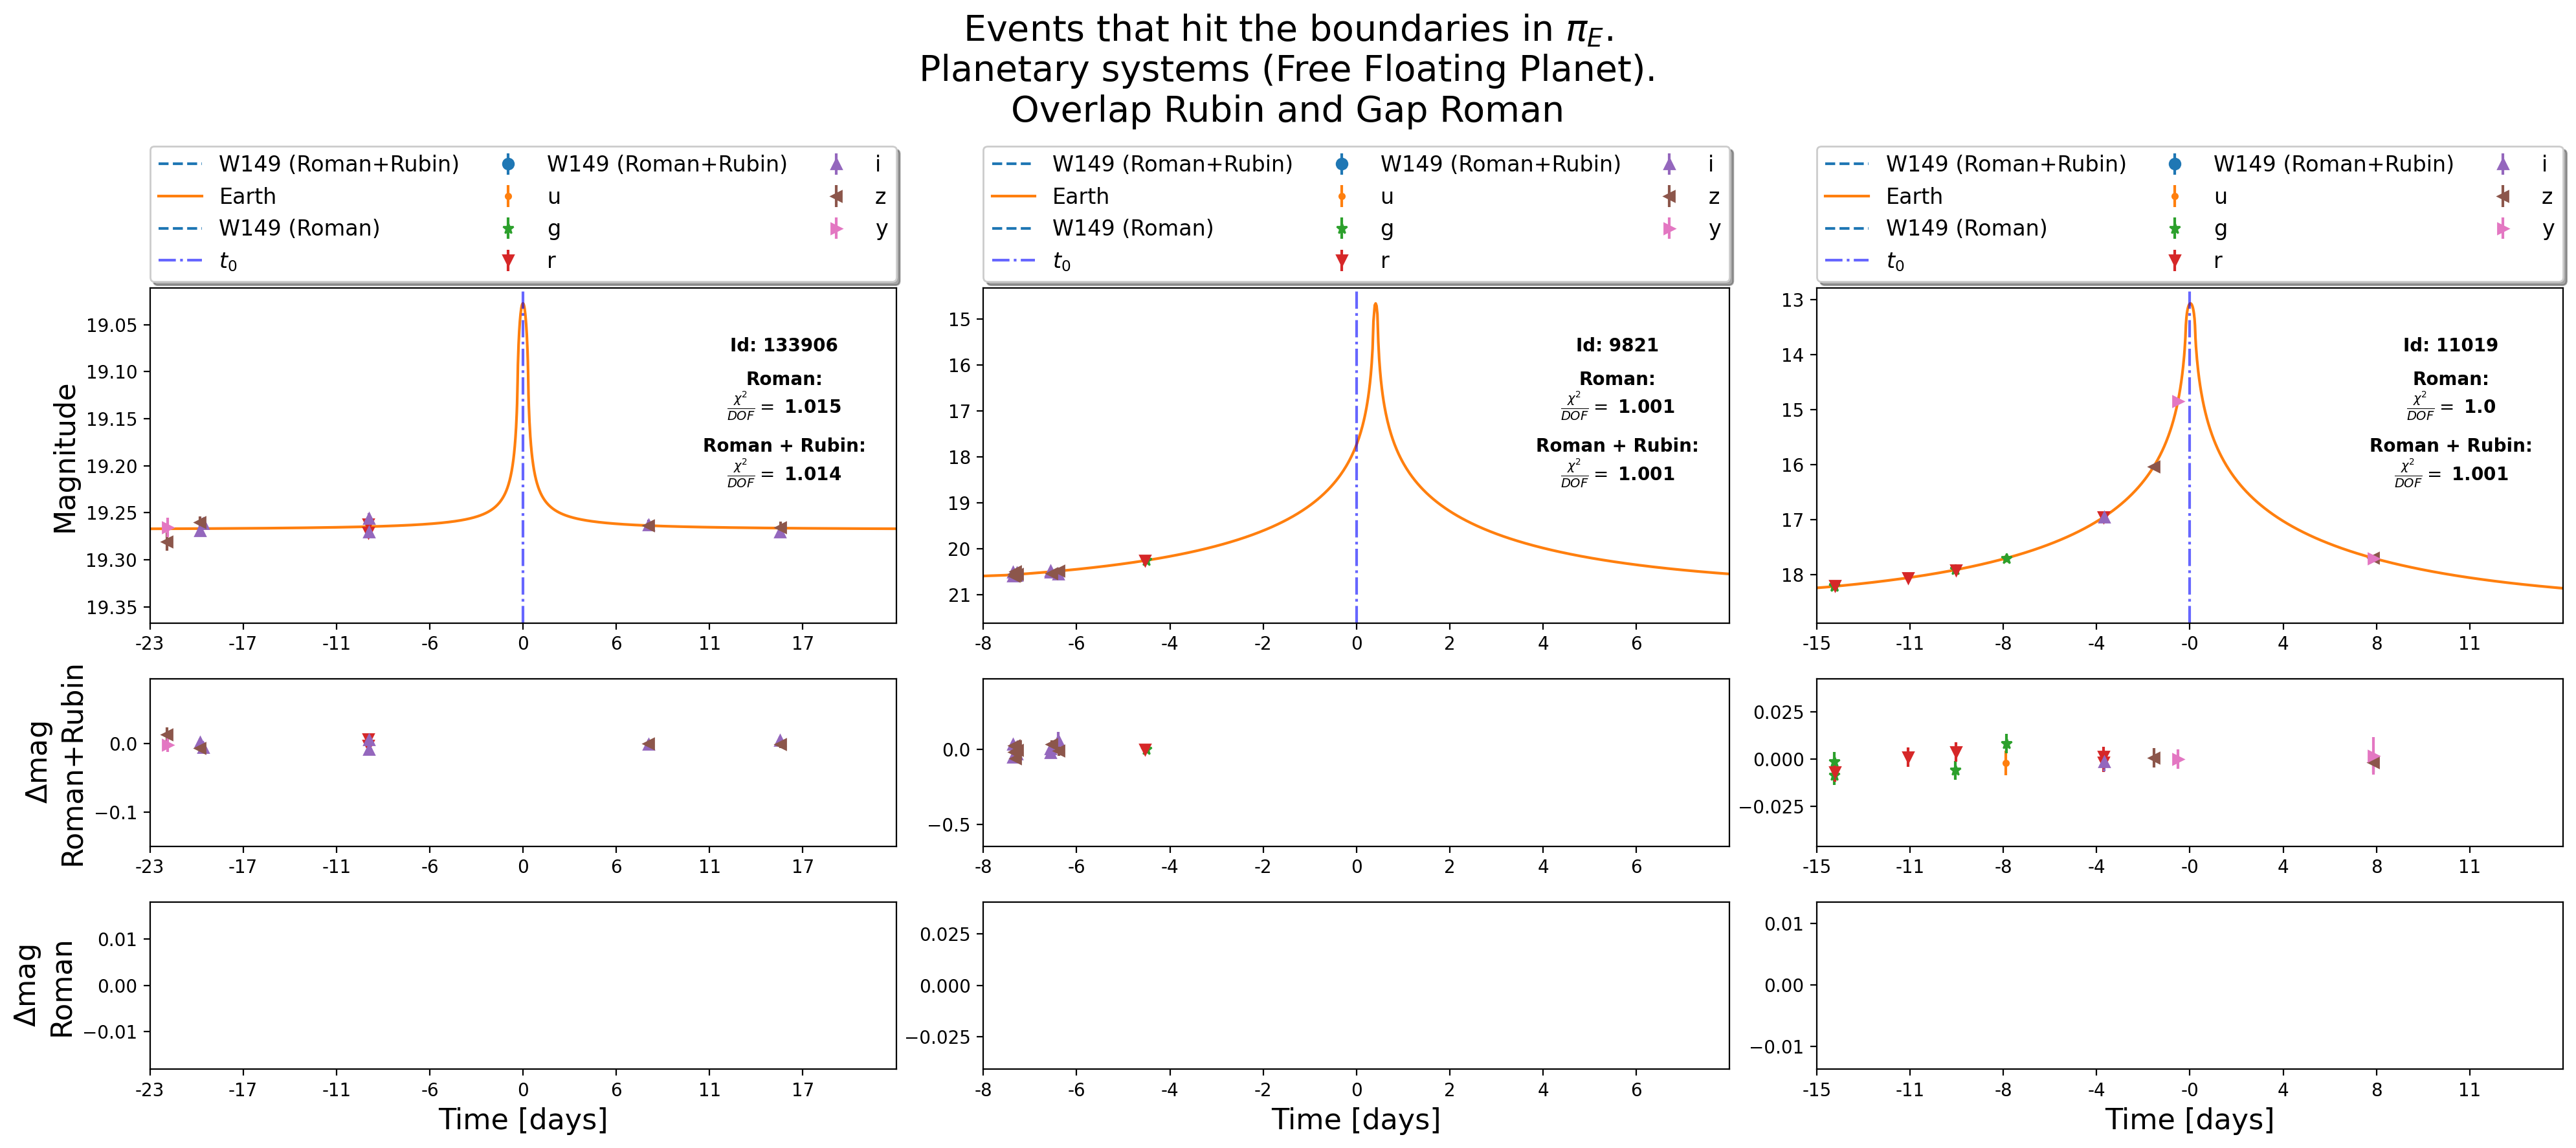

In [41]:

sources = np.array([133906, 9821, 11019])
sets = np.array([1,1,1])
"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'FSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')

# Class = 'FSPL'
# p='piE'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# sources =df1[(df1[p]>0.9) & (data['FSPL']['true']['crit_FFP_Rubin']==True)]['Source'].head(3).values
# df_to_plot = create_df_to_plot(sources, 'FSPL')   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')   
plt.suptitle('Events that hit the boundaries in $\pi_E$.\nPlanetary systems (Free Floating Planet).\nOverlap Rubin and Gap Roman',fontsize=20)   
plt.tight_layout()    

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the t

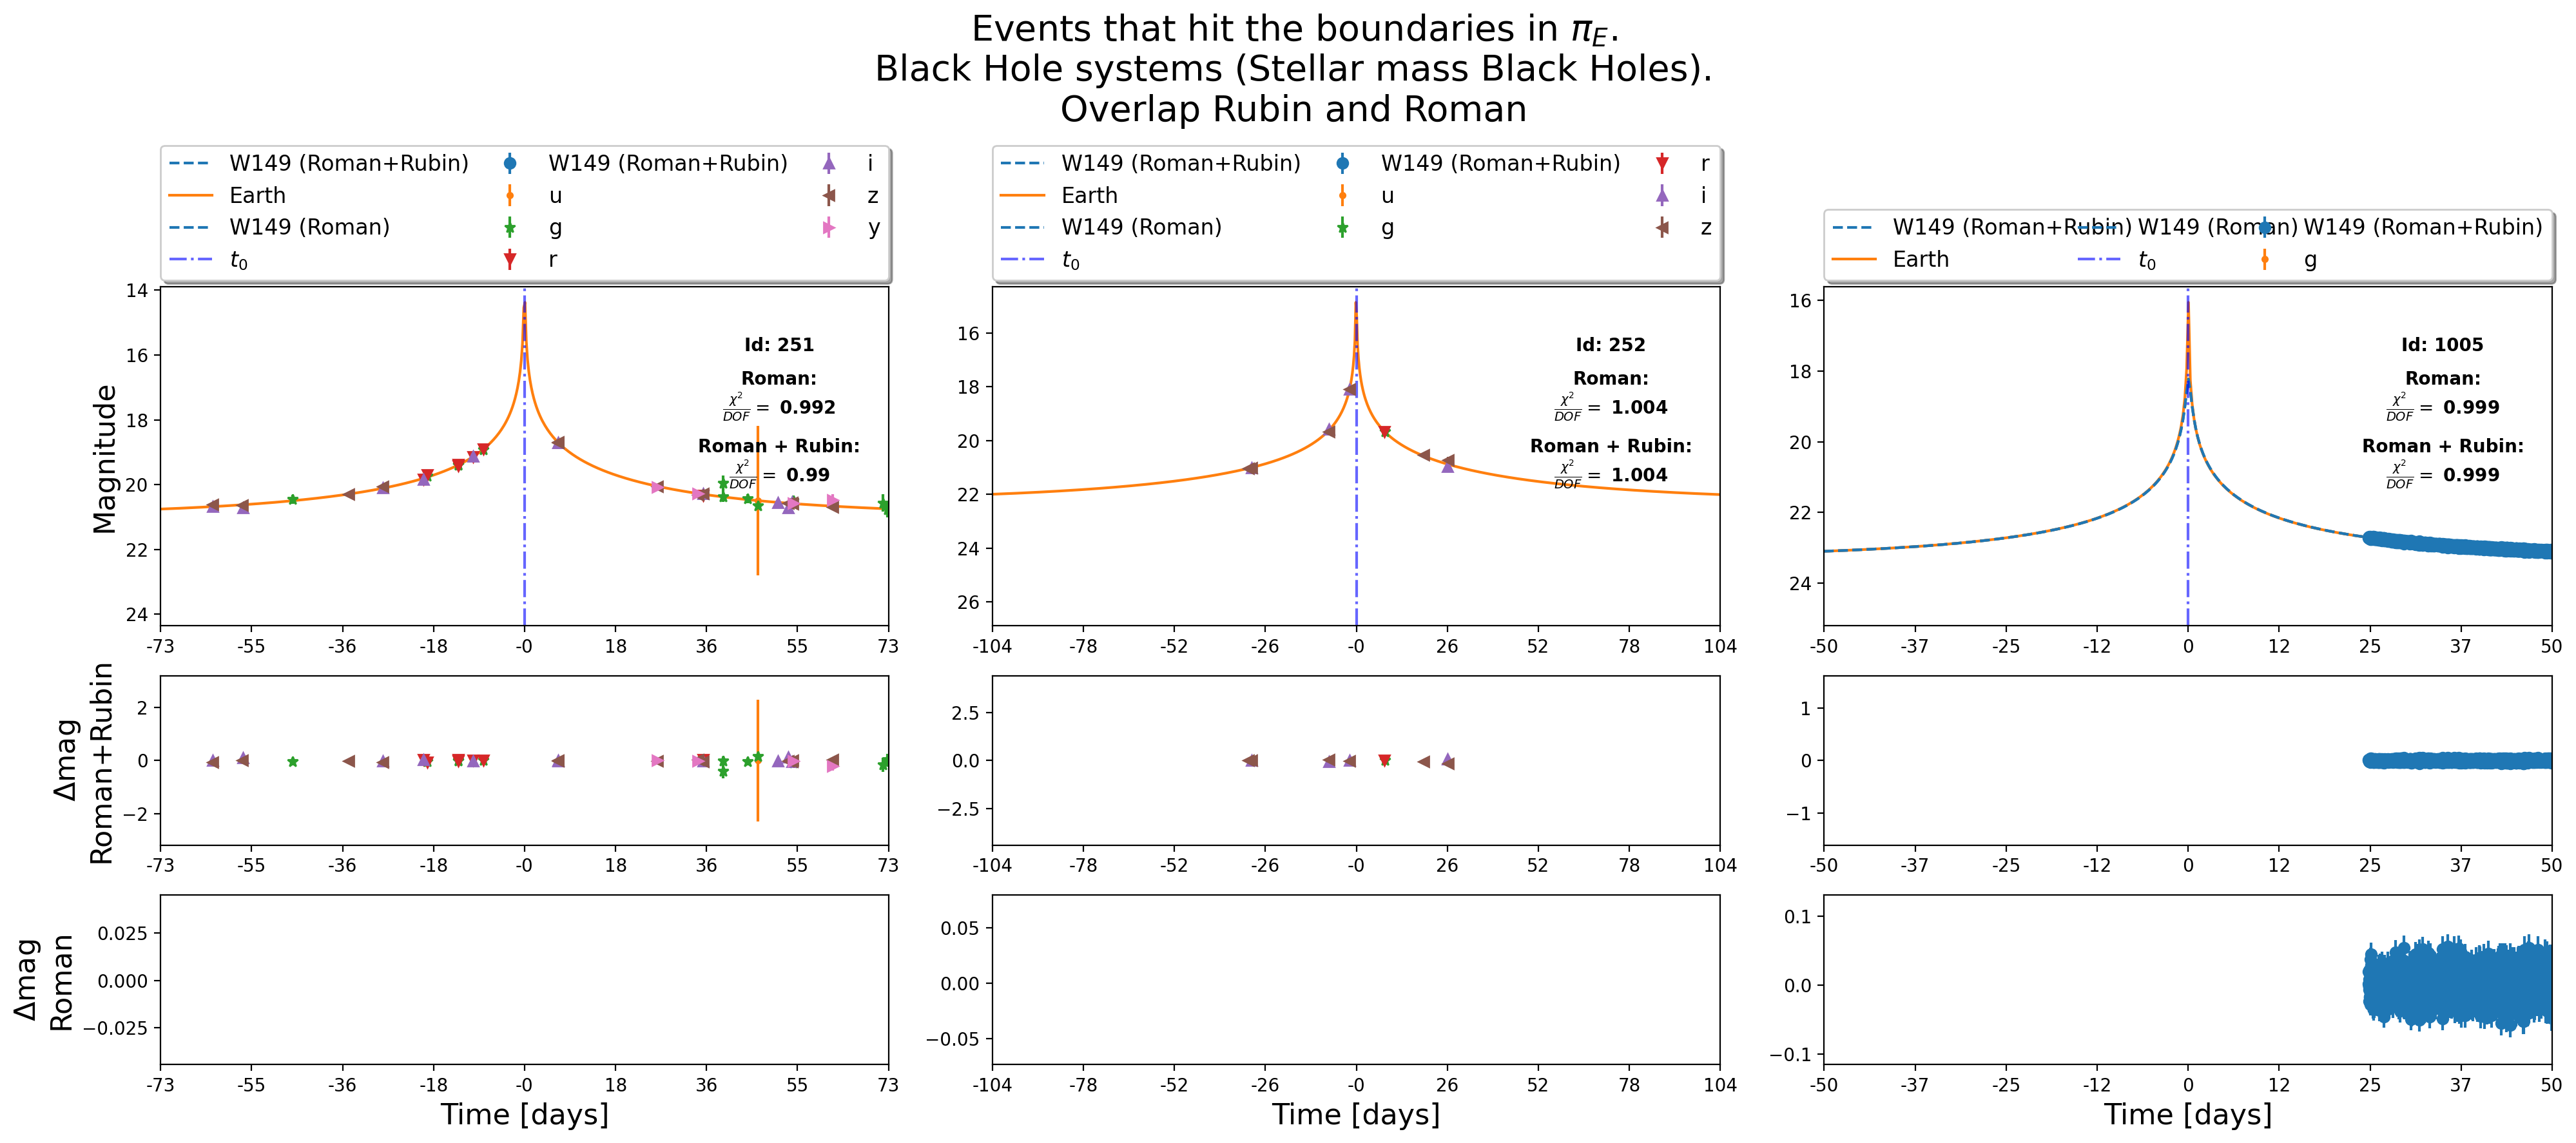

In [6]:

sources = np.array([251, 252, 1005])
sets = np.array([1,1,1])
"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'PSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'PSPL')

plt.suptitle('Events that hit the boundaries in $\pi_E$.\nBlack Hole systems (Stellar mass Black Holes).\nOverlap Rubin and Roman',fontsize=20)   
plt.tight_layout()    

# Parallax: We analize $\pi_E$
We can use the notation $\hat{p}$ for the estimated parameter from the lightcurve fit and just $p$ for the true parameter.

We can study how the parallax is recovered as function of the time scale $t_E$

Here we call "Primary peak" to the peak produced in $[t_0-t_E,t_0+t_E]$ 

. 

Secondary peak will be the one produced in binary lensing produced in $t_{center}$ (CROIN parametrization).

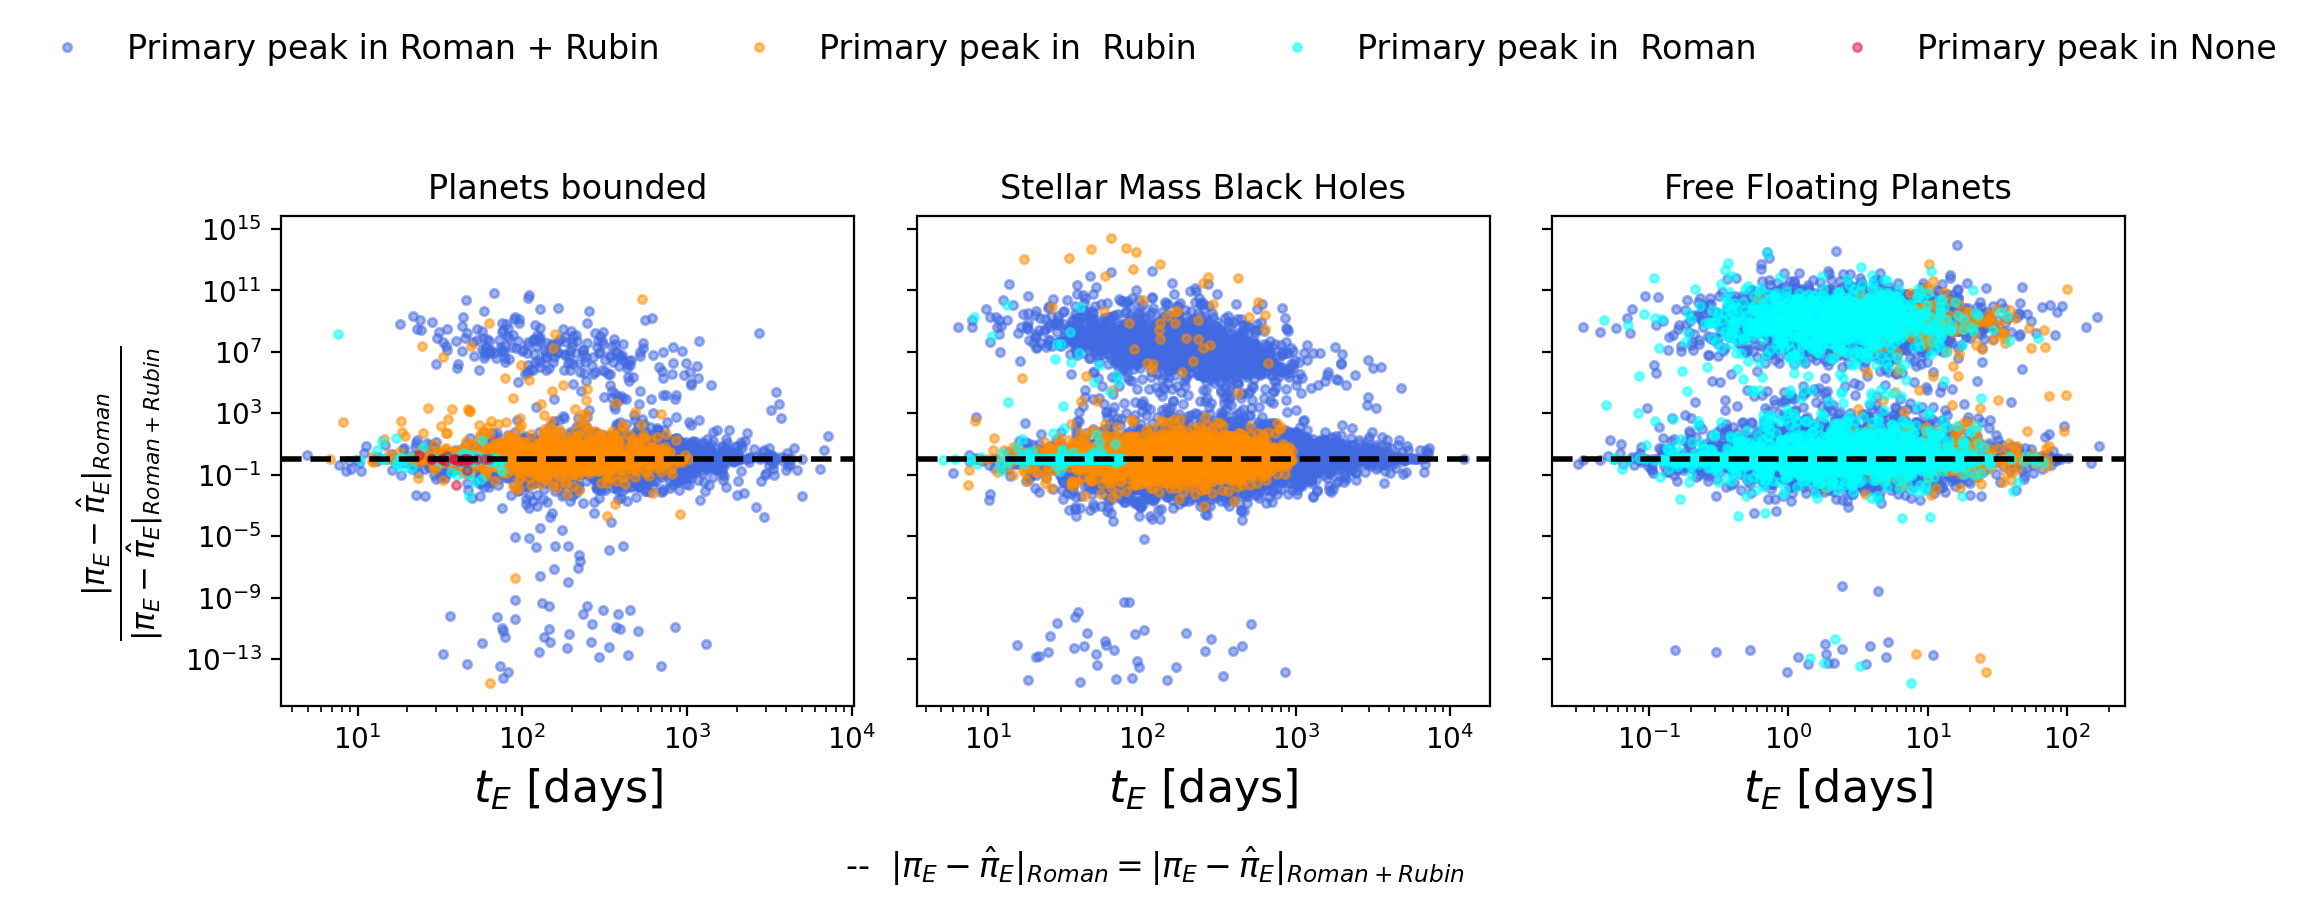

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
axs = axs.flatten()

example_handles = []
example_labels = []

for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_roman']['metric1']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
    df2 = data[Class]['true']
    
    for cat in ['A', 'B', 'C', 'D']:
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0

        if not np.any(mask):
            continue

        p = axs[i].plot(
            df2['tE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            color=category_colors[cat],
            label=f'Primary peak in {category_names[cat]}',alpha=0.5
        )
        if i == 0:
            example_handles.append(p[0])
            example_labels.append(f'Primary peak in {category_names[cat]}')

    axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('$t_E$ [days]', fontsize=16)
    # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# Leyenda de los colores arriba
fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r'--  $|\pi_E-\hat{\pi}_E|_{Roman} = |\pi_E-\hat{\pi}_E|_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)
fig.text(-0.04, 0.5, r'$\frac{|\pi_E-\hat{\pi}_E|_{Roman}}{|\pi_E-\hat{\pi}_E|_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)

os.makedirs('/home/anibal-pc/results_roman_rubin/metrics_plots', exist_ok=True)
plt.tight_layout()
plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/Bias_ratio_piE_vs_tE.png')
plt.show()


In [18]:
# Class = 'FSPL'
# p='piE'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# # sources = df1[df1[p]>0.9].head(3)['Source'].values
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# sources
# download_data(sources, Class)


In [42]:
# df1[df1['Source']==14]

In [24]:
Class = 'FSPL'
p='piE'
mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources = df1[df1[p]>0.9].head(3)['Source'].values
sources = df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.5)]['Source'].head(3).values
sets = df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.5)]['Set'].head(3).values
print(sources, sets)
# download_data(sources, 'FSPL')

[    20 131448    736] [1 1 1]


check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the t

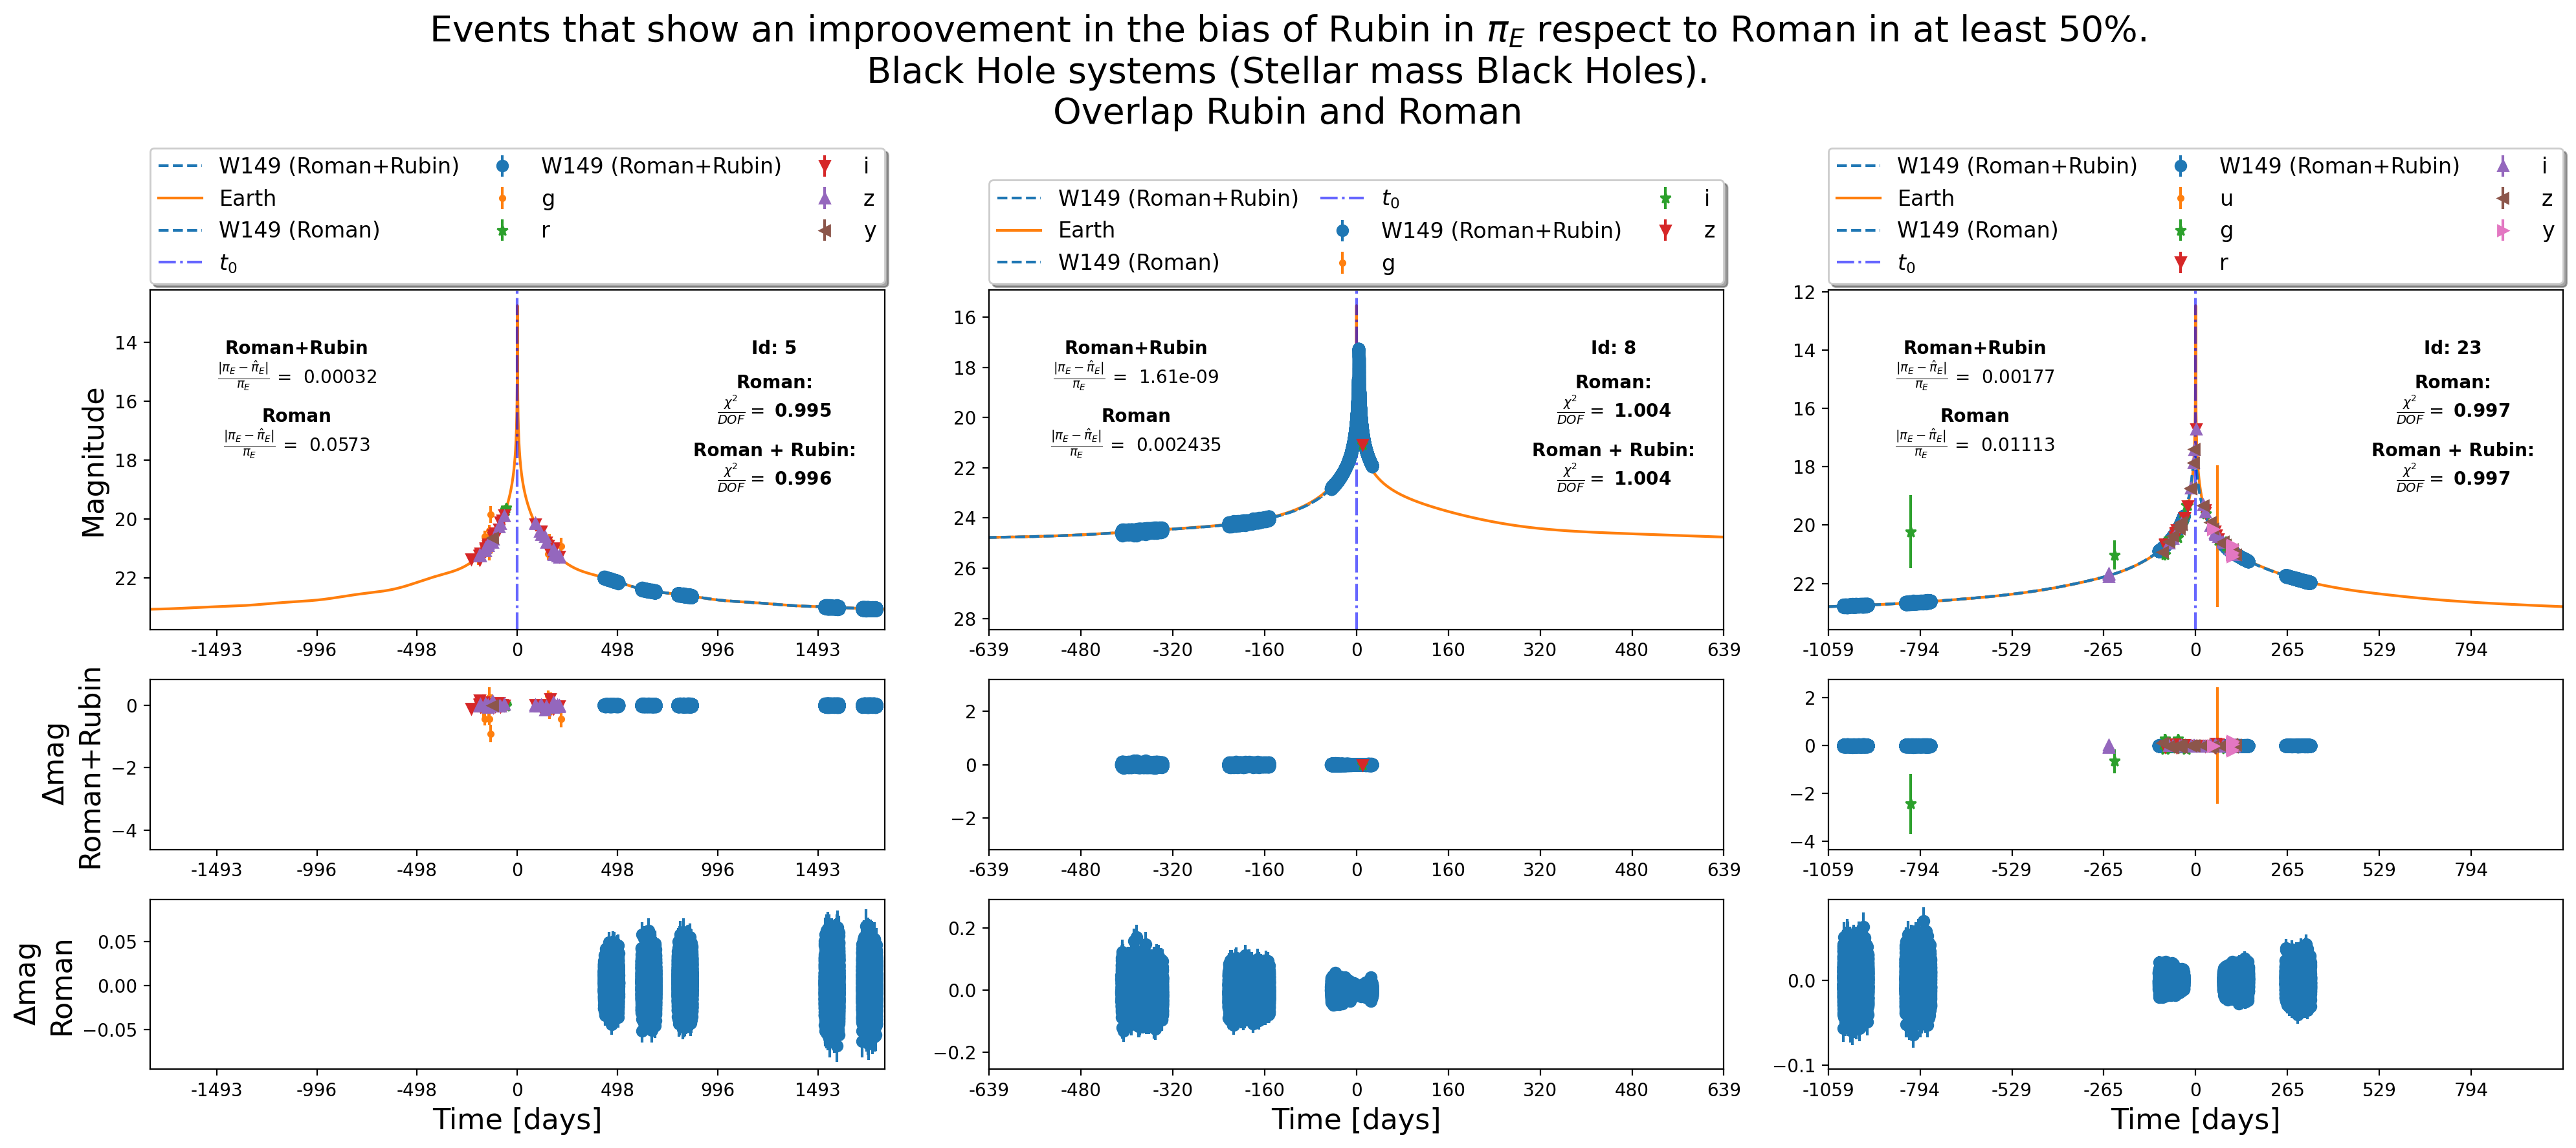

In [26]:
sources = np.array([ 5,  8, 23])
sets = np.array([1,1,1])
"""
Category A
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
Class = 'PSPL'
df_to_plot = create_df_to_plot(sources, Class)
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)
df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
df2 = df_metrics.loc[Class, 'fit_roman']['metric1']

xcoor = 0.2
bias1_rr = df1[(df1['Source']==sources[0])&(df1['Set']==sets[0])]['piE'].values[0]
bias2_rr =df1[(df1['Source']==sources[1])&(df1['Set']==sets[1])]['piE'].values[0]
bias3_rr =df1[(df1['Source']==sources[2])&(df1['Set']==sets[2])]['piE'].values[0]

bias1_roman = df2[(df2['Source']==sources[0])&(df2['Set']==sets[0])]['piE'].values[0]
bias2_roman = df2[(df2['Source']==sources[1])&(df2['Set']==sets[1])]['piE'].values[0]
bias3_roman = df2[(df2['Source']==sources[2])&(df2['Set']==sets[2])]['piE'].values[0]

axes[0,0].annotate("Roman+Rubin", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman+Rubin", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman+Rubin", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_rr,5)}", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_rr,11)}", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_rr,5)}", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,0].annotate("Roman", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_roman,abs(round(np.log10(bias1_roman)))+3)}", 
             xy=(xcoor, 0.5), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_roman,abs(round(np.log10(bias2_roman)))+3)}", 
             xy=(xcoor, 0.5), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_roman,abs(round(np.log10(bias3_roman)))+3)}", 
             xy=(xcoor, 0.5), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

plt.suptitle('Events that show an improovement in the bias of Rubin in $\pi_E$ respect to Roman in at least 50%.\nBlack Hole systems (Stellar mass Black Holes).\nOverlap Rubin and Roman',fontsize=20)   
plt.tight_layout()  

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the t

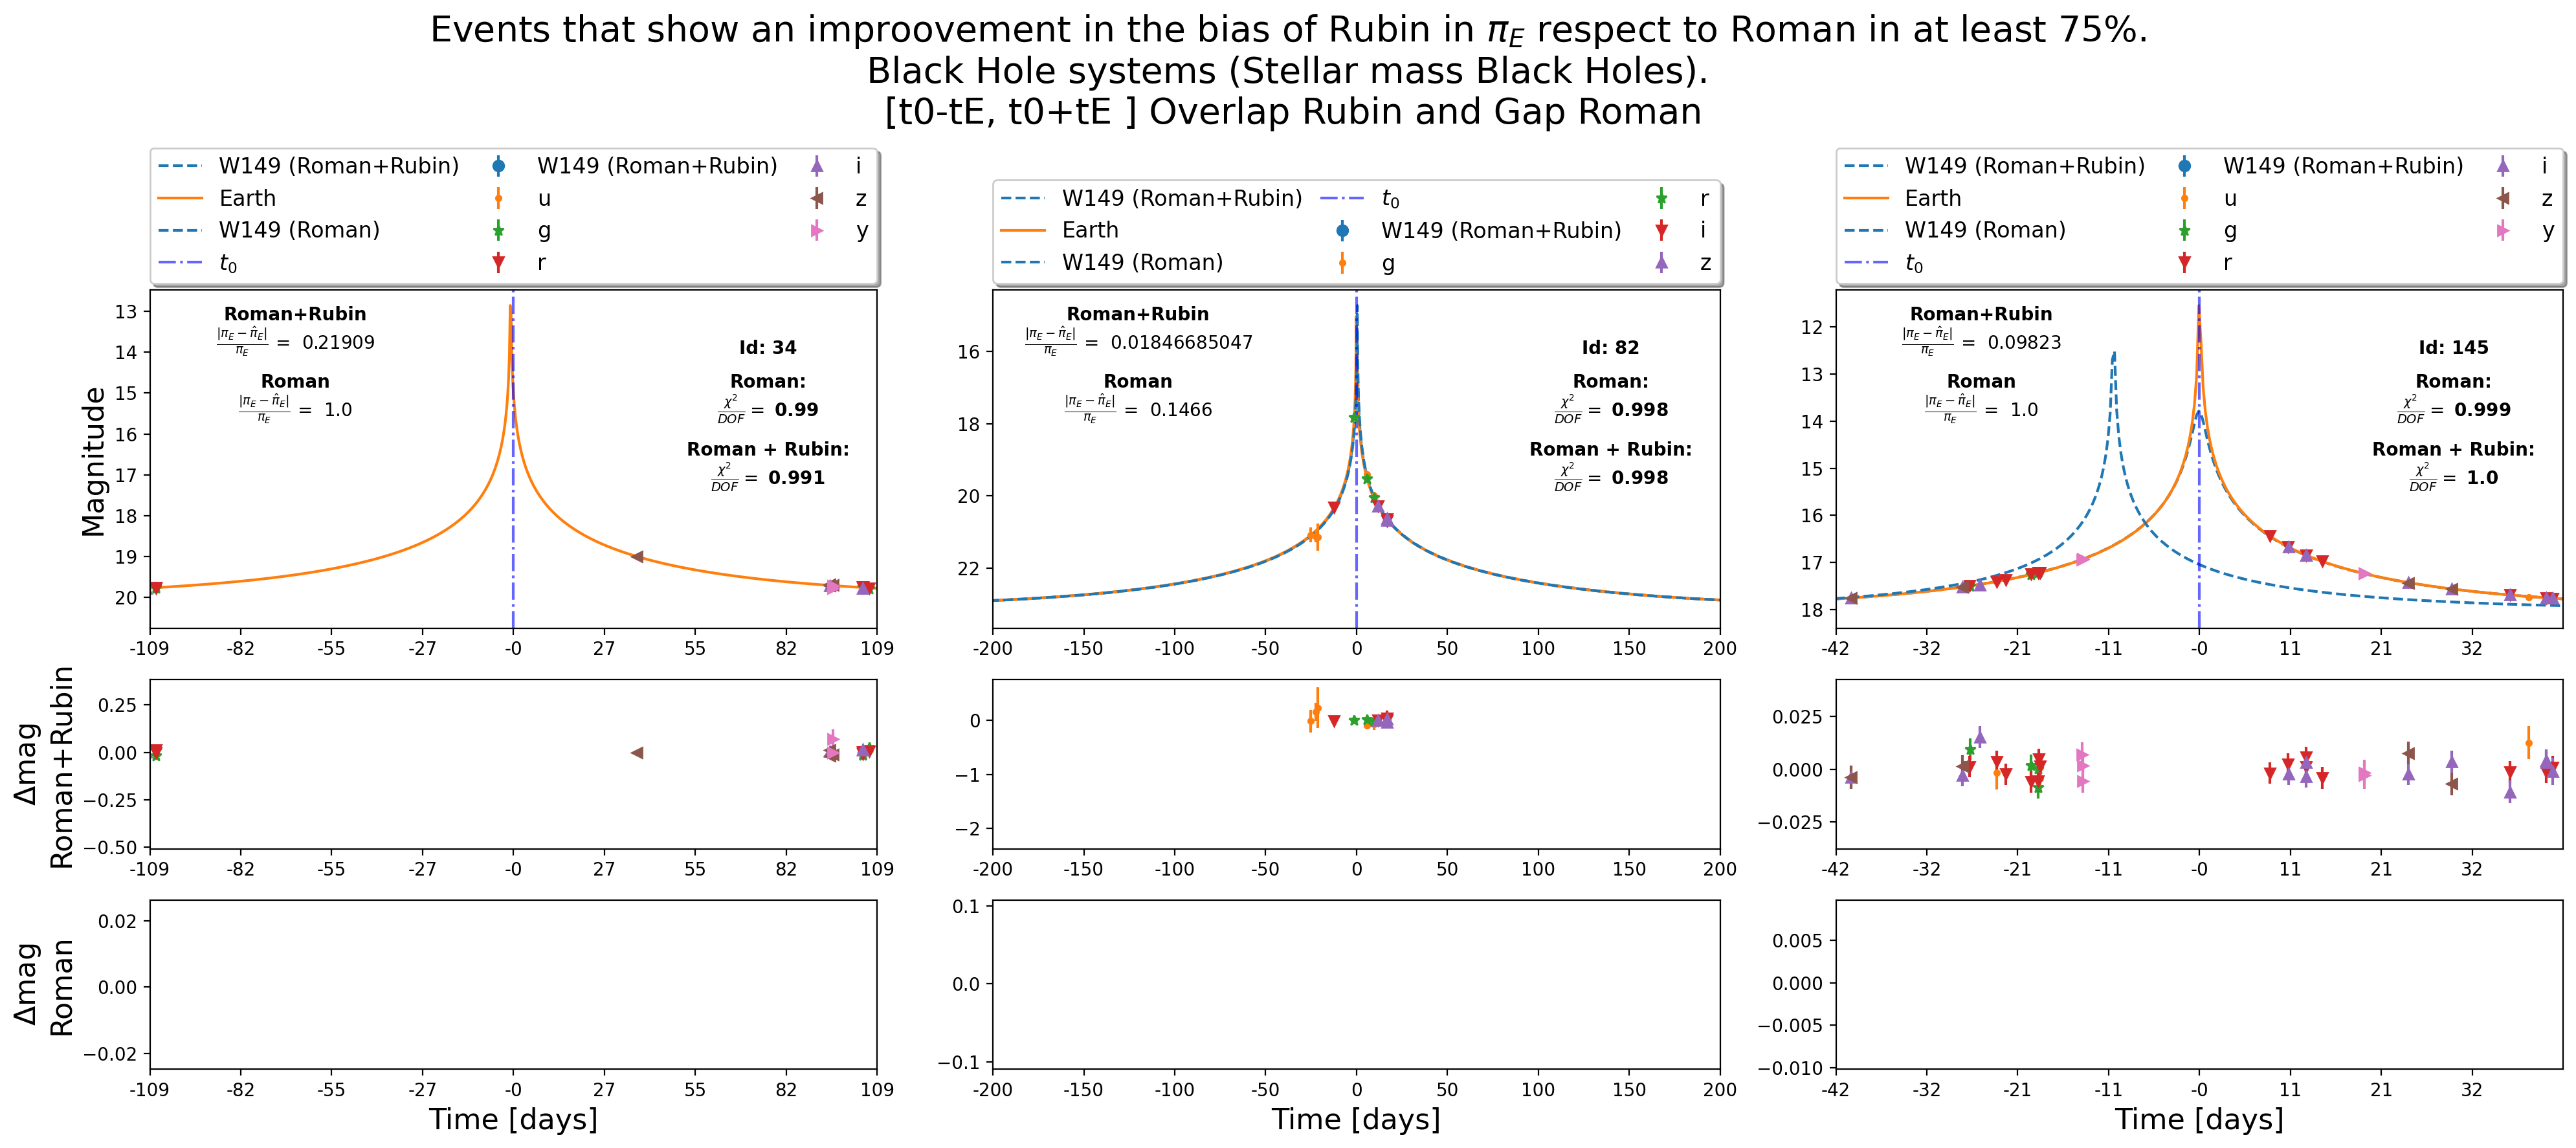

In [136]:

sources = np.array([ 34,  82, 145])
sets = np.array([1,1,1])
"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'PSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'PSPL')


xcoor = 0.2
bias1_rr = df1[(df1['Source']==sources[0])&(df1['Set']==sets[0])]['piE'].values[0]
bias2_rr =df1[(df1['Source']==sources[1])&(df1['Set']==sets[1])]['piE'].values[0]
bias3_rr =df1[(df1['Source']==sources[2])&(df1['Set']==sets[2])]['piE'].values[0]

bias1_roman = df2[(df2['Source']==sources[0])&(df2['Set']==sets[0])]['piE'].values[0]
bias2_roman = df2[(df2['Source']==sources[1])&(df2['Set']==sets[1])]['piE'].values[0]
bias3_roman = df2[(df2['Source']==sources[2])&(df2['Set']==sets[2])]['piE'].values[0]

axes[0,0].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_rr,11)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,0].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_roman,abs(round(np.log10(bias1_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_roman,abs(round(np.log10(bias2_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_roman,abs(round(np.log10(bias3_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
 
plt.suptitle('Events that show an improovement in the bias of Rubin in $\pi_E$ respect to Roman in at least 75%.\nBlack Hole systems (Stellar mass Black Holes).\n [t0-tE, t0+tE ] Overlap Rubin and Gap Roman',fontsize=20)   
# t0_0 = data[Class]['true'][data[Class]['true']['Source']==sources[0]]['t0p'].iloc[0]
# tE_0 = data[Class]['true'][data[Class]['true']['Source']==sources[0]]['tE'].iloc[0]
# axes[0,0].set_xlim(t0_0-3*tE_0,t0_0+3*tE_0)
plt.tight_layout()  

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the t

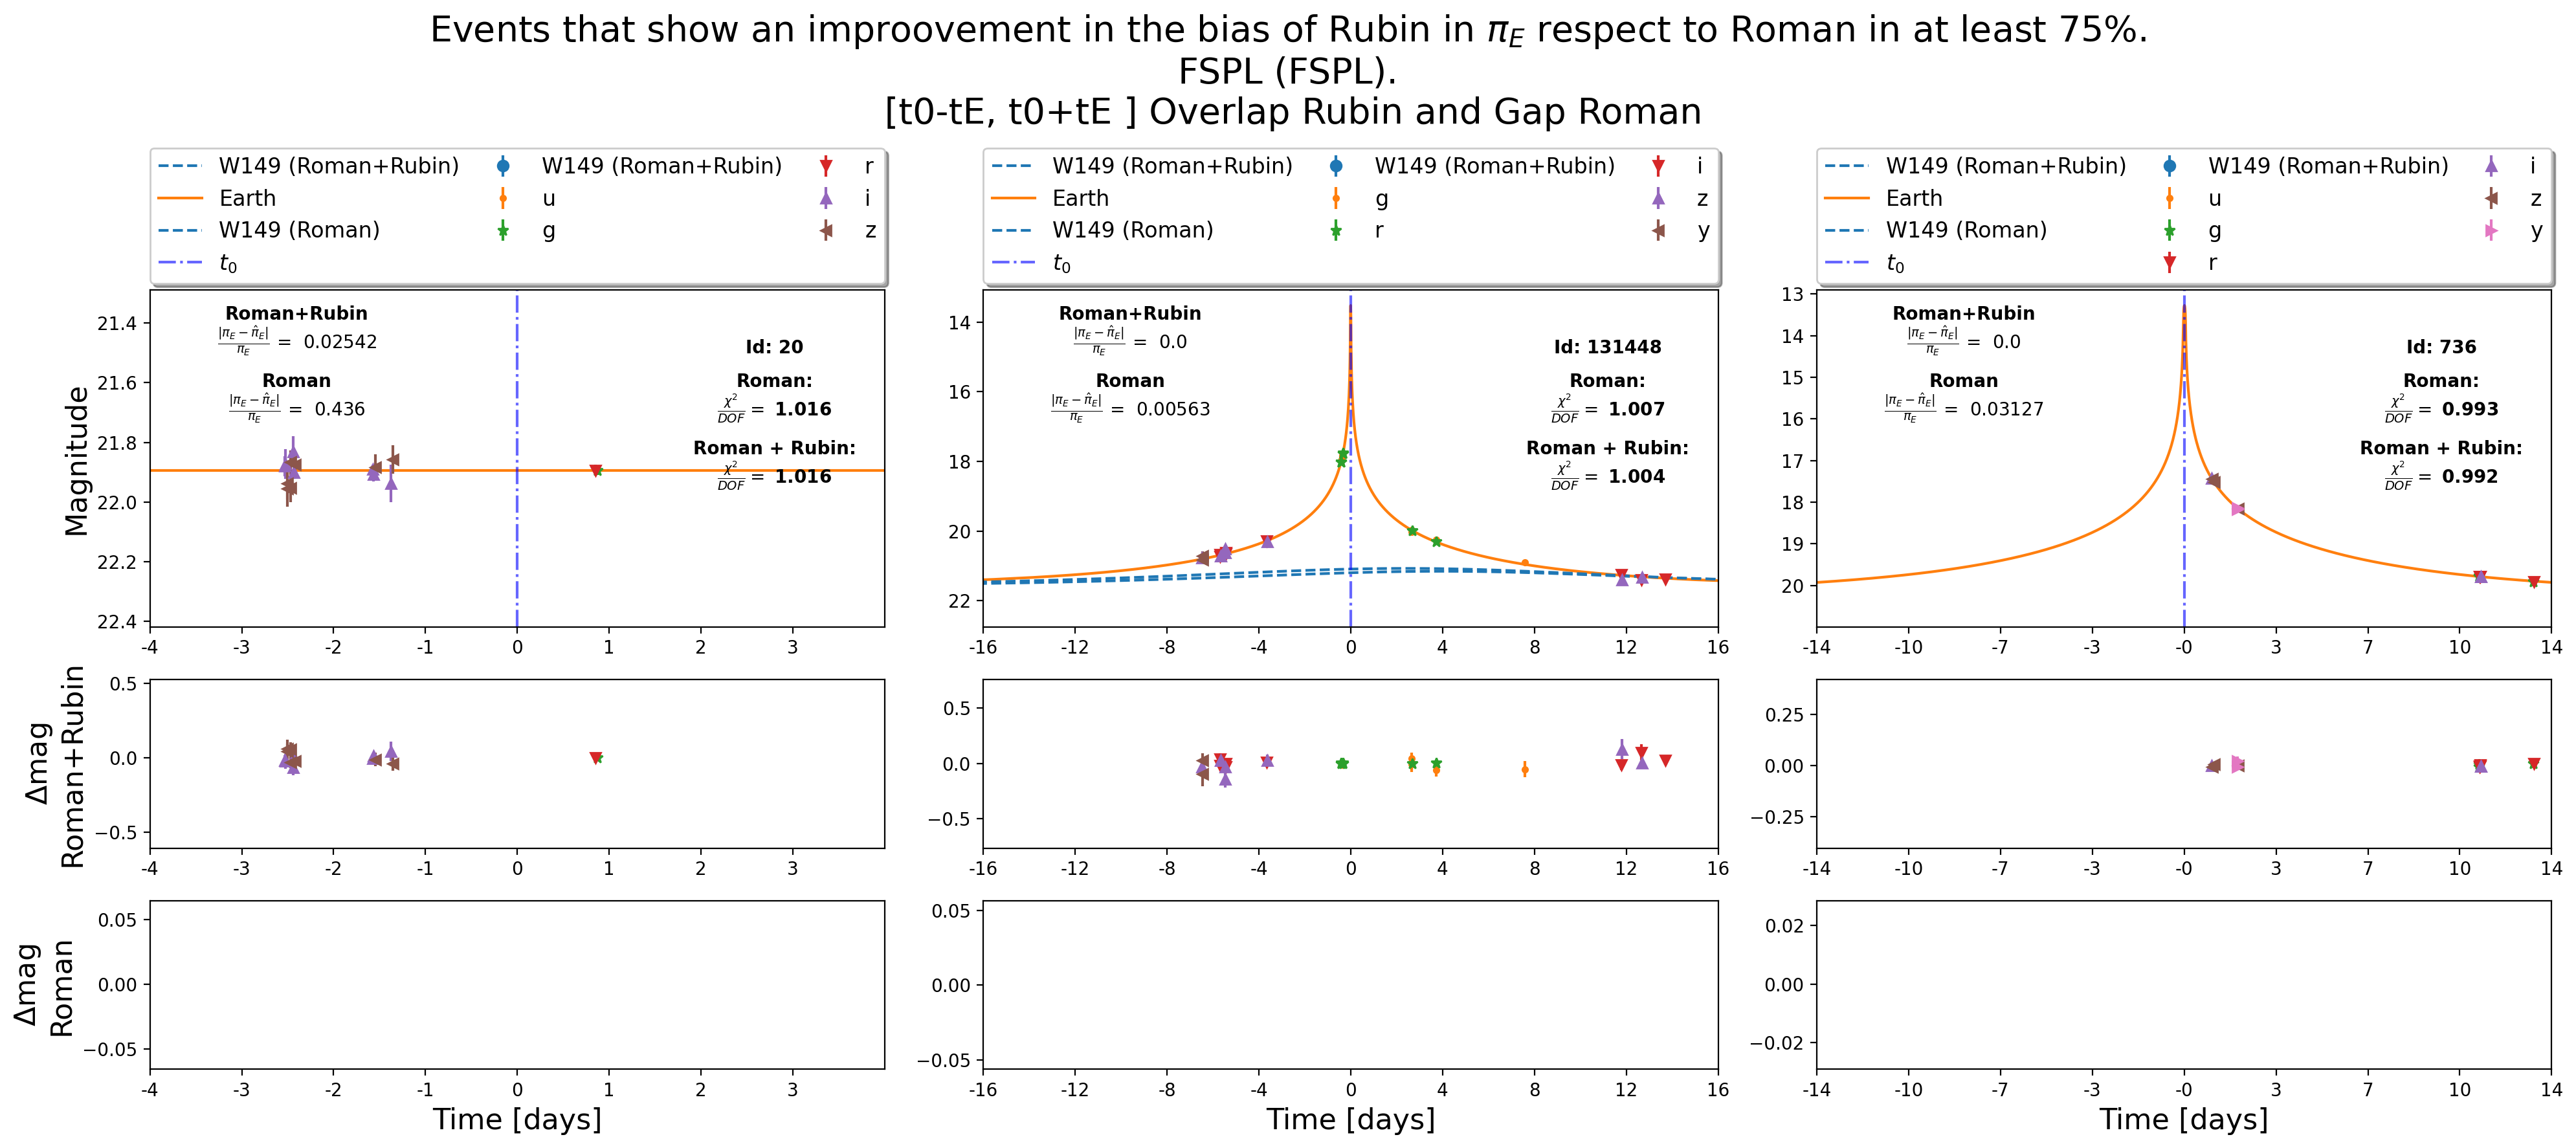

In [9]:
Class = 'FSPL'
sources = np.array([20, 131448,    736])
sets= np.array([1,1,1])

"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'FSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')


xcoor = 0.2
bias1_rr = df1[(df1['Source']==sources[0])&(df1['Set']==sets[0])]['piE'].values[0]
bias2_rr =df1[(df1['Source']==sources[1])&(df1['Set']==sets[1])]['piE'].values[0]
bias3_rr =df1[(df1['Source']==sources[2])&(df1['Set']==sets[2])]['piE'].values[0]

bias1_roman = df2[(df2['Source']==sources[0])&(df2['Set']==sets[0])]['piE'].values[0]
bias2_roman = df2[(df2['Source']==sources[1])&(df2['Set']==sets[1])]['piE'].values[0]
bias3_roman = df2[(df2['Source']==sources[2])&(df2['Set']==sets[2])]['piE'].values[0]

axes[0,0].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_rr,11)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,0].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_roman,abs(round(np.log10(bias1_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_roman,abs(round(np.log10(bias2_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_roman,abs(round(np.log10(bias3_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
 
# p='piE'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# df_to_plot = create_df_to_plot(sources, Class)   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)   
plt.suptitle('Events that show an improovement in the bias of Rubin in $\pi_E$ respect to Roman in at least 75%.\n'+f'{Class} ({Class}).'+'\n [t0-tE, t0+tE ] Overlap Rubin and Gap Roman',fontsize=20)   

plt.tight_layout()  

In [ ]:
# Class = 'FSPL'


# p='piE'
# category = 'A'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == category
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# # download_data(sources, Class)
# df_to_plot = create_df_to_plot(sources, Class)   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)   
# plt.suptitle('Events that show an improovement in the bias of Rubin in'+f' ${p}$ '+'respect to Roman in at least 75%.\n'+f'{dictionary_class[Class]} ({Class}).'+'\n [t0-tE, t0+tE ] Overlap Rubin and Gap Roman',fontsize=20)   

# plt.tight_layout()  

In [ ]:
# Class = 'USBL'
# p='piE'
# category = 'A'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == category
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# download_data(sources, Class)
# df_to_plot = create_df_to_plot(sources, Class)   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)   
# plt.suptitle('Events that show an improovement in the bias of Rubin in'+f' ${p}$ '+'respect to Roman in at least 75%.\n'+f'{dictionary_class[Class]} ({Class}).'+'\n [t0-tE, t0+tE ] Overlap Rubin and Gap Roman',fontsize=20)   

# plt.tight_layout()  

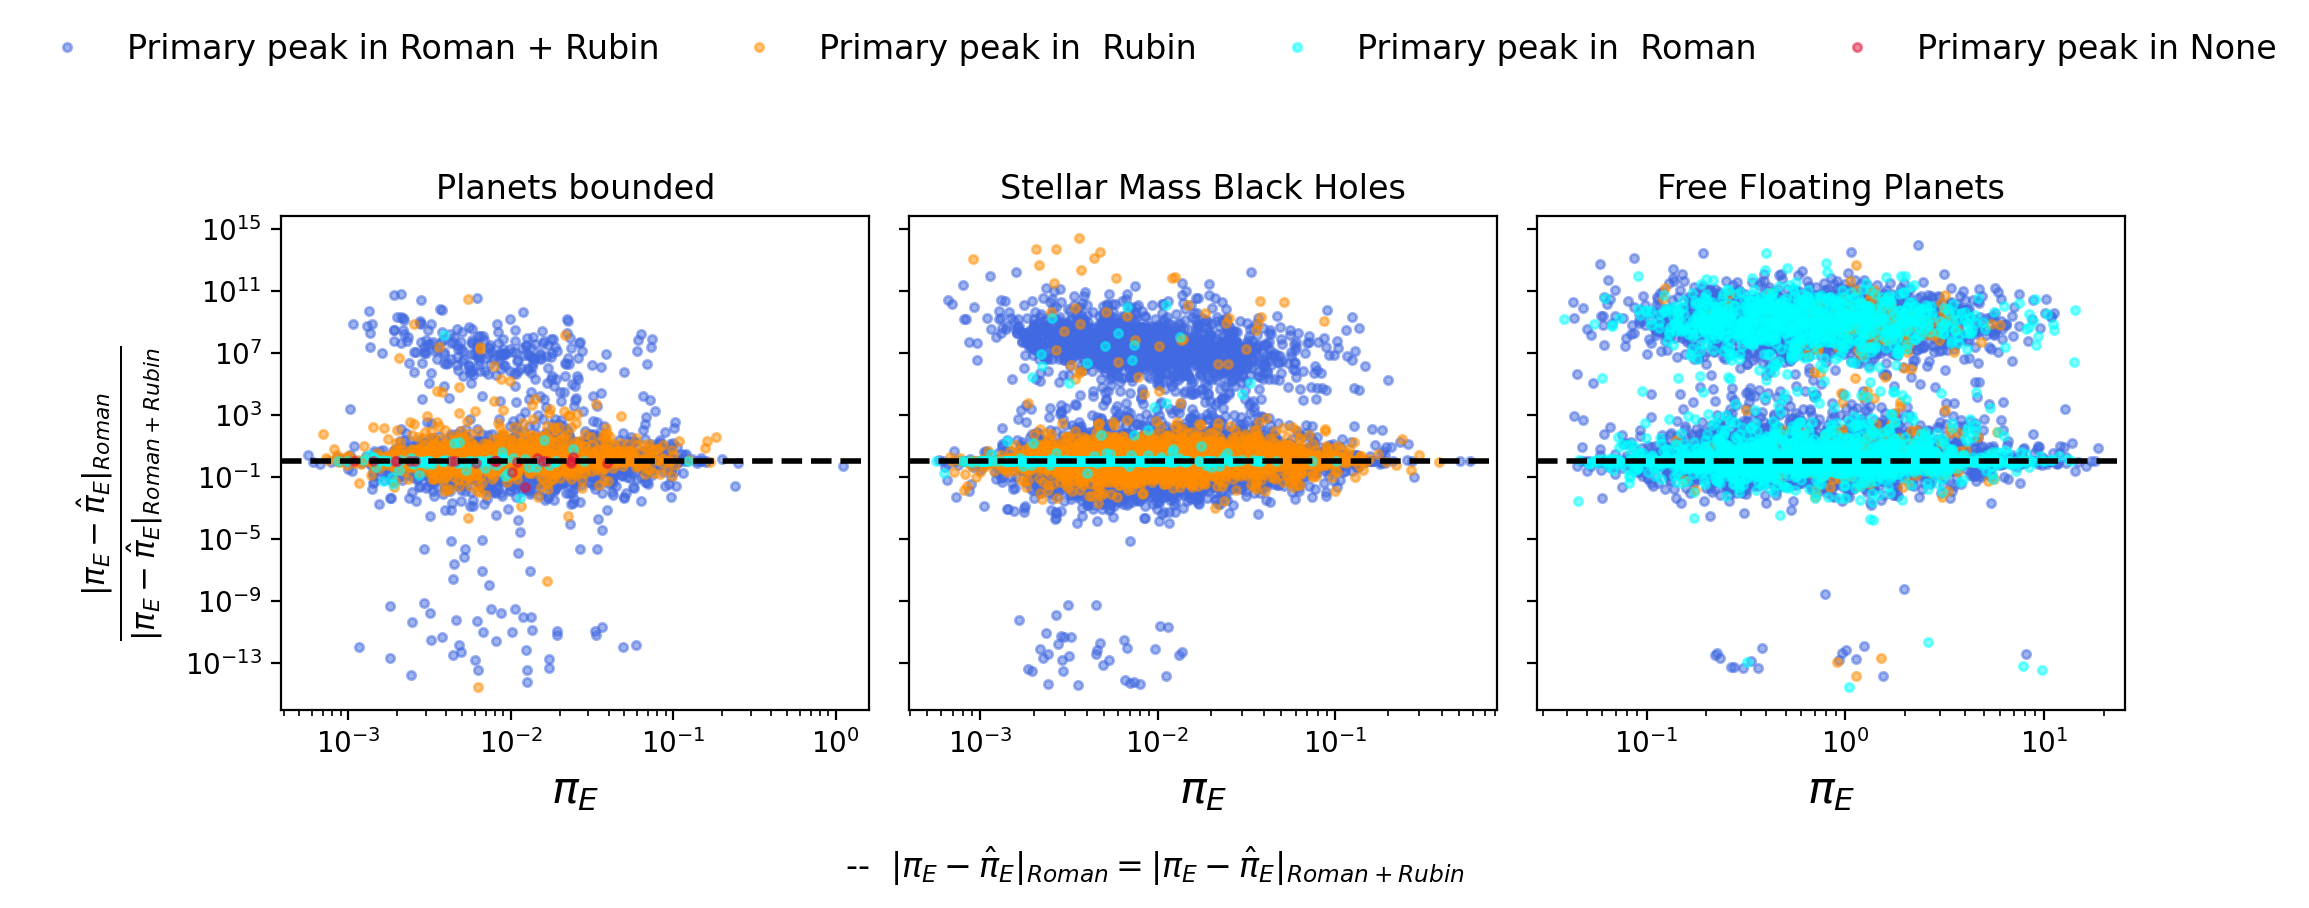

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
axs = axs.flatten()

example_handles = []
example_labels = []

for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_roman']['metric1']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
    df2 = data[Class]['true']
    
    for cat in ['A', 'B', 'C', 'D']:
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0

        if not np.any(mask):
            continue

        p = axs[i].plot(
            df2['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            color=category_colors[cat],
            label=f'Primary peak in {category_names[cat]}',alpha=0.5
        )
        if i == 0:
            example_handles.append(p[0])
            example_labels.append(f'Primary peak in {category_names[cat]}')

    axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('$\pi_E$', fontsize=16)
    # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# Leyenda de los colores arriba
fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r'--  $|\pi_E-\hat{\pi}_E|_{Roman} = |\pi_E-\hat{\pi}_E|_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)
fig.text(-0.04, 0.5, r'$\frac{|\pi_E-\hat{\pi}_E|_{Roman}}{|\pi_E-\hat{\pi}_E|_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)

os.makedirs('/home/anibal-pc/results_roman_rubin/metrics_plots', exist_ok=True)
plt.tight_layout()
plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/Bias_ratio_piE_vs_piE.png')
plt.show()

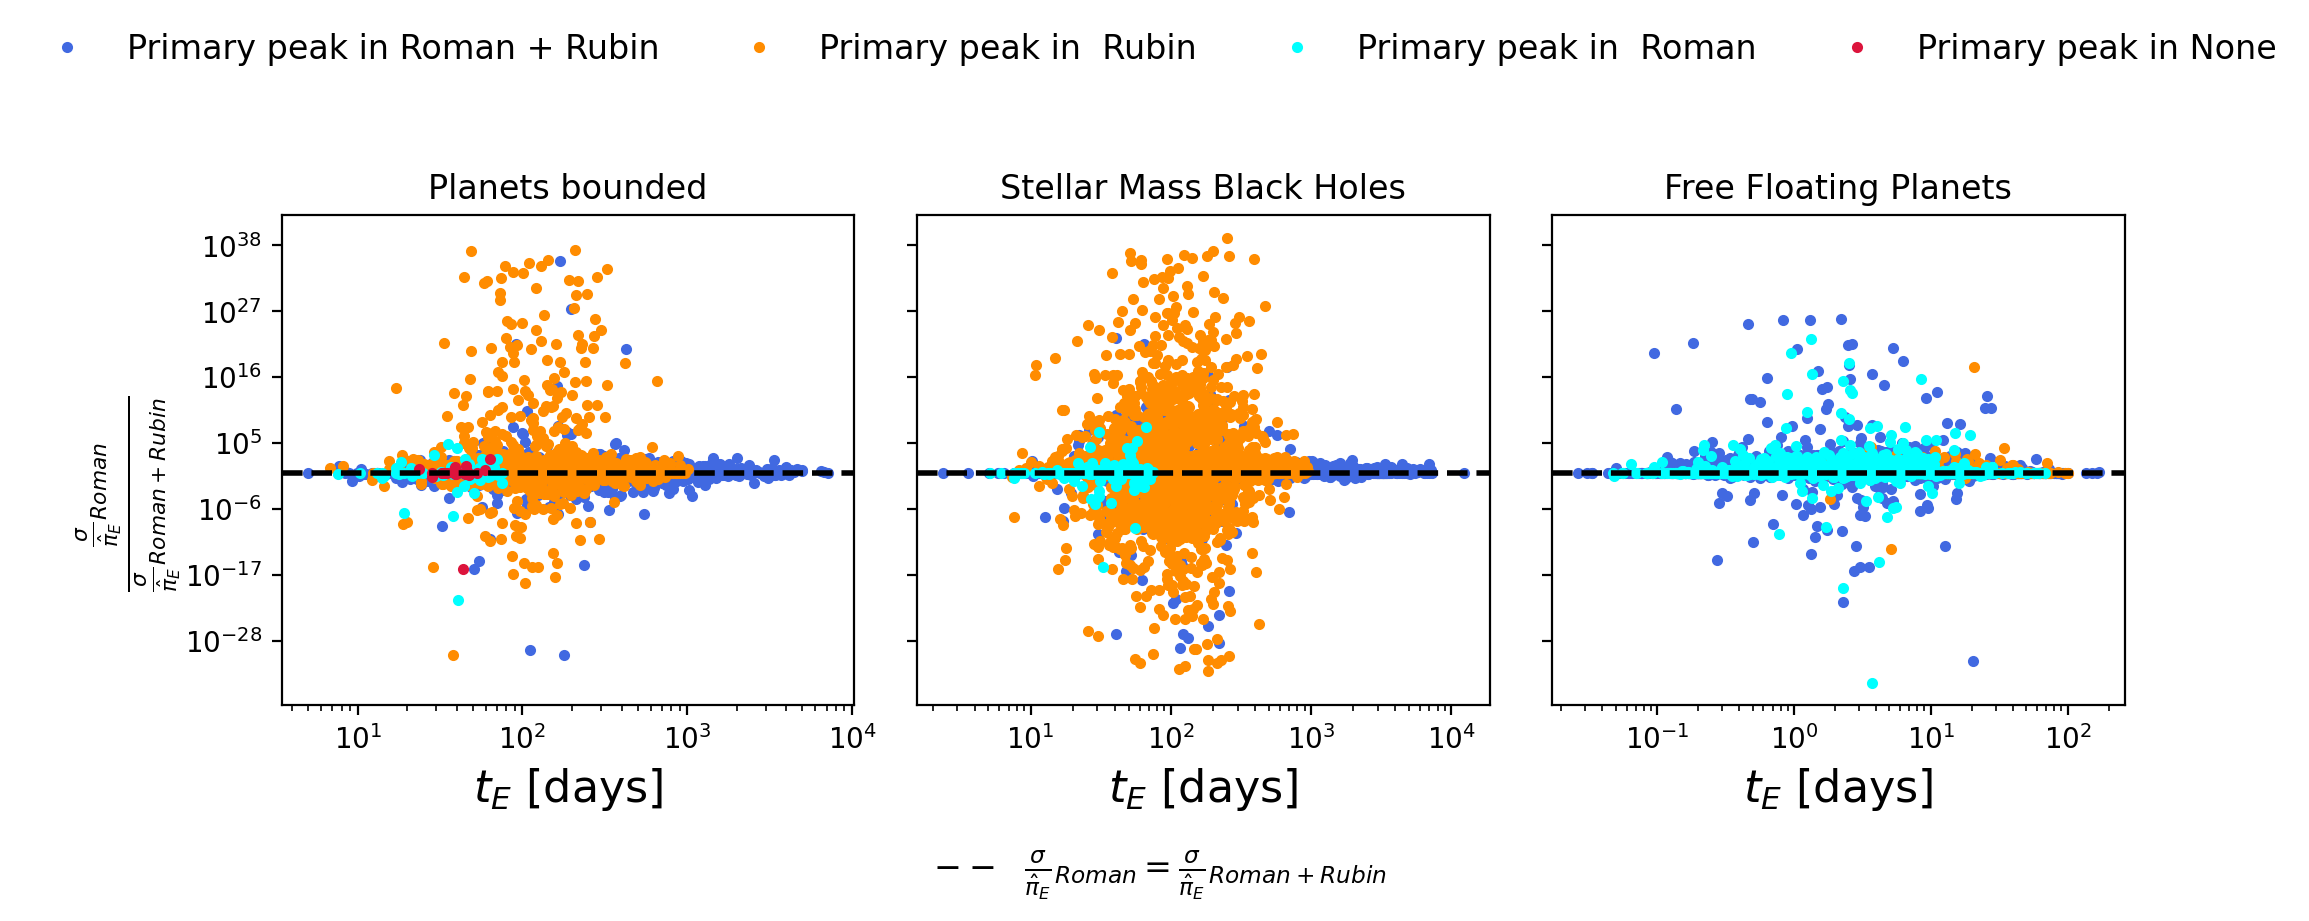

In [13]:

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
axs = axs.flatten()

example_handles = []
example_labels = []

for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_roman']['metric3']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric3']
    df2 = data[Class]['true']
    
    for cat in ['A', 'B', 'C', 'D']:
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0

        if not np.any(mask):
            continue
        # print(df0['tE'][mask] / df1['tE'][mask])
        p = axs[i].plot(
            df2['tE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            color=category_colors[cat],
            label=f'Primary peak in {category_names[cat]}',
        )
        if i == 0:
            example_handles.append(p[0])
            example_labels.append(f'Primary peak in {category_names[cat]}')

    axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('$t_E$ [days]', fontsize=16)
    # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# Leyenda de los colores arriba
fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r' $ -- \ \  \frac{\sigma}{\hat{\pi}_E}_{Roman} = \frac{\sigma}{\hat{\pi}_E}_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)
fig.text(-0.04, 0.5, r'$\frac{\frac{\sigma}{\hat{\pi}_E}_{Roman}}{\frac{\sigma}{\hat{\pi}_E}_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)
plt.tight_layout()
plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/rel_error_ratio_piE_vs_tE.png')


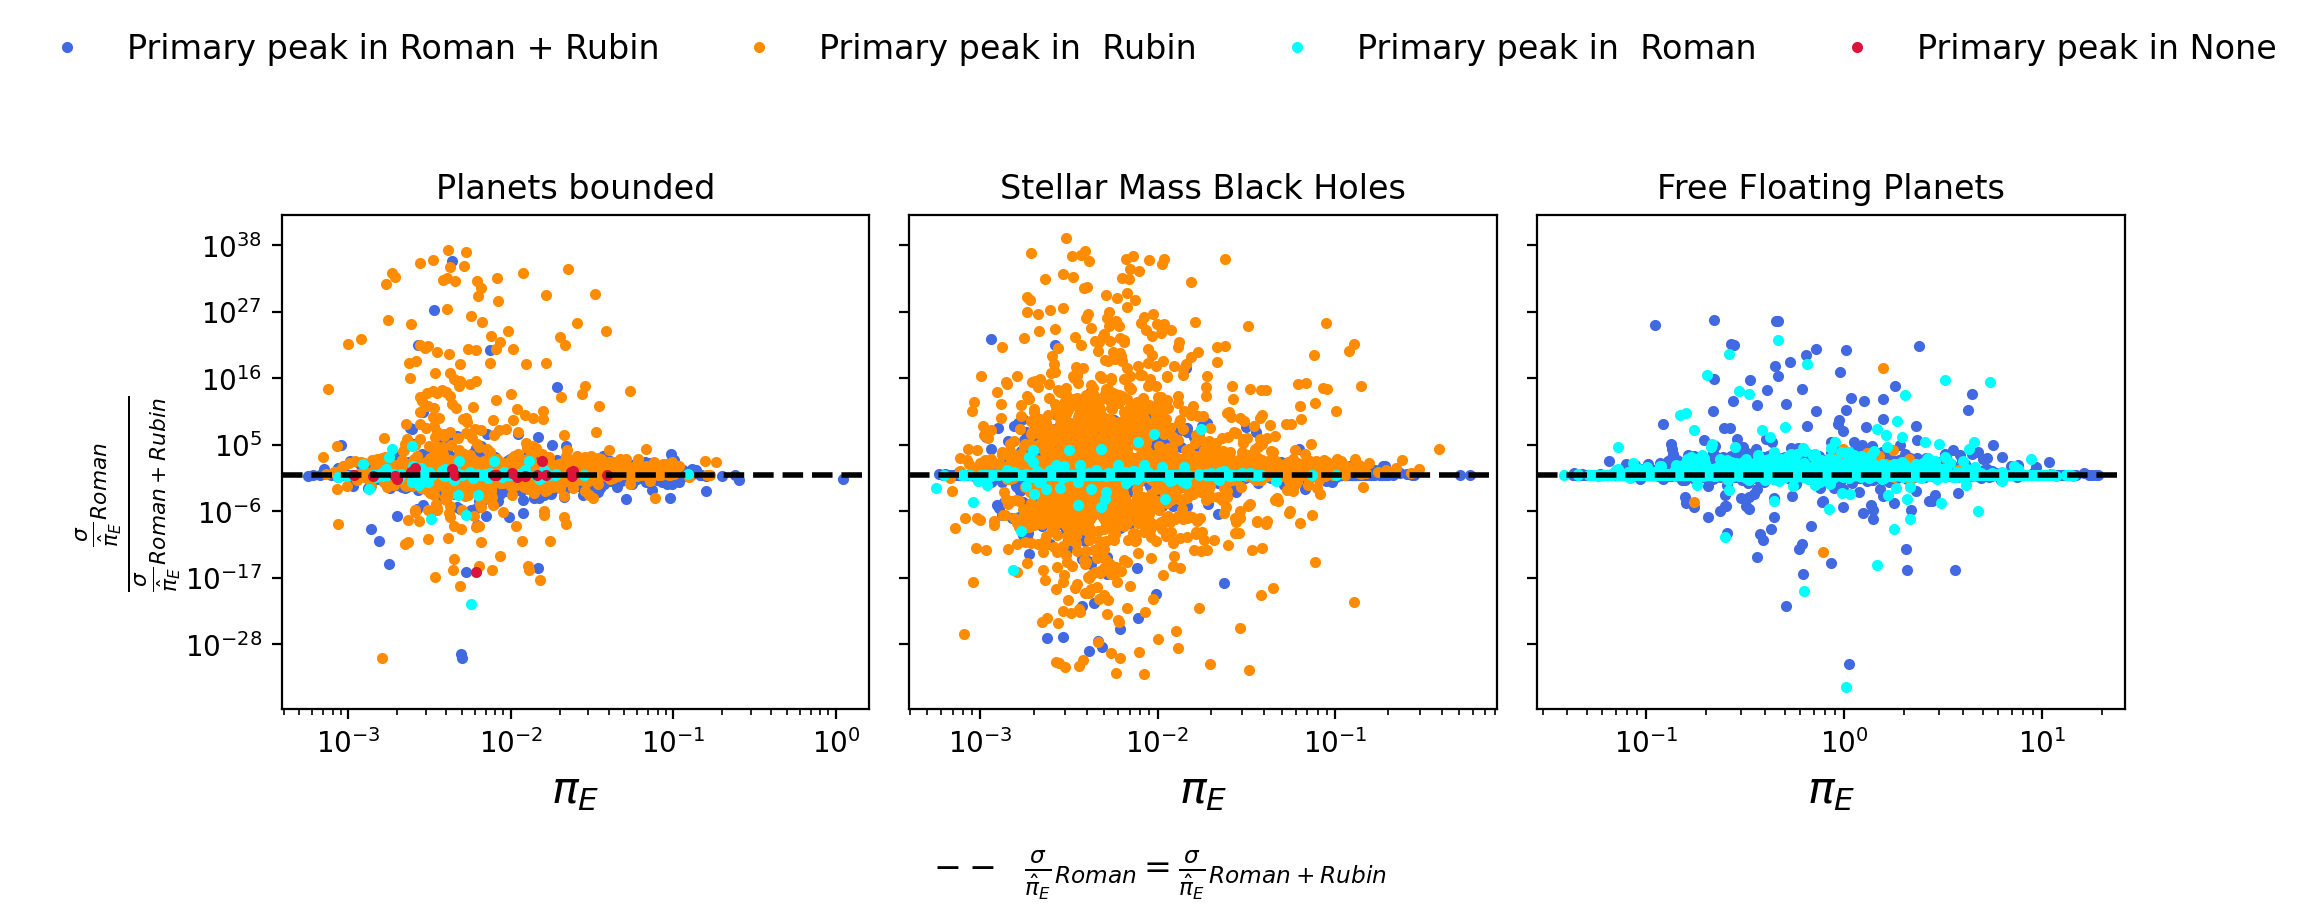

In [14]:

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
axs = axs.flatten()

example_handles = []
example_labels = []

for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_roman']['metric3']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric3']
    df2 = data[Class]['true']
    
    for cat in ['A', 'B', 'C', 'D']:
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0

        if not np.any(mask):
            continue
        # print(df0['tE'][mask] / df1['tE'][mask])
        p = axs[i].plot(
            df2['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            color=category_colors[cat],
            label=f'Primary peak in {category_names[cat]}',
        )
        if i == 0:
            example_handles.append(p[0])
            example_labels.append(f'Primary peak in {category_names[cat]}')

    axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('$\pi_E$', fontsize=16)
    # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# Leyenda de los colores arriba
fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r' $ -- \ \  \frac{\sigma}{\hat{\pi}_E}_{Roman} = \frac{\sigma}{\hat{\pi}_E}_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)
fig.text(-0.04, 0.5, r'$\frac{\frac{\sigma}{\hat{\pi}_E}_{Roman}}{\frac{\sigma}{\hat{\pi}_E}_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)
plt.tight_layout()
plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/rel_error_ratio_piE_vs_piE.png')


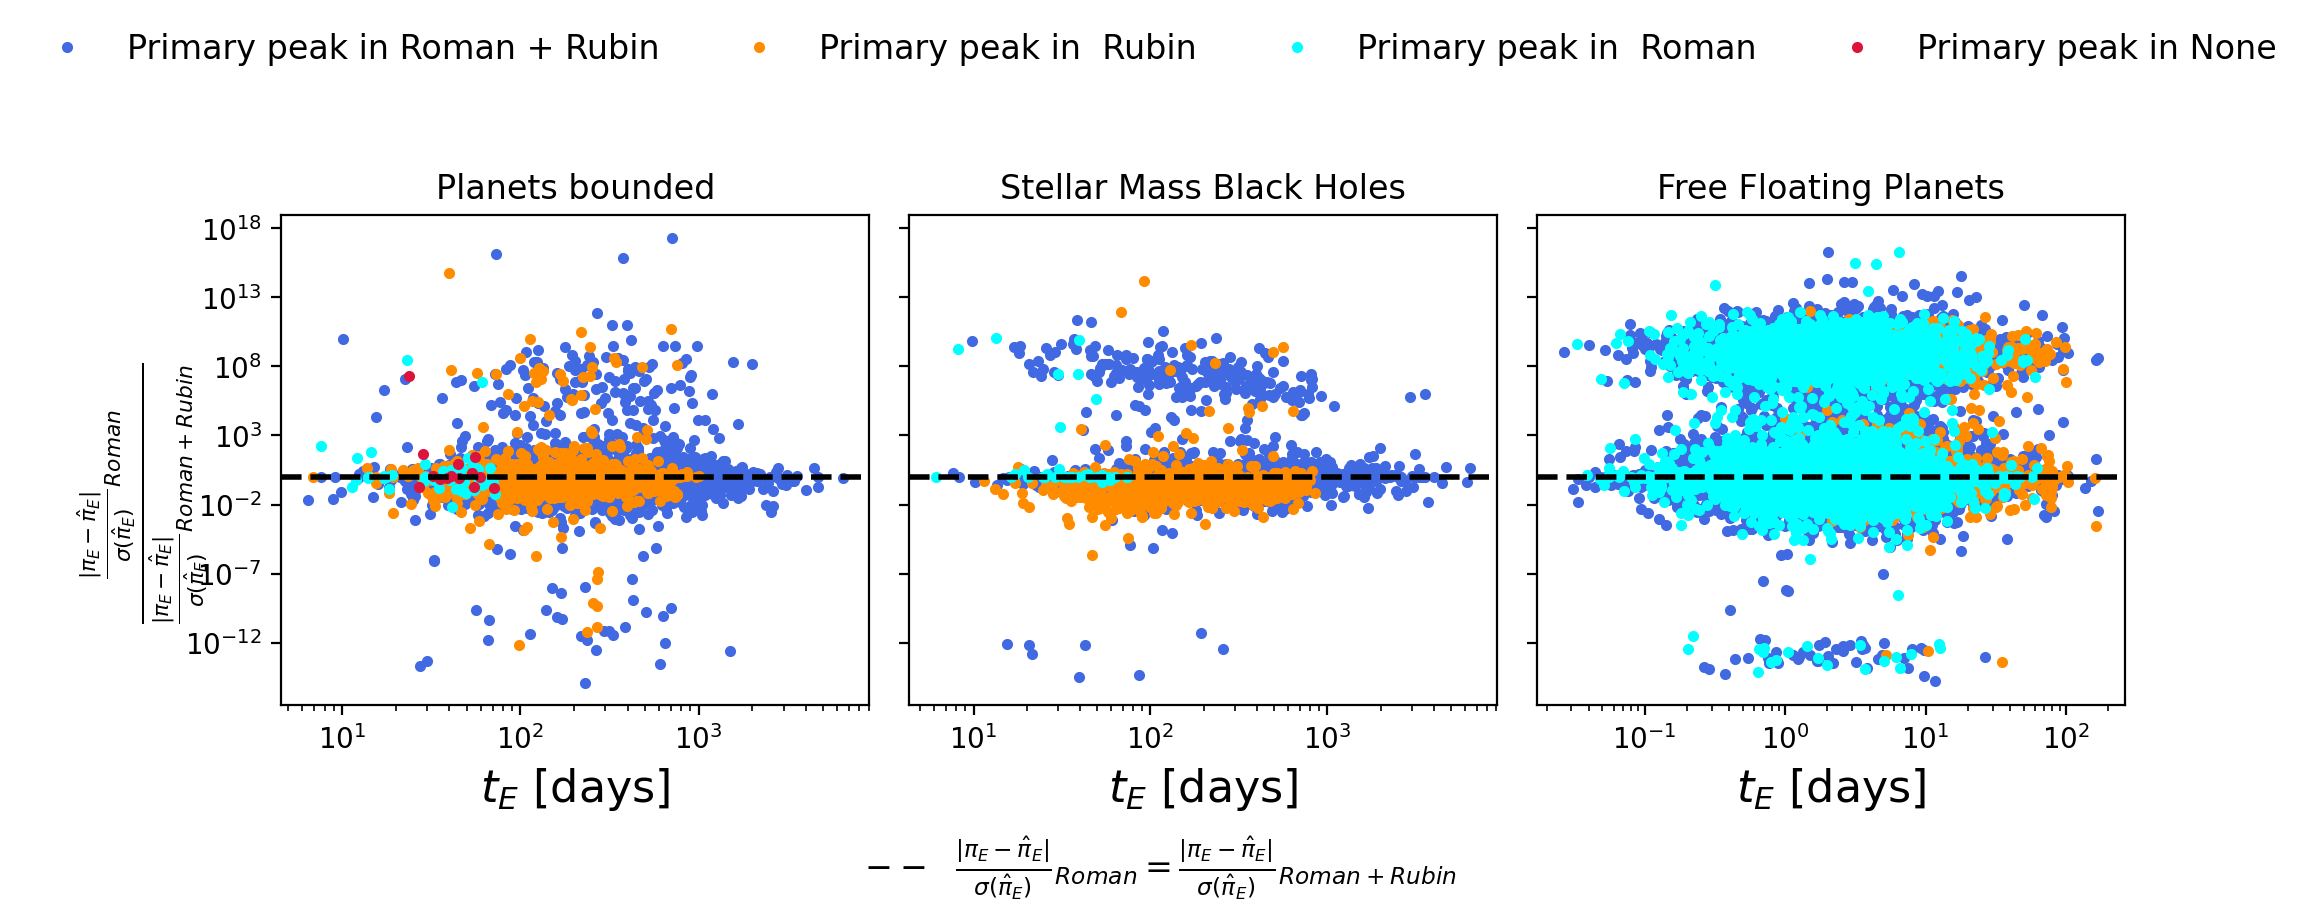

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
axs = axs.flatten()

example_handles = []
example_labels = []

for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
    df0 = df_metrics.loc[Class, 'fit_roman']['metric2']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric2']
    df2 = data[Class]['true']
    
    for cat in ['A', 'B', 'C', 'D']:
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
        mask &= df1['tE'] != 0

        if not np.any(mask):
            continue
        # print(df0['tE'][mask] / df1['tE'][mask])
        p = axs[i].plot(
            df2['tE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            color=category_colors[cat],
            label=f'Primary peak in {category_names[cat]}',
        )
        if i == 0:
            example_handles.append(p[0])
            example_labels.append(f'Primary peak in {category_names[cat]}')

    axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('$t_E$ [days]', fontsize=16)
    # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# Leyenda de los colores arriba
fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r' $ -- \ \  \frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman} = \frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)
fig.text(-0.04, 0.5, r'$\frac{\frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman}}{\frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)
plt.tight_layout()

In [34]:

# plt.plot(df2['tE'][mask],
#             df0['piE'][mask] / df1['piE'][mask],
#             marker='.',
#             linestyle='',
#             color=category_colors[cat],
#             label=f'Primary peak in {category_names[cat]}')

In [124]:
# fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200,sharey=True)
# axs = axs.flatten()

# example_handles = []
# example_labels = []

# for i, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
#     categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
#     df0 = df_metrics.loc[Class, 'fit_roman']['metric2']
#     df1 = df_metrics.loc[Class, 'fit_rr']['metric2']
#     df2 = data[Class]['true']
    
#     for cat in ['A', 'B', 'C', 'D']:
#         mask = categories == cat
#         mask &= df1['tE'].notna() & df0['tE'].notna() & df2['tE'].notna()
#         mask &= df1['tE'] != 0

#         if not np.any(mask):
#             continue
#         # print(df0['tE'][mask] / df1['tE'][mask])
#         p = axs[i].plot(
#             df2['piE'][mask],
#             df0['piE'][mask] / df1['piE'][mask],
#             marker='.',
#             linestyle='',
#             color=category_colors[cat],
#             label=f'Primary peak in {category_names[cat]}',
#         )
#         if i == 0:
#             example_handles.append(p[0])
#             example_labels.append(f'Primary peak in {category_names[cat]}')

#     axs[i].axhline(1, color='k', linestyle='--', linewidth=2)
#     axs[i].set_xscale('log')
#     axs[i].set_yscale('log')
#     axs[i].set_title(dictionary_class[Class])
#     axs[i].set_xlabel('$\pi_E$', fontsize=16)
#     # axs[i].set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

# # Leyenda de los colores arriba
# fig.legend(example_handles, example_labels, loc='upper center', ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.2))

# # Agregar texto manual para la línea horizontal
# fig.text(
#     0.5, -0.05,  # x, y en coordenadas de figura (0-1)
#     r' $ -- \ \  \frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman} = \frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman+Rubin}$',
#     ha='center', fontsize=12, color='k'
# )

# fig.text(-0.04, 0.5, r'$\frac{\frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman}}{\frac{|\pi_E-\hat{\pi}_E|}{\sigma(\hat{\pi}_E)}_{Roman+Rubin}}$', va='center', rotation='vertical', fontsize=16)
# plt.tight_layout()

## Somayeh plots

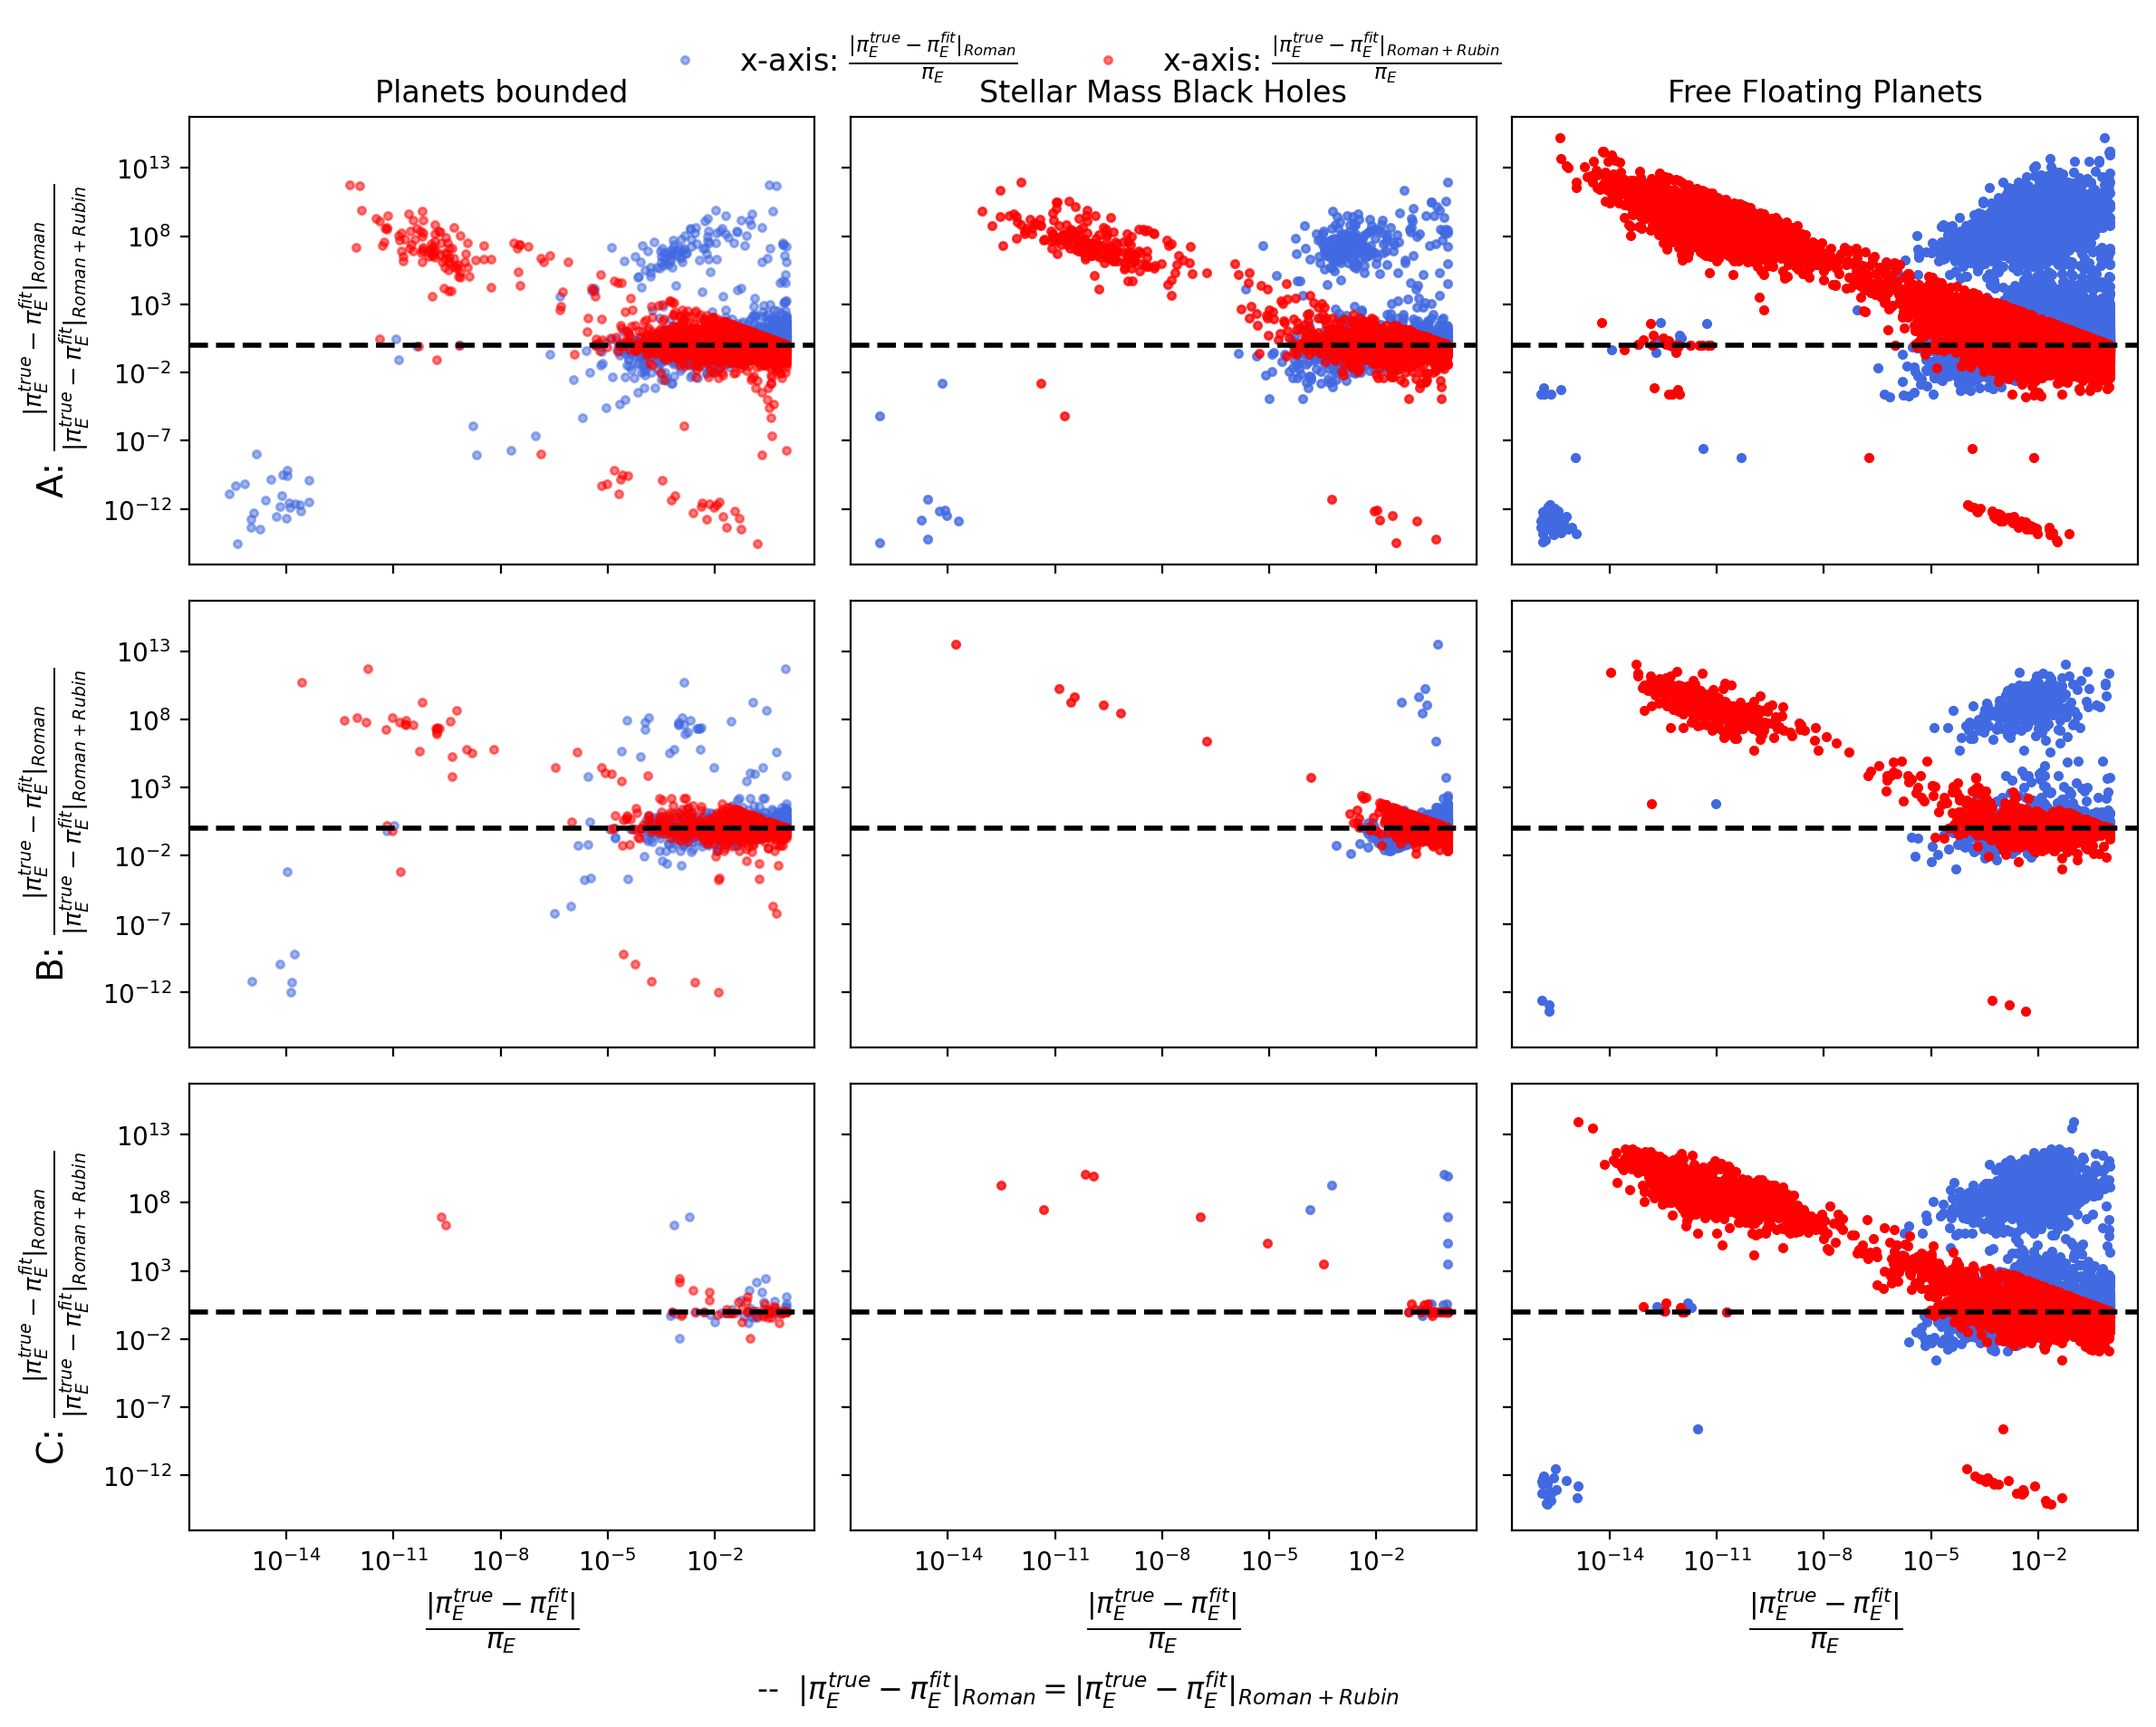

In [16]:
fig, axs = plt.subplots(3, 3, figsize=(12, 9), dpi=200, sharey=True, sharex=True)
example_handles = []
example_labels = []

for row_idx, cat in enumerate(['A', 'B', 'C']):
    for col_idx, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
        ax = axs[row_idx, col_idx]
        categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']
        df0 = df_metrics.loc[Class, 'fit_roman']['metric1']
        df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
        
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna()
        mask &= df1['tE'] != 0
        if not np.any(mask):
            continue

        # Plot using fit_roman as x-axis
        p0 = ax.plot(
            df0['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            alpha=0.5+col_idx*0.25,
            color='royalblue',
            label='fit_roman'
        )

        # Plot using fit_rr as x-axis
        p1 = ax.plot(
            df1['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            alpha=0.5+col_idx*0.25,
            color='red',
            label='fit_rr'
        )

        if row_idx == 0 and col_idx == 0:
            example_handles.extend([p0[0], p1[0]])
            # example_labels.extend([
            #     r'x-axis: $\pi_E^{fit, Roman}$',
            #     r'x-axis: $\pi_E^{fit, Roman+Rubin}$'
            # ])
            example_labels.extend([r'x-axis: $\frac{|\pi_E^{true}-\pi_E^{fit}|_{Roman}}{\pi_E}$', r'x-axis: $\frac{|\pi_E^{true}-\pi_E^{fit}|_{Roman+Rubin}}{\pi_E}$'])
        ax.axhline(1, color='k', linestyle='--', linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')

        if row_idx == 2:
            ax.set_xlabel(r'$\frac{|\pi_E^{true}-\pi_E^{fit}|}{\pi_E}$', fontsize=16)

        if col_idx == 0:
            ax.set_ylabel(
                rf"{cat}: $\frac{{|\pi_E^{{true}} - \pi_E^{{fit}}|_{{Roman}}}}{{|\pi_E^{{true}} - \pi_E^{{fit}}|_{{Roman+Rubin}}}}$",
                fontsize=14
            )
        if row_idx == 0:
            ax.set_title(dictionary_class[Class])

fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.text(0.5, 0.01, r'--  $|\pi_E^{true}-\pi_E^{fit}|_{Roman} = |\pi_E^{true}-\pi_E^{fit}|_{Roman+Rubin}$',
         ha='center', fontsize=12, color='k')

plt.tight_layout(rect=[0, 0.02, 1, 1.02])
plt.show()


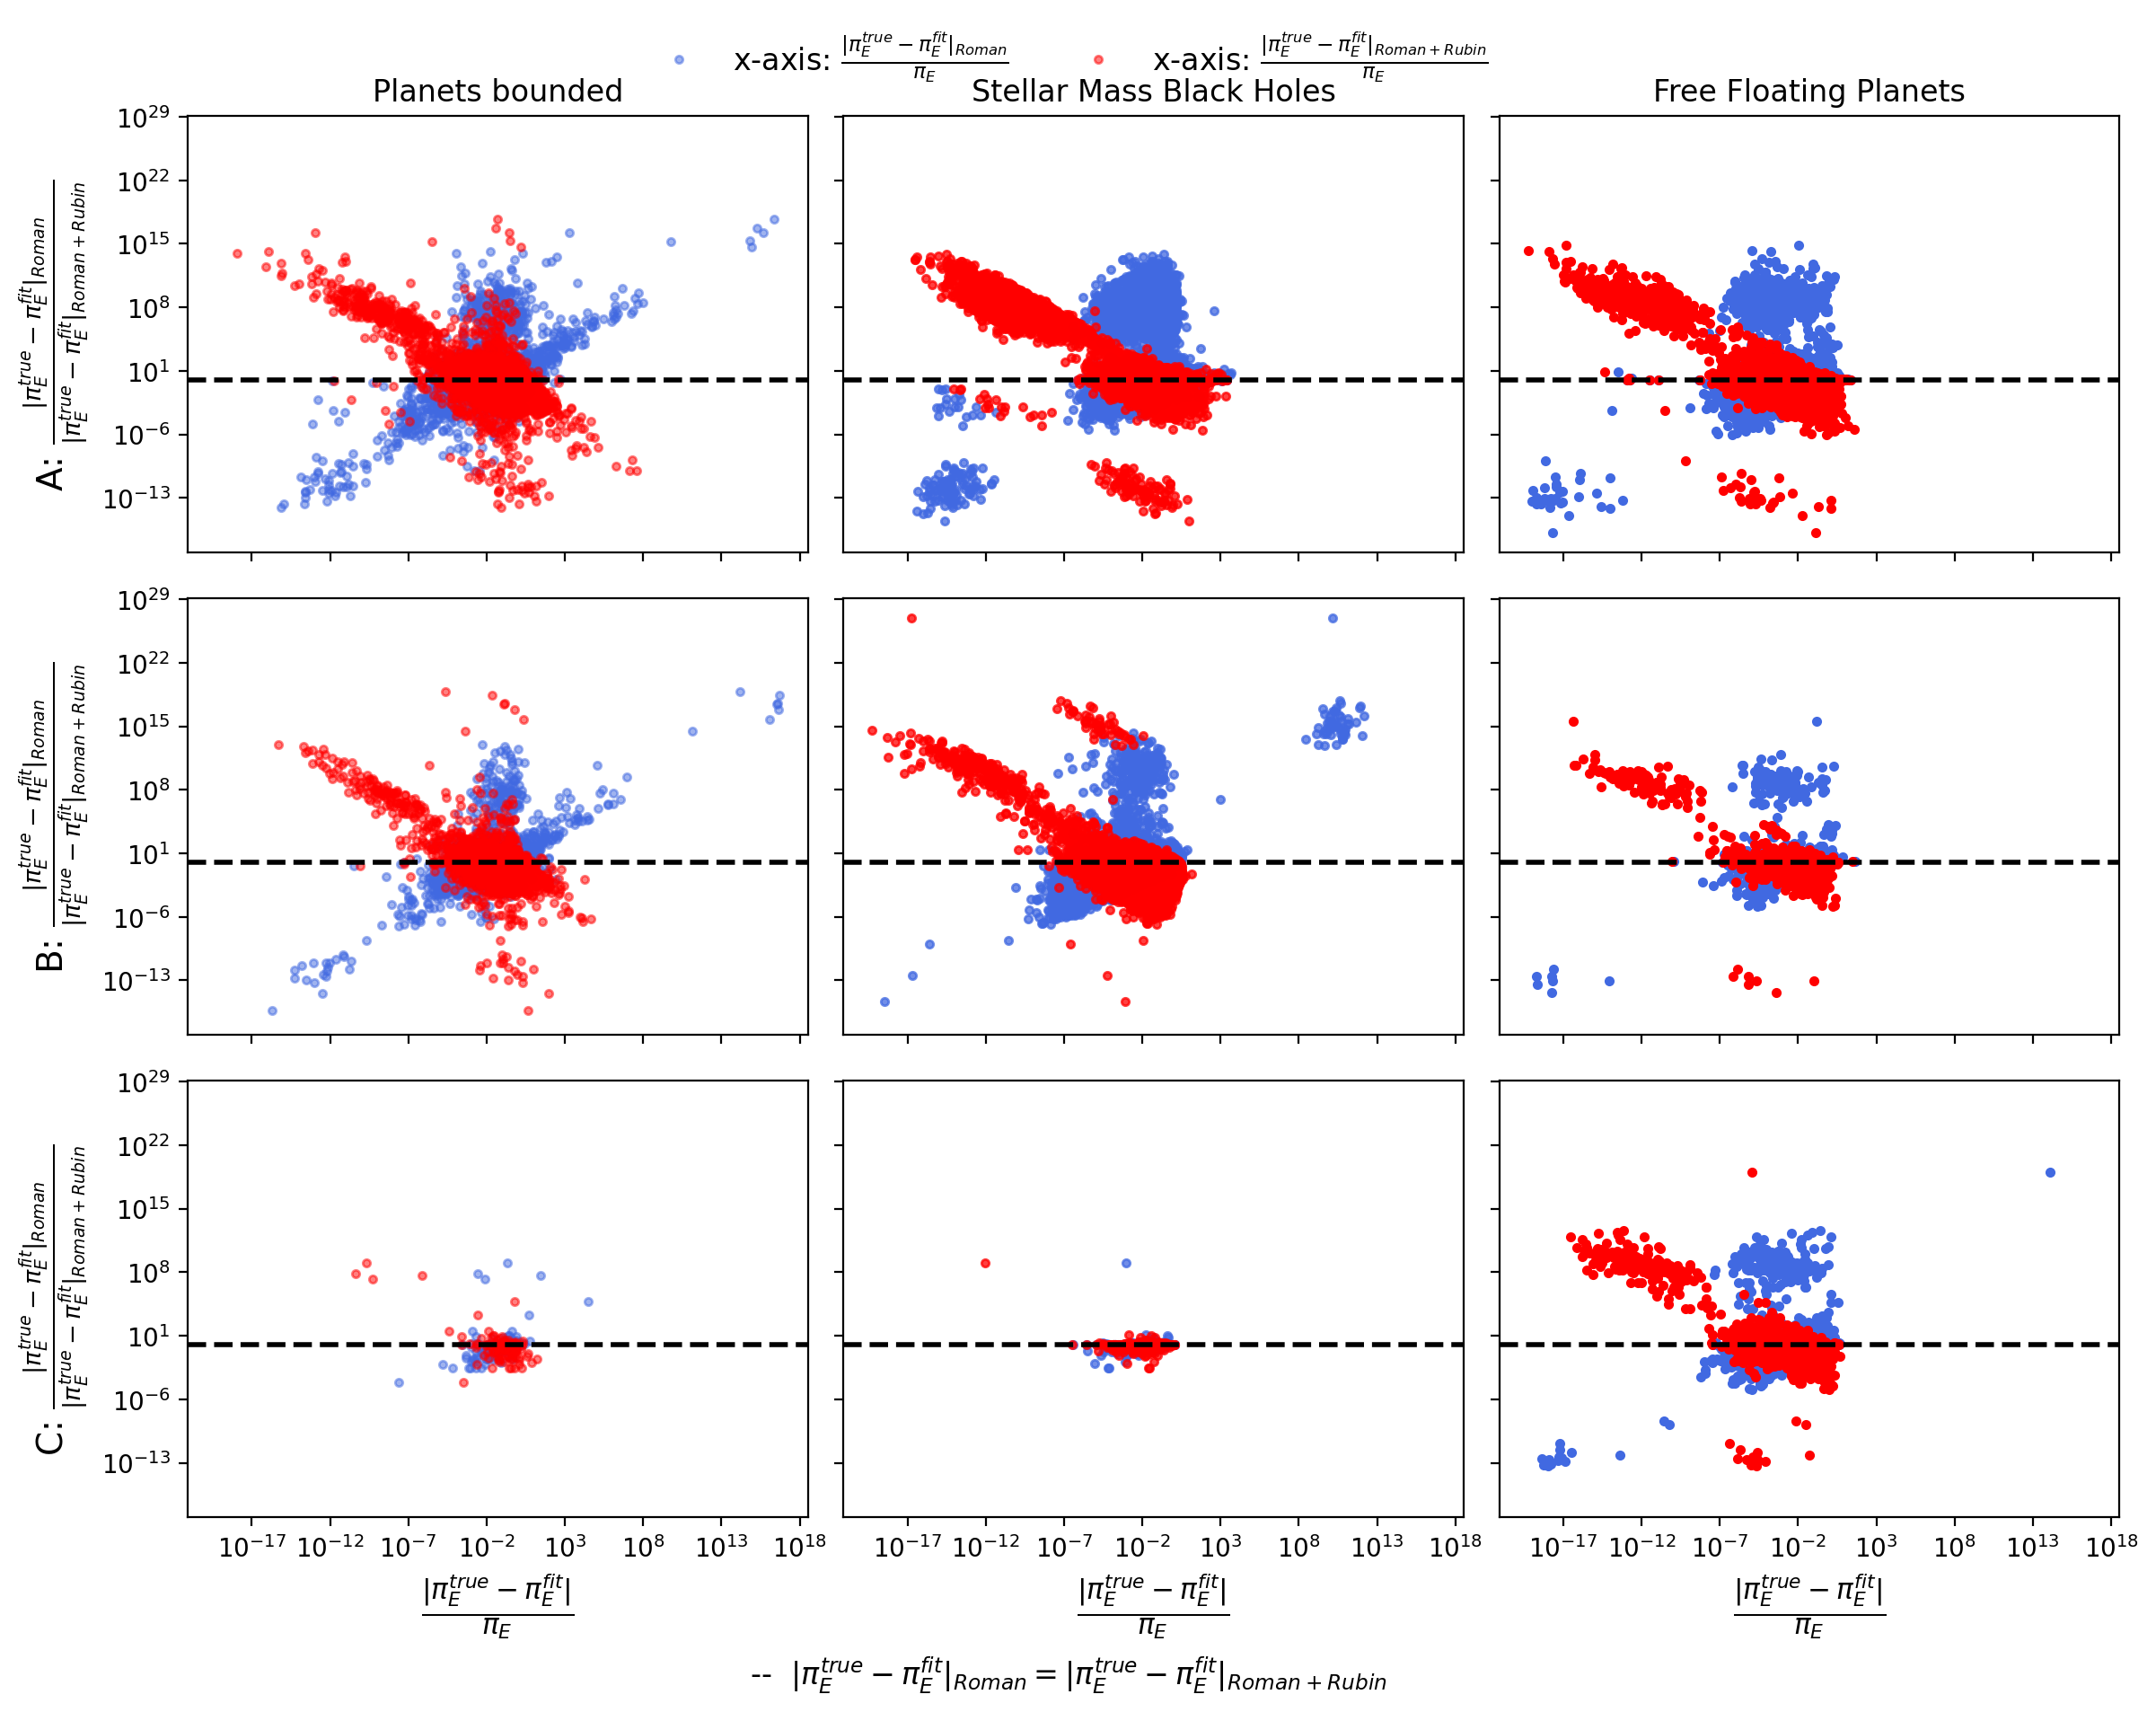

In [71]:
fig, axs = plt.subplots(3, 3, figsize=(12, 9), dpi=200, sharey=True, sharex=True)
example_handles = []
example_labels = []

for row_idx, cat in enumerate(['A', 'B', 'C']):
    for col_idx, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
        ax = axs[row_idx, col_idx]
        categories = df_metrics.loc[Class, 'fit_rr']['metric2']['Category']
        df0 = df_metrics.loc[Class, 'fit_roman']['metric2']
        df1 = df_metrics.loc[Class, 'fit_rr']['metric2']
        
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna()
        mask &= df1['tE'] != 0
        if not np.any(mask):
            continue

        # Plot using fit_roman as x-axis
        p0 = ax.plot(
            df0['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            alpha=0.5+col_idx*0.25,
            color='royalblue',
            label='fit_roman'
        )

        # Plot using fit_rr as x-axis
        p1 = ax.plot(
            df1['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            alpha=0.5+col_idx*0.25,
            color='red',
            label='fit_rr'
        )

        if row_idx == 0 and col_idx == 0:
            example_handles.extend([p0[0], p1[0]])
            # example_labels.extend([
            #     r'x-axis: $\pi_E^{fit, Roman}$',
            #     r'x-axis: $\pi_E^{fit, Roman+Rubin}$'
            # ])
            example_labels.extend([r'x-axis: $\frac{|\pi_E^{true}-\pi_E^{fit}|_{Roman}}{\pi_E}$', r'x-axis: $\frac{|\pi_E^{true}-\pi_E^{fit}|_{Roman+Rubin}}{\pi_E}$'])
        ax.axhline(1, color='k', linestyle='--', linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')

        if row_idx == 2:
            ax.set_xlabel(r'$\frac{|\pi_E^{true}-\pi_E^{fit}|}{\pi_E}$', fontsize=16)

        if col_idx == 0:
            ax.set_ylabel(
                rf"{cat}: $\frac{{|\pi_E^{{true}} - \pi_E^{{fit}}|_{{Roman}}}}{{|\pi_E^{{true}} - \pi_E^{{fit}}|_{{Roman+Rubin}}}}$",
                fontsize=14
            )
        if row_idx == 0:
            ax.set_title(dictionary_class[Class])

fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.text(0.5, 0.01, r'--  $|\pi_E^{true}-\pi_E^{fit}|_{Roman} = |\pi_E^{true}-\pi_E^{fit}|_{Roman+Rubin}$',
         ha='center', fontsize=12, color='k')

plt.tight_layout(rect=[0, 0.02, 1, 1.02])
plt.show()


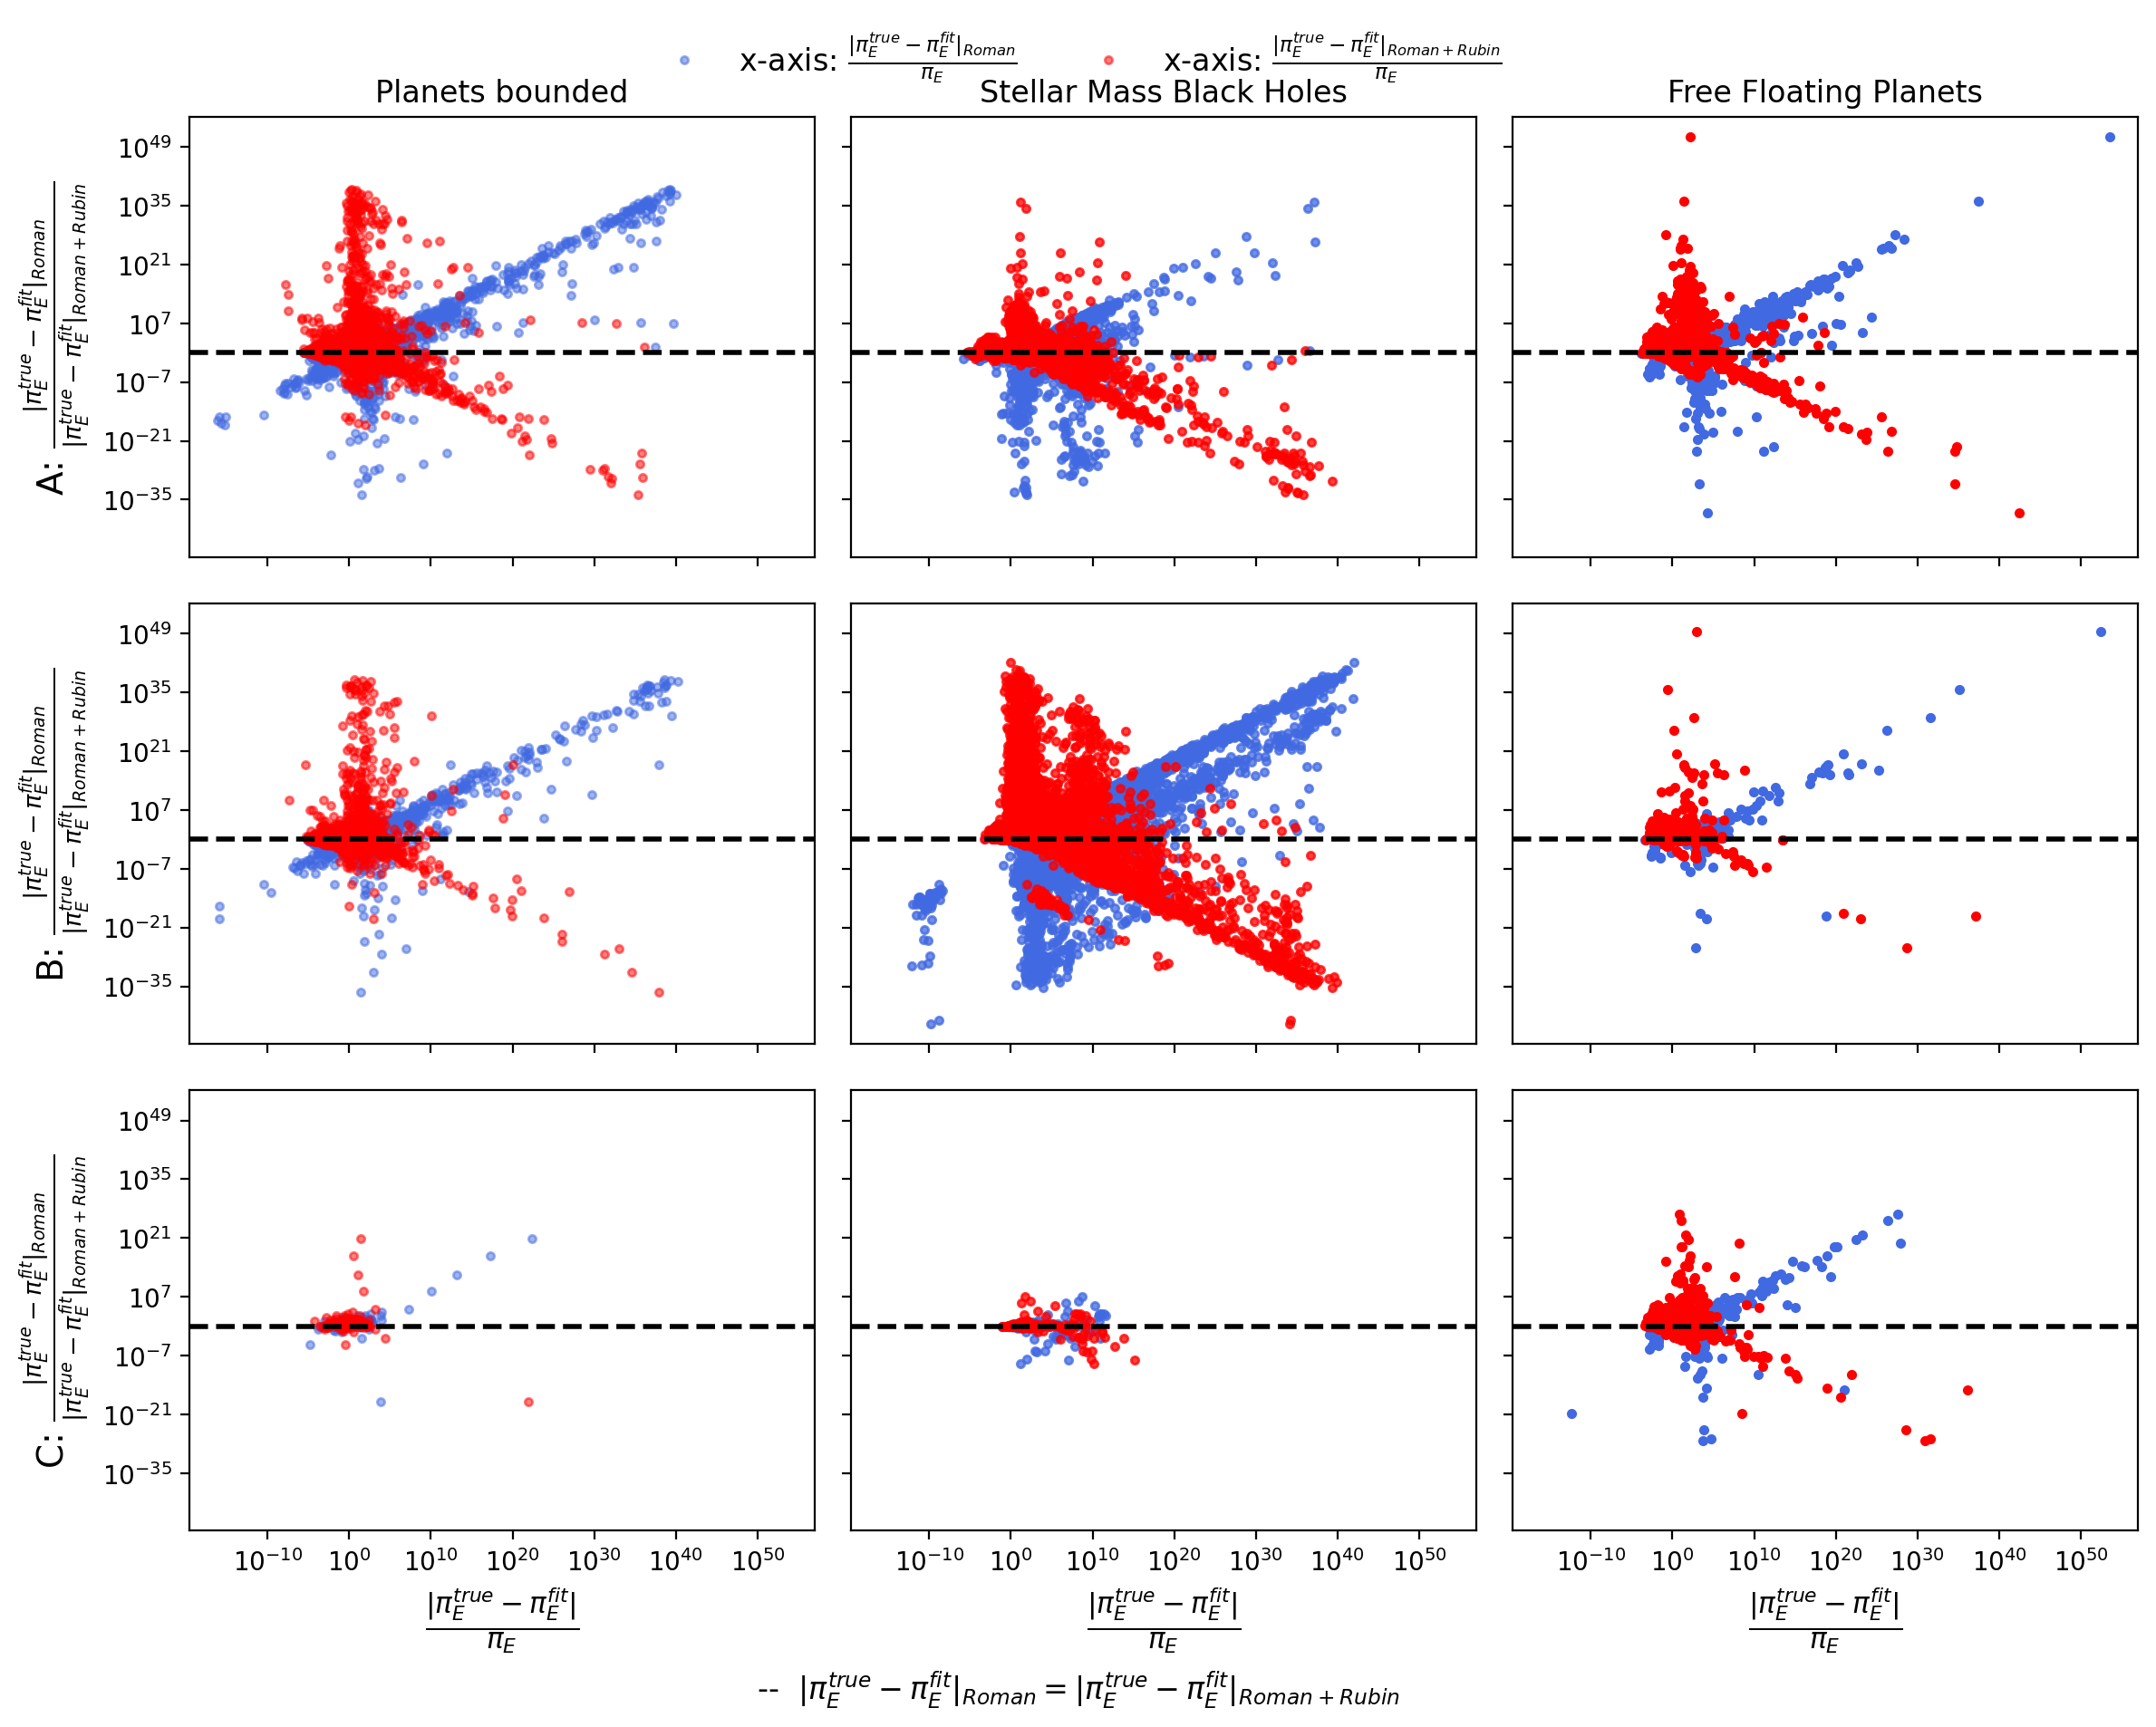

In [72]:
fig, axs = plt.subplots(3, 3, figsize=(12, 9), dpi=200, sharey=True, sharex=True)
example_handles = []
example_labels = []

for row_idx, cat in enumerate(['A', 'B', 'C']):
    for col_idx, Class in enumerate(['USBL', 'PSPL', 'FSPL']):
        ax = axs[row_idx, col_idx]
        categories = df_metrics.loc[Class, 'fit_rr']['metric3']['Category']
        df0 = df_metrics.loc[Class, 'fit_roman']['metric3']
        df1 = df_metrics.loc[Class, 'fit_rr']['metric3']
        
        mask = categories == cat
        mask &= df1['tE'].notna() & df0['tE'].notna()
        mask &= df1['tE'] != 0
        if not np.any(mask):
            continue

        # Plot using fit_roman as x-axis
        p0 = ax.plot(
            df0['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            alpha=0.5+col_idx*0.25,
            color='royalblue',
            label='fit_roman'
        )

        # Plot using fit_rr as x-axis
        p1 = ax.plot(
            df1['piE'][mask],
            df0['piE'][mask] / df1['piE'][mask],
            marker='.',
            linestyle='',
            alpha=0.5+col_idx*0.25,
            color='red',
            label='fit_rr'
        )

        if row_idx == 0 and col_idx == 0:
            example_handles.extend([p0[0], p1[0]])
            # example_labels.extend([
            #     r'x-axis: $\pi_E^{fit, Roman}$',
            #     r'x-axis: $\pi_E^{fit, Roman+Rubin}$'
            # ])
            example_labels.extend([r'x-axis: $\frac{|\pi_E^{true}-\pi_E^{fit}|_{Roman}}{\pi_E}$', r'x-axis: $\frac{|\pi_E^{true}-\pi_E^{fit}|_{Roman+Rubin}}{\pi_E}$'])
        ax.axhline(1, color='k', linestyle='--', linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')

        if row_idx == 2:
            ax.set_xlabel(r'$\frac{|\pi_E^{true}-\pi_E^{fit}|}{\pi_E}$', fontsize=16)

        if col_idx == 0:
            ax.set_ylabel(
                rf"{cat}: $\frac{{|\pi_E^{{true}} - \pi_E^{{fit}}|_{{Roman}}}}{{|\pi_E^{{true}} - \pi_E^{{fit}}|_{{Roman+Rubin}}}}$",
                fontsize=14
            )
        if row_idx == 0:
            ax.set_title(dictionary_class[Class])

fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.text(0.5, 0.01, r'--  $|\pi_E^{true}-\pi_E^{fit}|_{Roman} = |\pi_E^{true}-\pi_E^{fit}|_{Roman+Rubin}$',
         ha='center', fontsize=12, color='k')

plt.tight_layout(rect=[0, 0.02, 1, 1.02])
plt.show()


# Paramter $\rho$ asociated with finite size source effect

<Figure size 800x600 with 0 Axes>

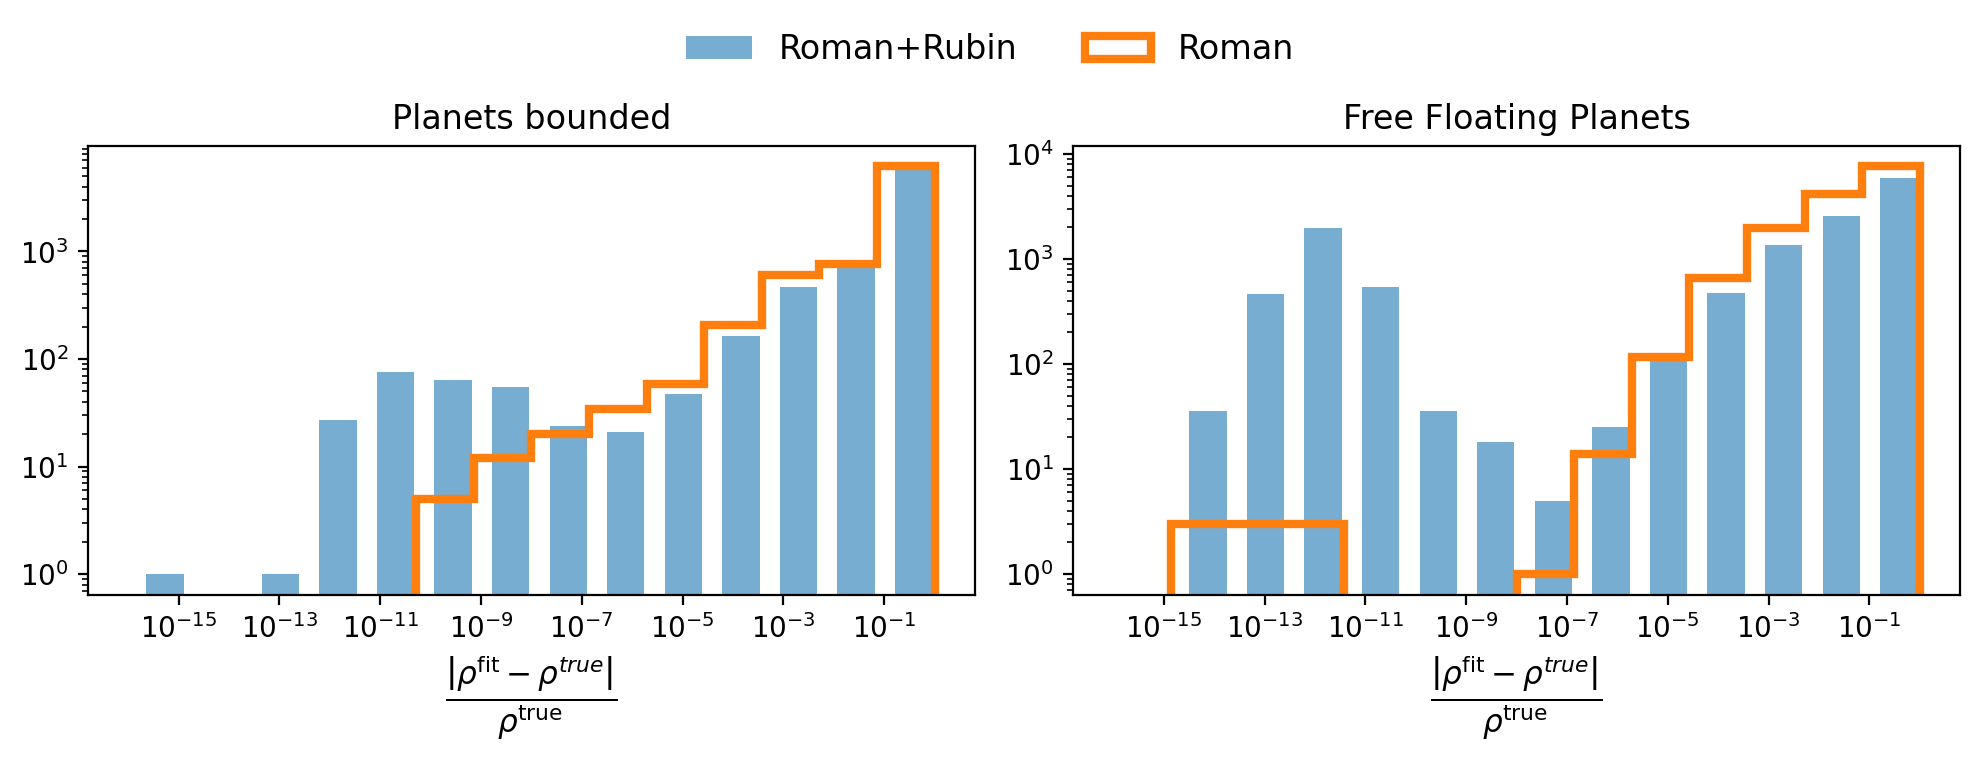

In [16]:
plt.figure(figsize=(8,6))
fig, axs = plt.subplots(1, 2, figsize=(10, 3.5), dpi=200)
axs = axs.flatten()
for i,Class in enumerate(['USBL', 'FSPL']):
    df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
    df2 = df_metrics.loc[Class, 'fit_roman']['metric1']
    axs[i].hist(df1['rho'], bins=np.logspace(-16,0,15), rwidth=0.8,alpha=0.6,label='Roman+Rubin')
    axs[i].hist(df2['rho'], bins=np.logspace(-16,0,15), histtype='step',linewidth=3,alpha=1,label='Roman')
    axs[i].set_yscale('log')
    axs[i].set_xscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('metric 1 in tE')
    axs[i].set_xlabel(param_latex('\\rho'), fontsize=16)
    # axs[i].legend(loc='best')
    
    if i == 0:
        handles, labels = axs[i].get_legend_handles_labels()
        example_handles = handles
        example_labels = labels

fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/met_1_rho.png')

# Bias relative to the true value for $\pi_E$

{'A': 'Roman + Rubin', 'B': ' Rubin', 'C': ' Roman', 'D': 'None'}


<Figure size 800x600 with 0 Axes>

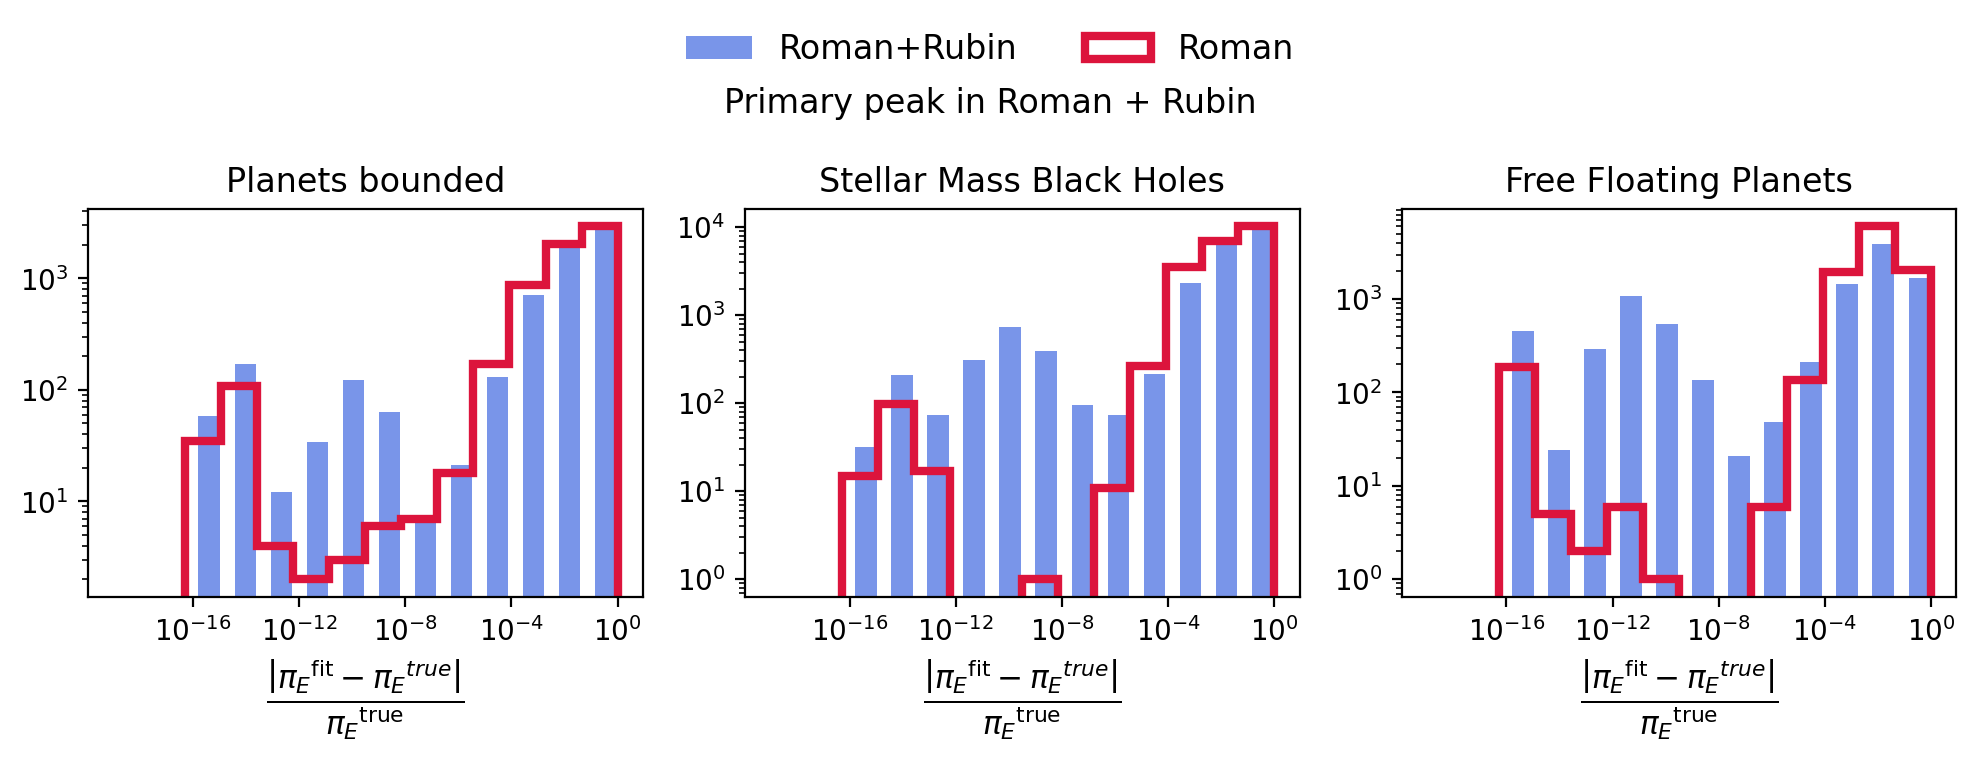

{'A': 'Roman + Rubin', 'B': ' Rubin', 'C': ' Roman', 'D': 'None'}


<Figure size 800x600 with 0 Axes>

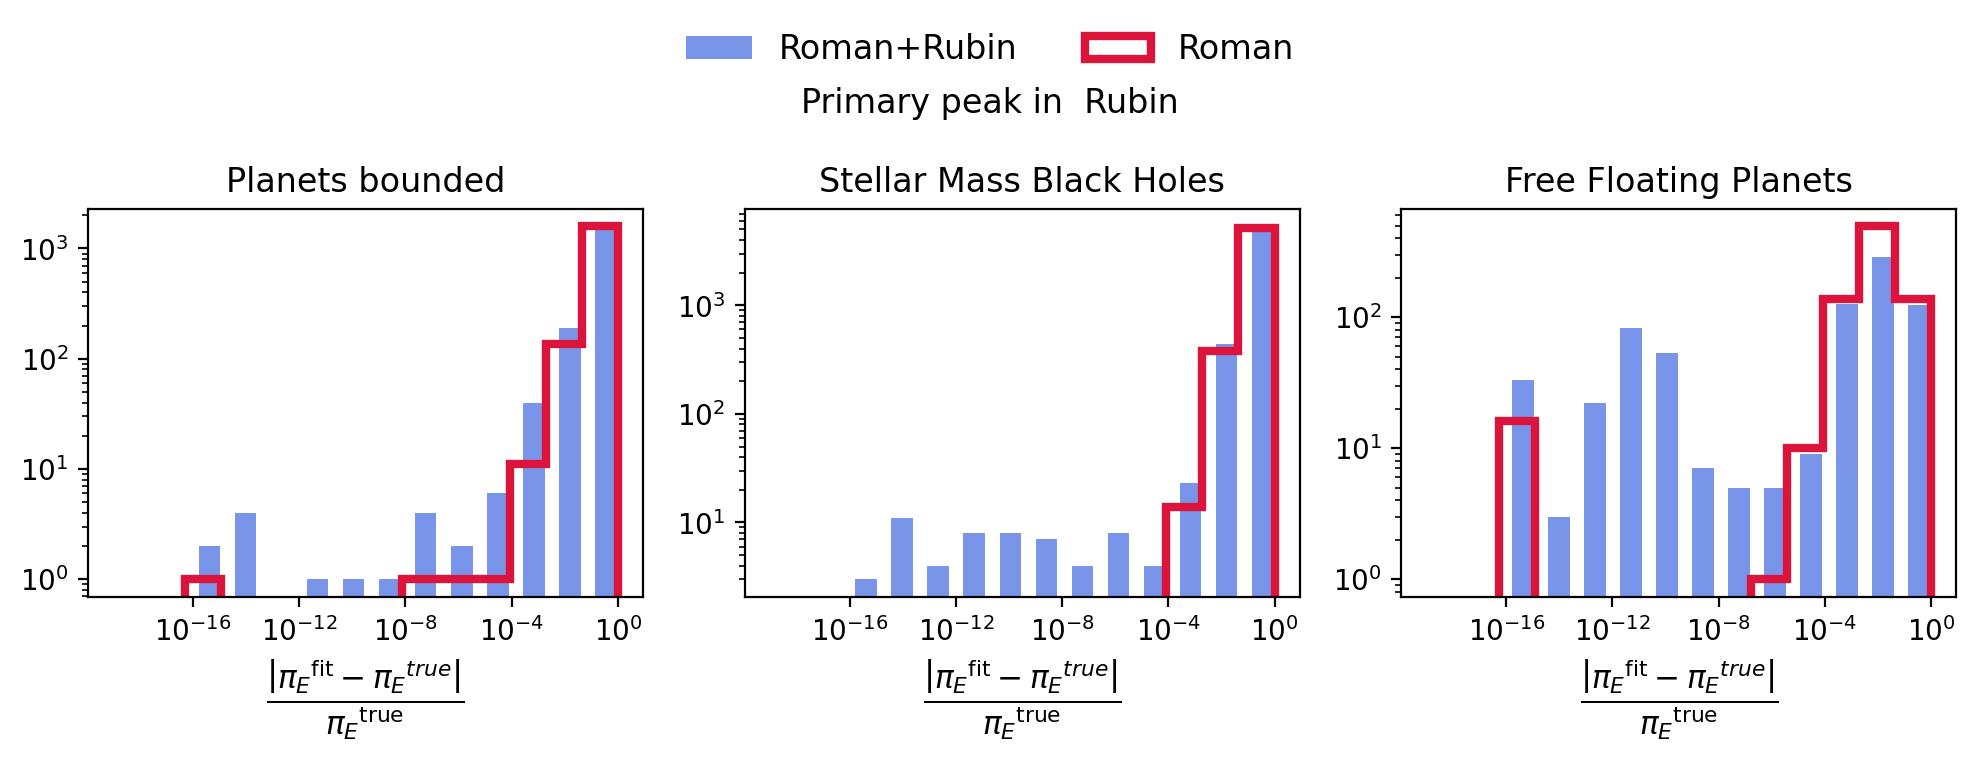

{'A': 'Roman + Rubin', 'B': ' Rubin', 'C': ' Roman', 'D': 'None'}


<Figure size 800x600 with 0 Axes>

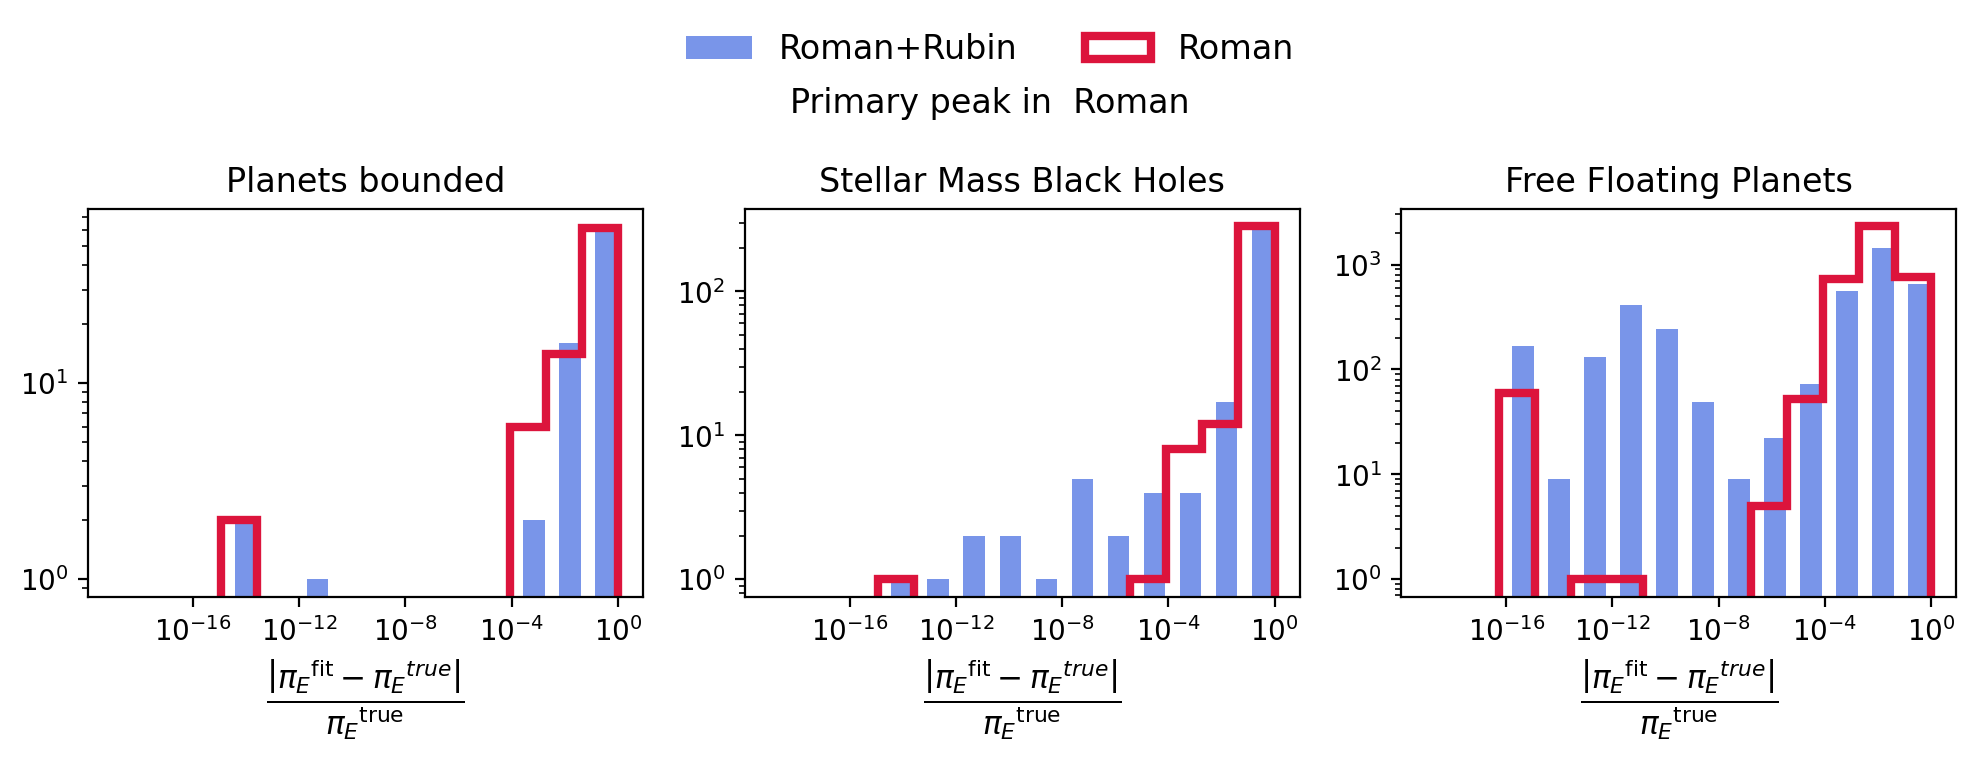

In [18]:

for i,cat in enumerate('ABC'):
    plt.figure(figsize=(8,6))
    fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200)
    axs = axs.flatten()
    for i,Class in enumerate(['USBL', 'PSPL', 'FSPL']):
        mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']==cat
        df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
        df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
        axs[i].hist(df1['piE'], bins=np.logspace(-19,0,15), rwidth=0.8,alpha=0.7,color='royalblue',label='Roman+Rubin')
        axs[i].hist(df2['piE'], bins=np.logspace(-19,0,15), histtype='step',linewidth=3,color='crimson',alpha=1,label='Roman')
        axs[i].set_yscale('log')
        axs[i].set_xscale('log')
        axs[i].set_title(dictionary_class[Class])
        axs[i].set_xlabel('metric 1 in tE')
        axs[i].set_xlabel(param_latex('\pi_E'), fontsize=16)
        if i == 0:
            handles, labels = axs[i].get_legend_handles_labels()
            example_handles = handles
            example_labels = labels
    print(category_names)
    plt.suptitle(f'Primary peak in {category_names[cat]}')
    fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.1))
    plt.tight_layout()
    plt.show()

# Bias relative to the true value for $t_E$

<Figure size 800x600 with 0 Axes>

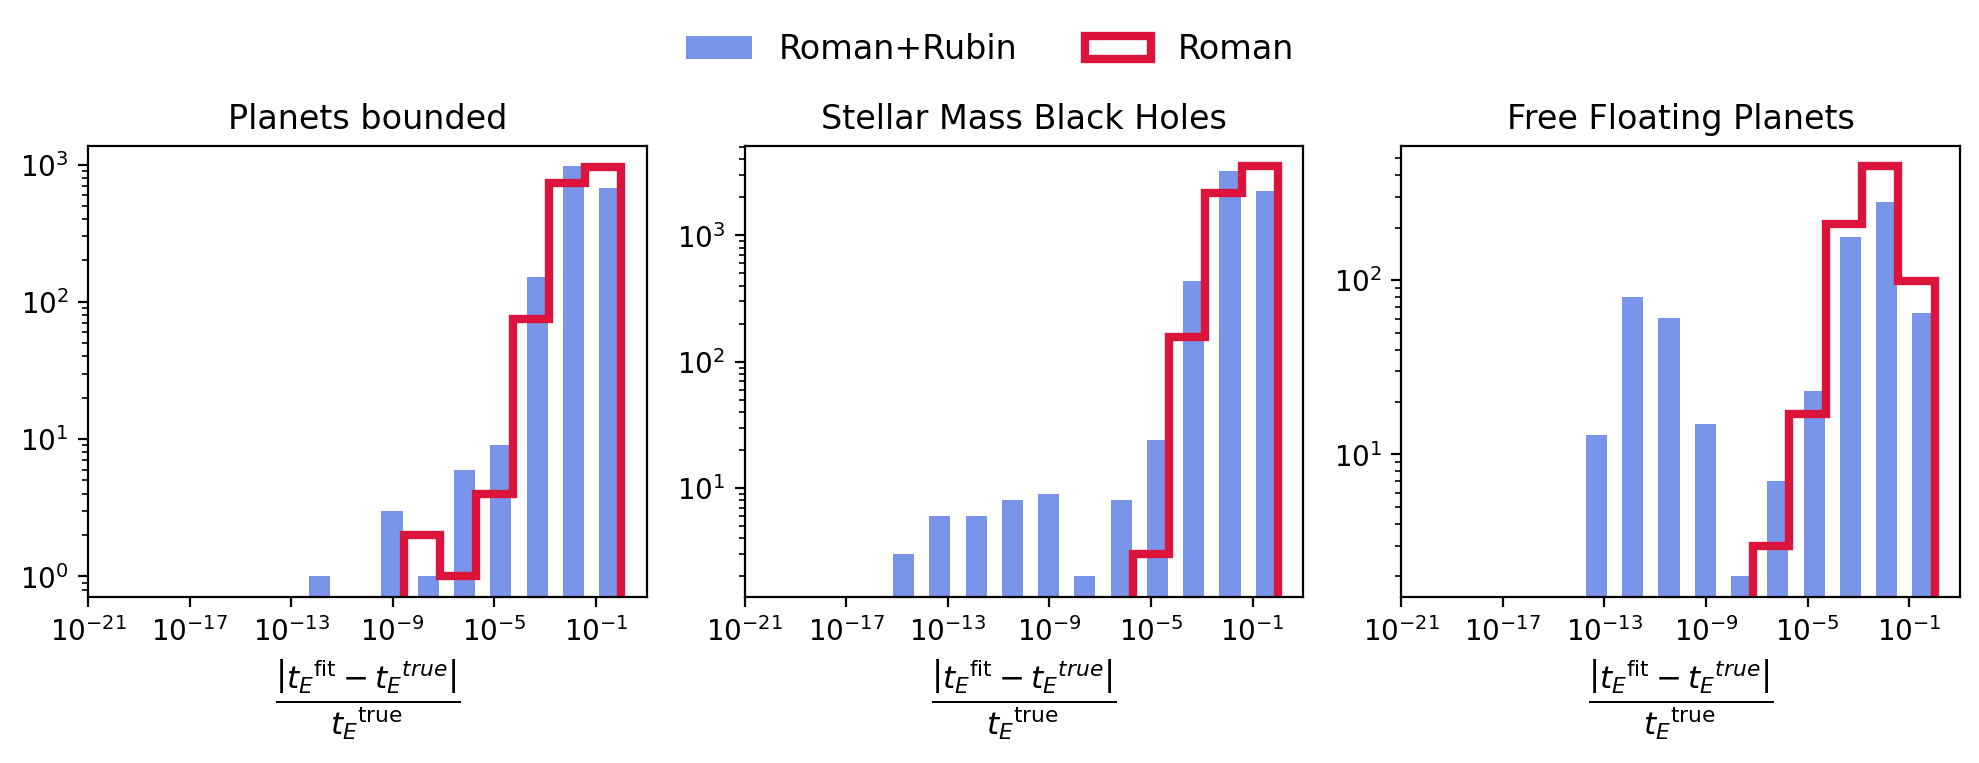

In [19]:

plt.figure(figsize=(8,6))
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), dpi=200)
axs = axs.flatten()
for i,Class in enumerate(['USBL', 'PSPL', 'FSPL']):
    mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category']=='B'
    df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
    df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
    axs[i].hist(df1['tE'], bins=np.logspace(-20,0,15), rwidth=0.8,alpha=0.7,color='royalblue',label='Roman+Rubin')
    axs[i].hist(df2['tE'], bins=np.logspace(-20,0,15), histtype='step',linewidth=3,color='crimson',alpha=1,label='Roman')
    axs[i].set_yscale('log')
    axs[i].set_xscale('log')
    axs[i].set_title(dictionary_class[Class])
    axs[i].set_xlabel('metric 1 in tE')
    axs[i].set_xlabel(param_latex('t_E'), fontsize=16)
    if i == 0:
        handles, labels = axs[i].get_legend_handles_labels()
        example_handles = handles
        example_labels = labels

fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()

# Categories in the secondary peak in binary lens events

the interval is now defined as $[t_{center} - \sqrt{q}t_E,t_{center} +\sqrt{q}t_E]$

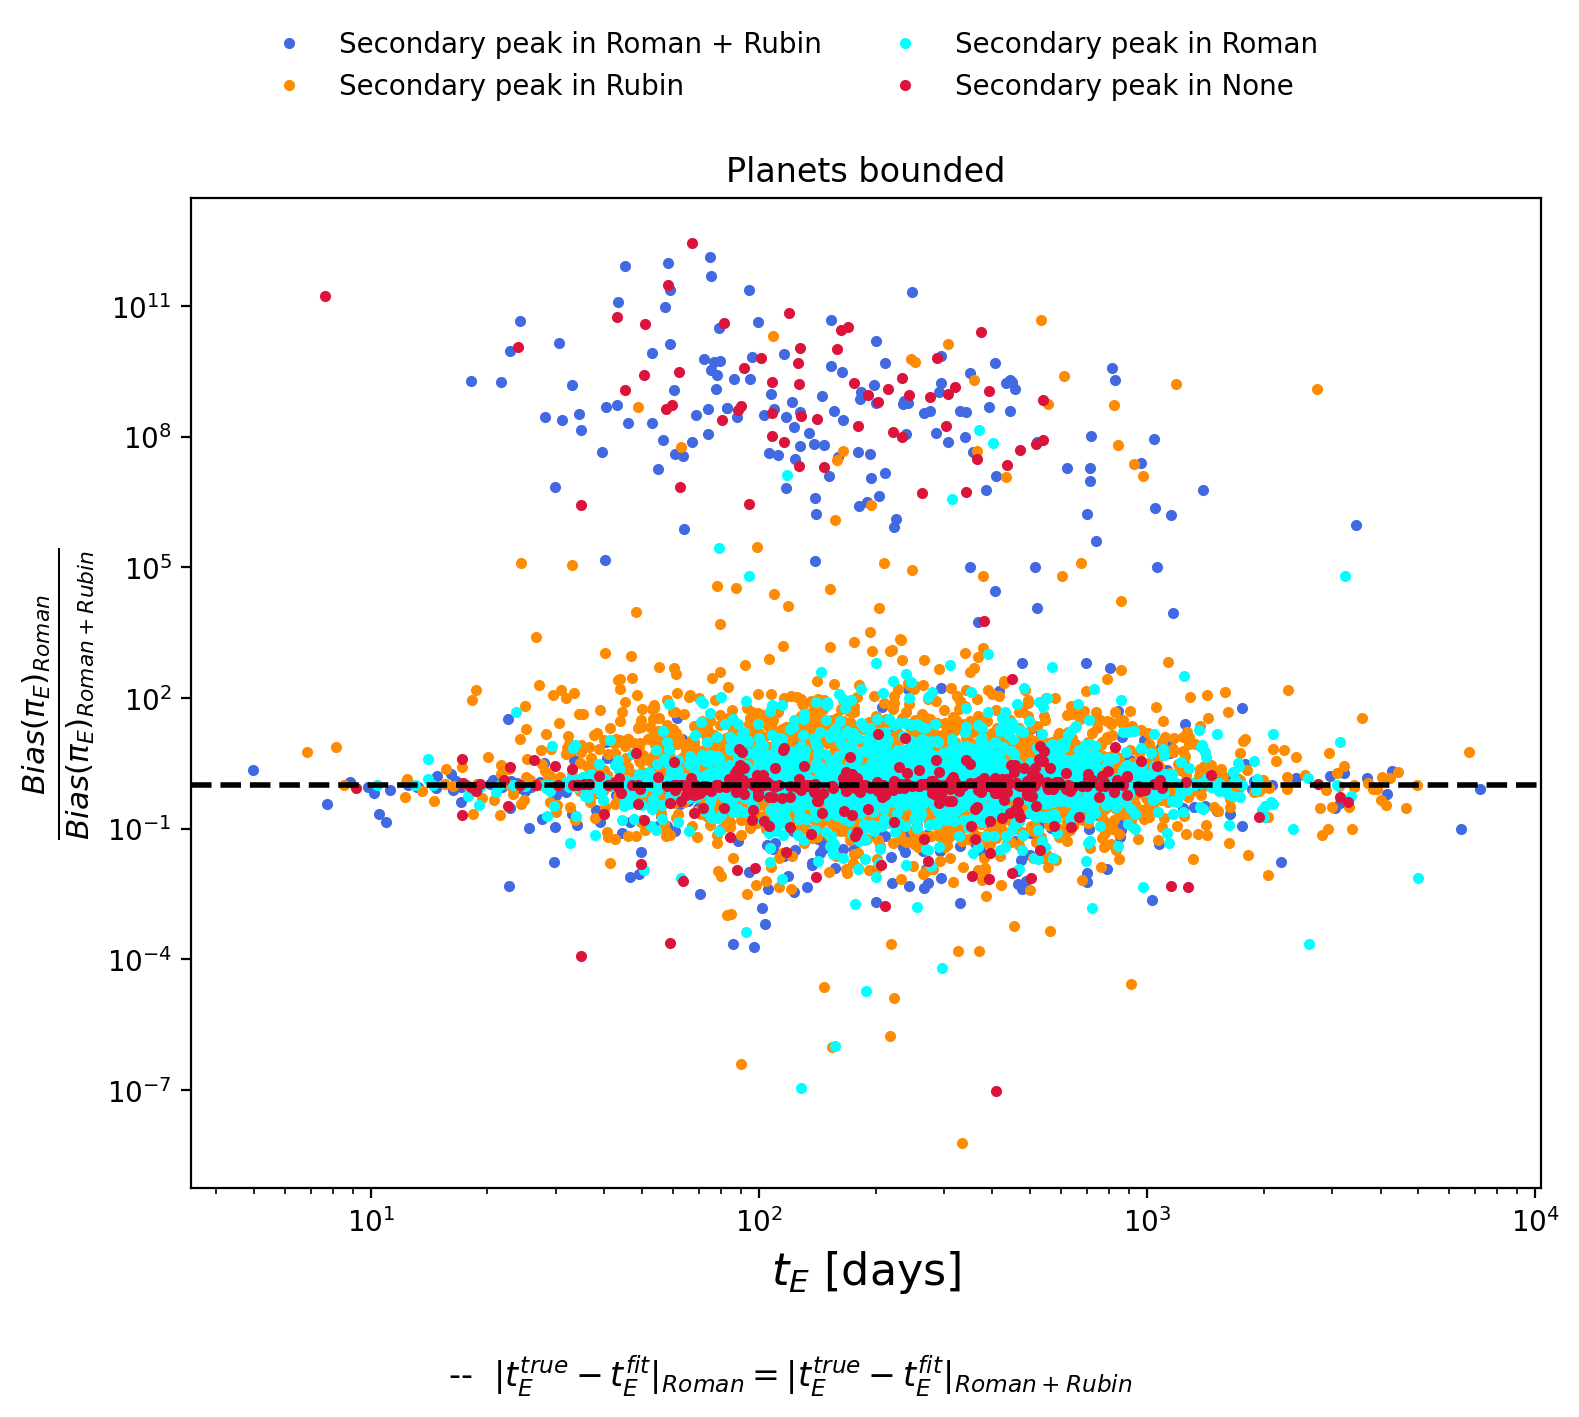

In [20]:
category_colors = {1: 'royalblue', 2: 'darkorange', 3: 'cyan', 4: 'crimson'}
category_names = {1: 'Roman + Rubin', 2: 'Rubin', 3: 'Roman', 4: 'None'}

fig, axs = plt.subplots(1, 1, figsize=(8, 6), dpi=200)

for i, Class in enumerate(['USBL']):
    # Extraer categoría para todos los datos (no solo 'B')
    categories = df_metrics.loc[Class, 'fit_rr']['metric1']['Category_p']
    
    df0 = df_metrics.loc[Class, 'fit_roman']['metric1']
    df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
    df2 = data[Class]['true']
    
    for cat in [1, 2, 3, 4]:
        mask = categories == cat
        if not np.any(mask):
            continue  # Saltear si no hay datos de esa categoría

        # Evitar división por cero
        denom = df1['tE'][mask]
        valid = denom != 0

        if not np.any(valid):
            continue  # Saltear si todos los valores son cero

        axs.plot(
            df2['tE'][mask][valid],
            df0['tE'][mask][valid] / denom[valid],
            marker='.',
            linestyle='',
            label=f'Secondary peak in {category_names[cat]}',
            color=category_colors[cat],
        )
    
    axs.axhline(1, color='k', linestyle='--', linewidth=2)
    # ,
                   # label=r'$|t_E^{true}-t_E^{fit}|_{Roman} = |t_E^{true}-t_E^{fit}|_{Roman+Rubin}$')
    
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_title(dictionary_class[Class])
    axs.set_xlabel('$t_E$ [days]', fontsize=16)
    axs.set_ylabel(r'$\frac{Bias(\pi_E)_{Roman}}{Bias(\pi_E)_{Roman+Rubin}}$', fontsize=16)

    if i == 0:
        handles, labels = axs.get_legend_handles_labels()
        example_handles = handles
        example_labels = labels

fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.1))

# Agregar texto manual para la línea horizontal
fig.text(
    0.5, -0.05,  # x, y en coordenadas de figura (0-1)
    r'--  $|t_E^{true}-t_E^{fit}|_{Roman} = |t_E^{true}-t_E^{fit}|_{Roman+Rubin}$',
    ha='center', fontsize=12, color='k'
)

plt.tight_layout()

plt.savefig('/home/anibal-pc/results_roman_rubin/metrics_plots/ratio_bias_piE_sec_peak.png')
plt.show()


/tmp/ipykernel_55892/2310670963.py:9: RuntimeWarning: divide by zero encountered in divide
  ratio = b / a
/tmp/ipykernel_55892/2310670963.py:9: RuntimeWarning: invalid value encountered in divide
  ratio = b / a


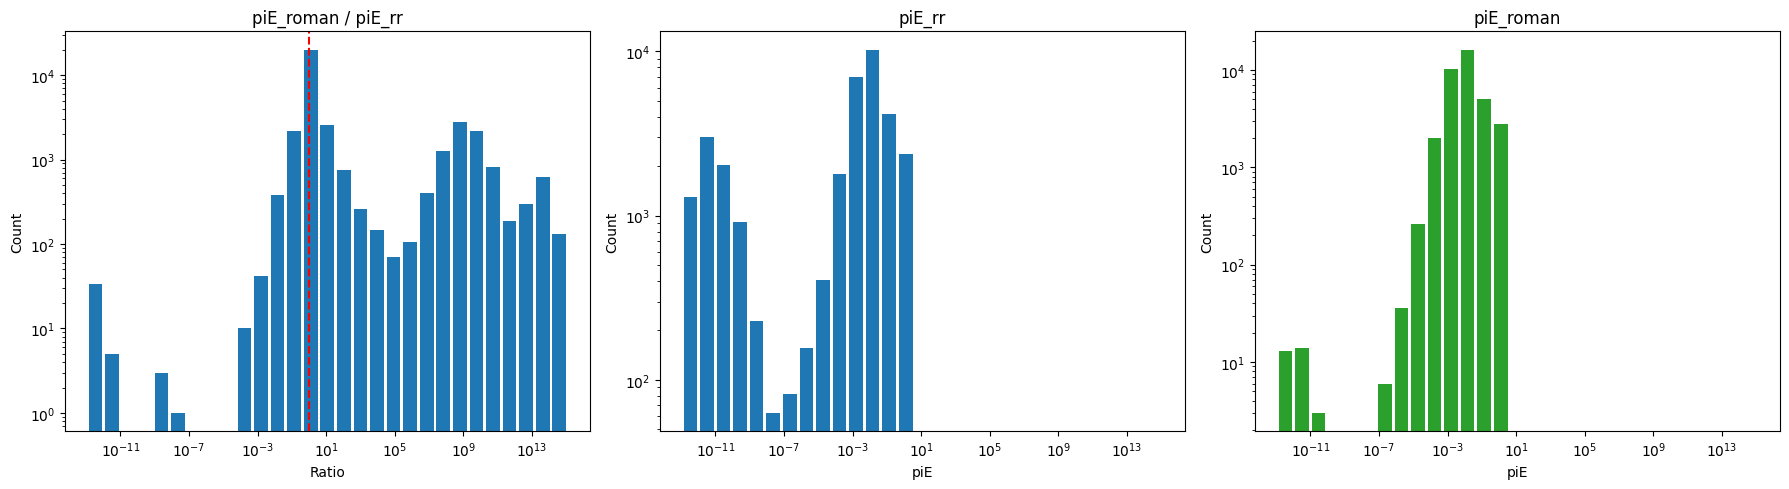

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Get the data
a = np.array(df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE'])
b = np.array(df_metrics.loc['FSPL', 'fit_roman']['metric1']['piE'])

# Compute ratio and clean data
ratio = b / a
ratio = ratio[np.isfinite(ratio)]
a_clean = a[np.isfinite(a)]
b_clean = b[np.isfinite(b)]

# Log-spaced bins
bins = np.logspace(-13, 15, 30)

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot histogram of ratio
axes[0].hist(ratio, bins=bins, rwidth=0.9)
axes[0].axvline(1, color='red', linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('piE_roman / piE_rr')
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Count')

# Plot histogram of a
axes[1].hist(a_clean, bins=bins, rwidth=0.9, color='tab:blue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('piE_rr')
axes[1].set_xlabel('piE')
axes[1].set_ylabel('Count')

# Plot histogram of b
axes[2].hist(b_clean, bins=bins, rwidth=0.9, color='tab:green')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title('piE_roman')
axes[2].set_xlabel('piE')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


/tmp/ipykernel_55892/2197928183.py:3: RuntimeWarning: divide by zero encountered in divide
  ratio = np.array(b) / np.array(a)
/tmp/ipykernel_55892/2197928183.py:3: RuntimeWarning: invalid value encountered in divide
  ratio = np.array(b) / np.array(a)


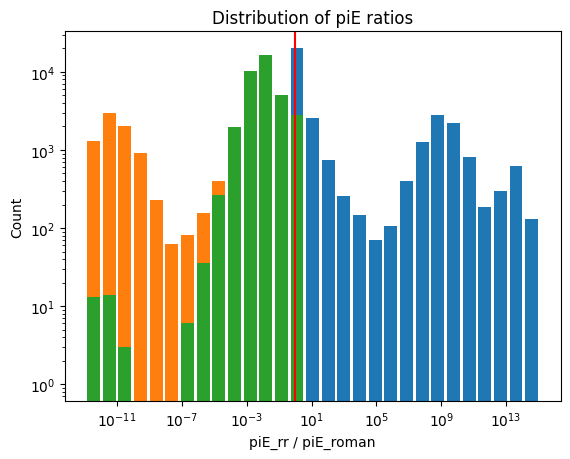

In [56]:
a = df_metrics.loc['FSPL','fit_rr']['metric1']['piE']
b = df_metrics.loc['FSPL','fit_roman']['metric1']['piE']
ratio = np.array(b) / np.array(a)

# Filter out NaNs and infinities
ratio = ratio[np.isfinite(ratio)]

# Plot
plt.hist(ratio, bins=np.logspace(-13,15,30),rwidth=0.9)
plt.hist(a, bins=np.logspace(-13,15,30),rwidth=0.9)
plt.hist(b, bins=np.logspace(-13,15,30),rwidth=0.9)
plt.axvline(1,color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('piE_rr / piE_roman')
plt.ylabel('Count')
plt.title('Distribution of piE ratios')
plt.show()

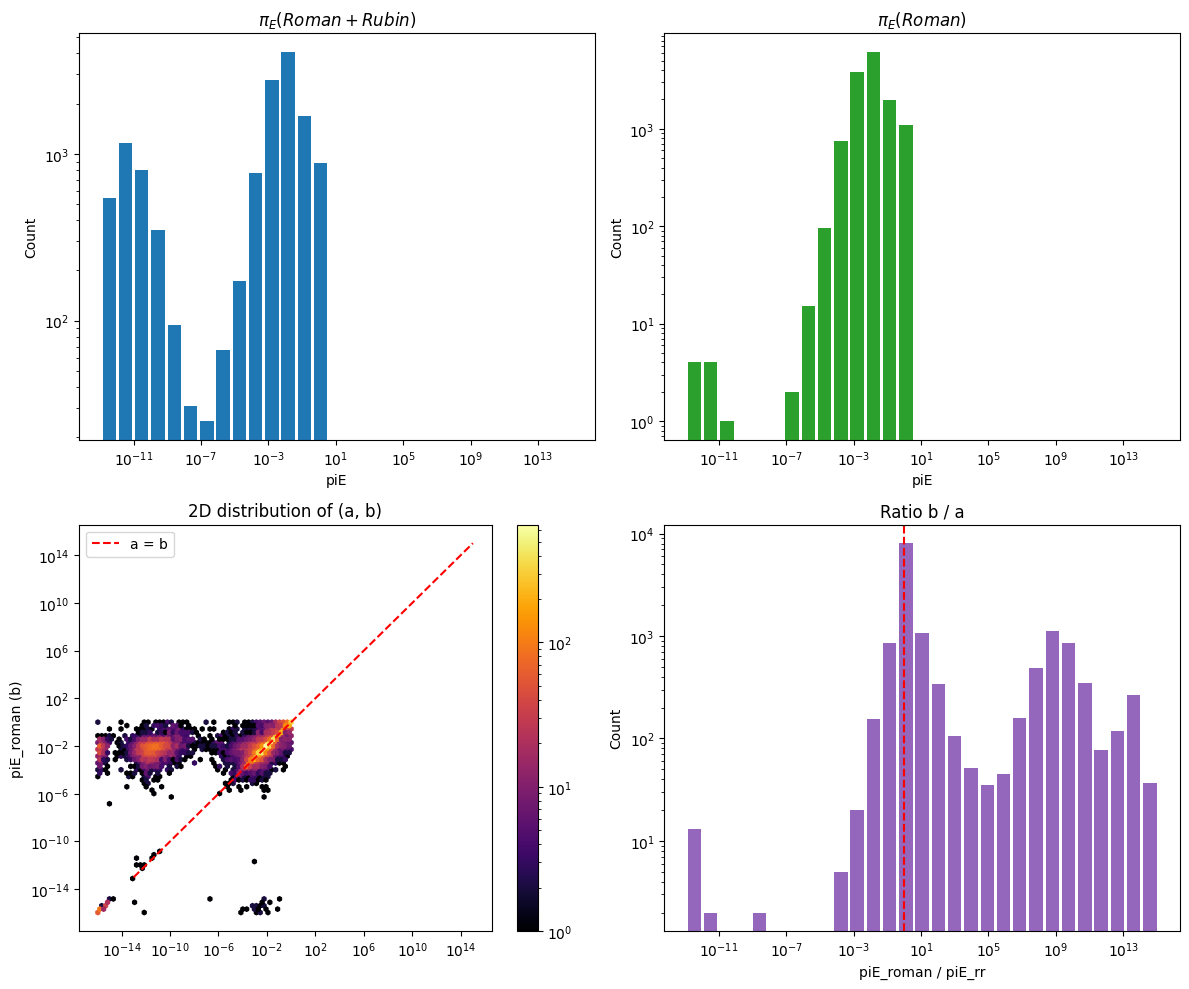

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Get arrays and clean
a = np.array(df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE'])
b = np.array(df_metrics.loc['FSPL', 'fit_roman']['metric1']['piE'])

# Mask to filter out NaNs and infs
mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)

a = a[mask]
b = b[mask]
ratio = b / a

# Log-spaced bins
bins = np.logspace(-13, 15, 30)

# Set up 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: histogram of a
axes[0, 0].hist(a, bins=bins, rwidth=0.9, color='tab:blue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('$\pi_E (Roman+Rubin)$')
axes[0, 0].set_xlabel('piE')
axes[0, 0].set_ylabel('Count')

# Top-right: histogram of b
axes[0, 1].hist(b, bins=bins, rwidth=0.9, color='tab:green')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('$\pi_E(Roman)$')
axes[0, 1].set_xlabel('piE')
axes[0, 1].set_ylabel('Count')

# Bottom-left: scatter or 2D histogram of a vs b
hb = axes[1, 0].hexbin(a, b, gridsize=50, bins='log', xscale='log', yscale='log', cmap='inferno')
axes[1, 0].plot([1e-13, 1e15], [1e-13, 1e15], color='red', linestyle='--', label='a = b')
# axes[1, 0].set_xlabel('piE_rr (a)')
axes[1, 0].set_ylabel('piE_roman (b)')
axes[1, 0].set_title('2D distribution of (a, b)')
axes[1, 0].legend()
fig.colorbar(hb, ax=axes[1, 0])

# Bottom-right: histogram of ratio
axes[1, 1].hist(ratio, bins=bins, rwidth=0.9, color='tab:purple')
axes[1, 1].axvline(1, color='red', linestyle='--')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Ratio b / a')
axes[1, 1].set_xlabel('piE_roman / piE_rr')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


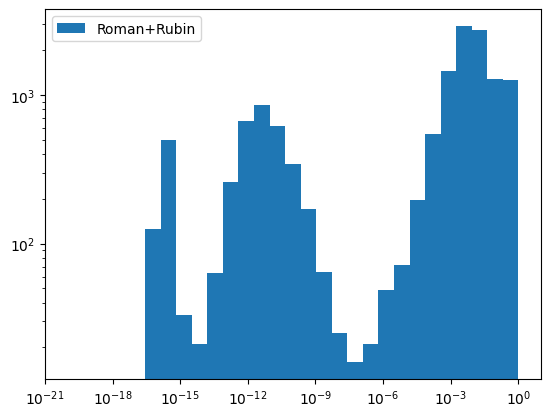

In [86]:
plt.hist(np.array(df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE']),bins=np.logspace(-20,0,30),label='Roman+Rubin')
# plt.hist(np.array(df_metrics.loc['FSPL', 'fit_roman']['metric1']['piE']),bins=np.logspace(-20,1,30),histtype='step',linewidth=3,label='Roman')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best')
plt.show()


In [76]:
# Class = 'FSPL'
# a = df_metrics.loc[Class, 'fit_rr']['metric1']
# sources = a['Source'][a['piE']<1e-10].values
# sources = [sources[i] for i in range(3)]
# download_data([sources[i] for i in range(3)], Class)


In [74]:
# sources = np.array([sources[i] for i in range(3)])
# print(sources)
# sets= np.array([1,1,1])
# print(sets)

In [73]:
# df1[(df1['Source']==sources[0])]

In [71]:
# Class = 'FSPL'
# a = df_metrics.loc[Class, 'fit_rr']['metric1']
# sources = a['Source'][(a['piE']<1e-10)&(a['piE']>1e-14)].values
# sources = [sources[i] for i in range(3)]
# download_data([sources[i] for i in range(3)], Class)


  0%|          | 0/3 [00:00<?, ?it/s]

done
done
done
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Ever

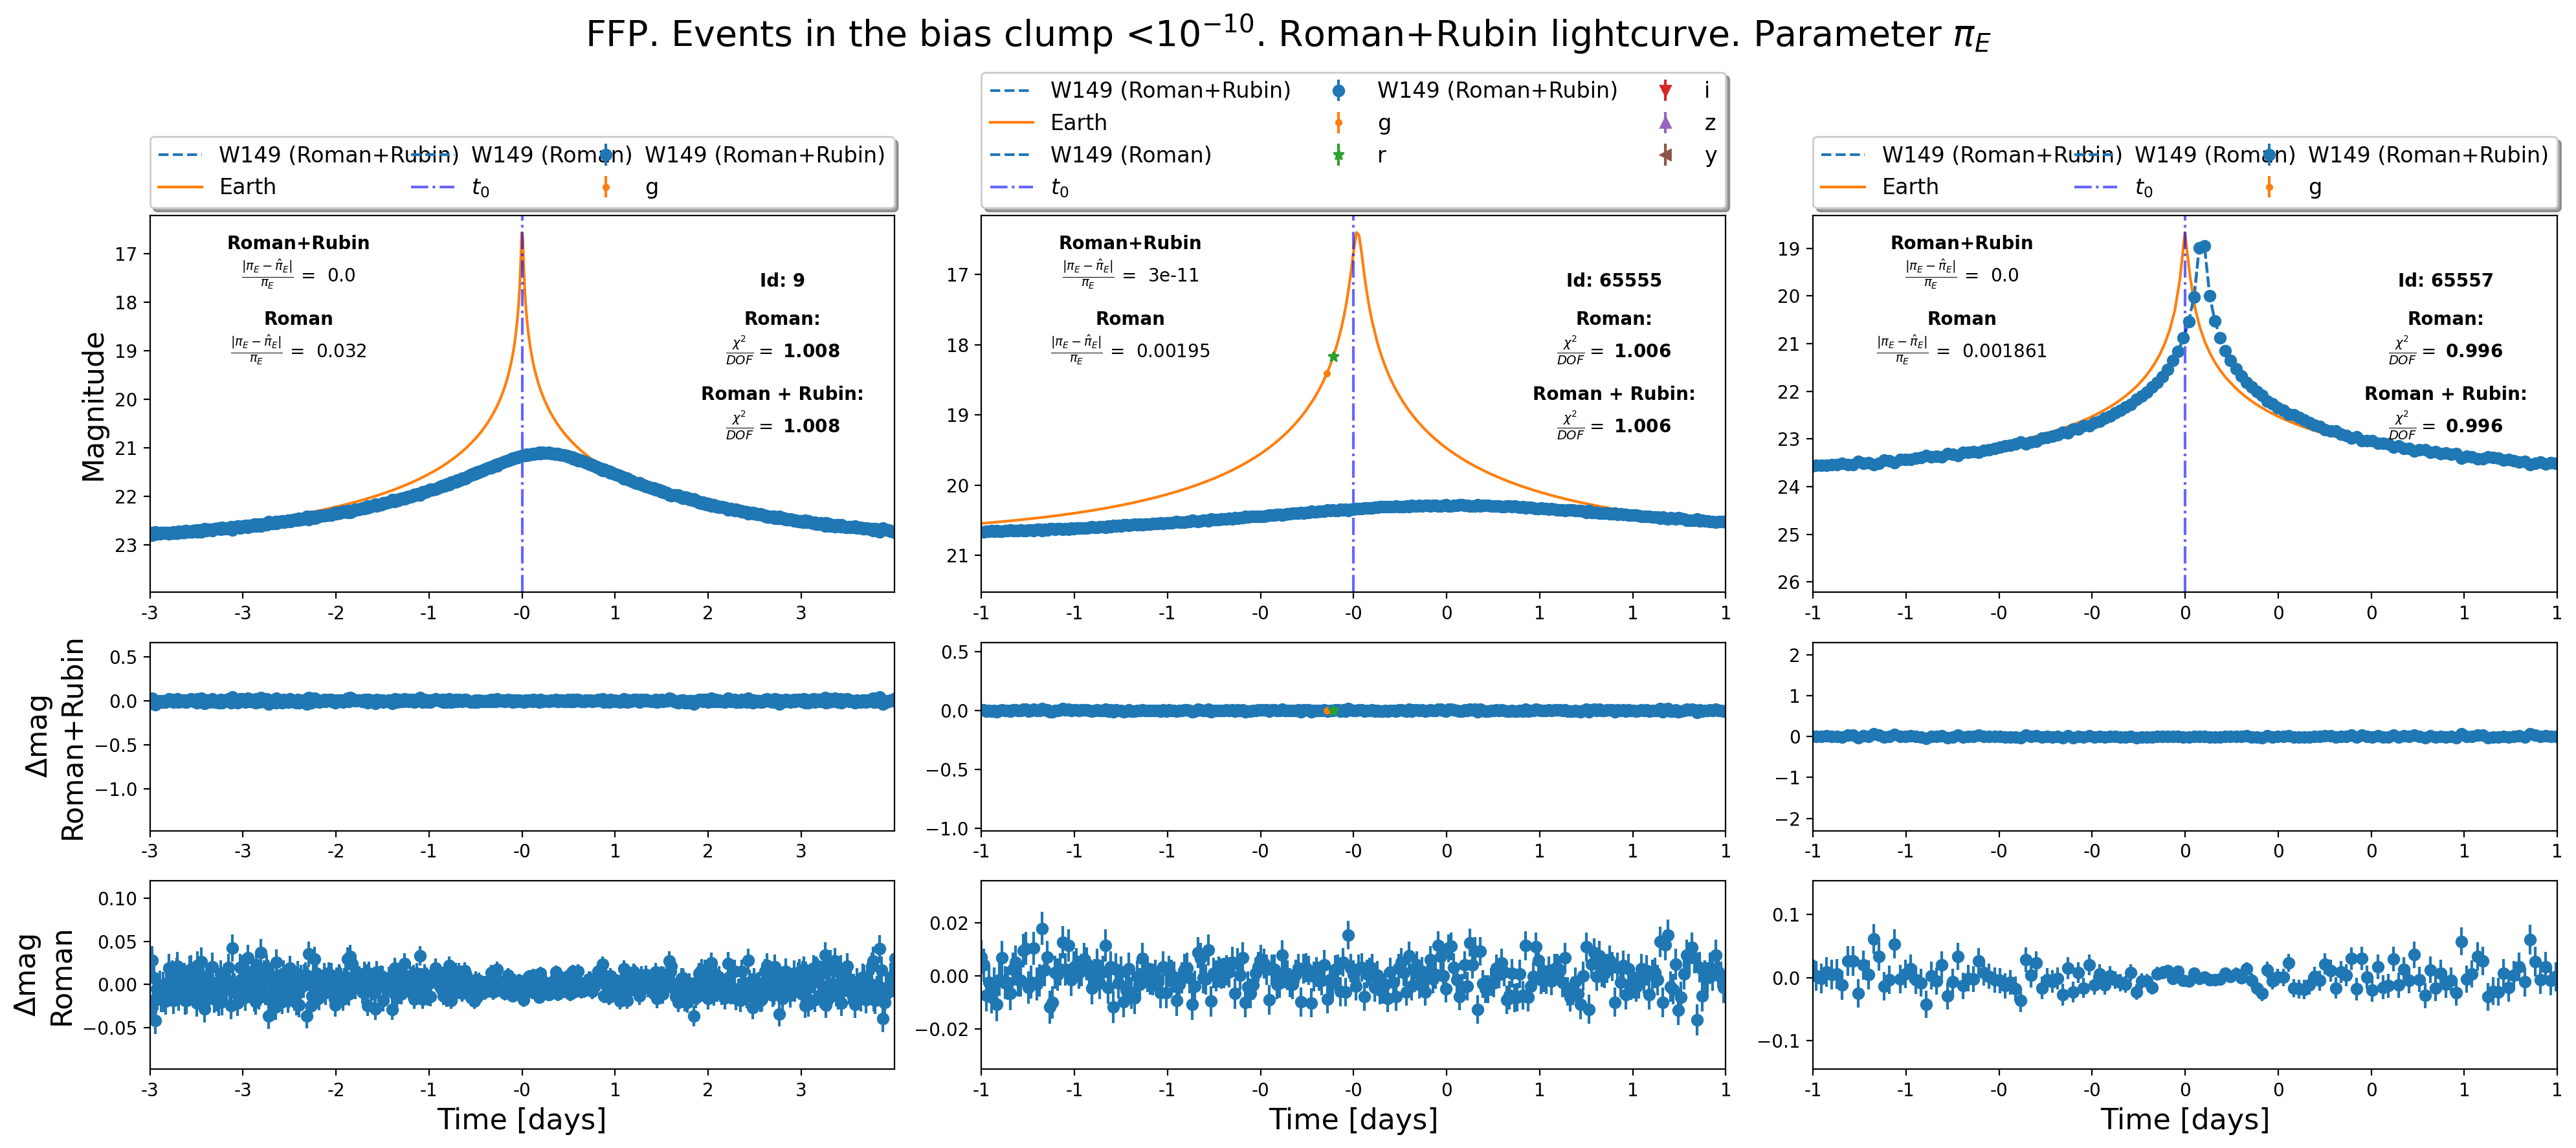

In [75]:
Class = 'FSPL'
a = df_metrics.loc[Class, 'fit_rr']['metric1']
sources = a['Source'][(a['piE']<1e-10)&(a['piE']>1e-14)].values
sources = [sources[i] for i in range(3)]
download_data([sources[i] for i in range(3)], Class)
Class = 'FSPL'
# sources = [sources[i] for i in range(3)]
sets= np.array([1,1,1])
"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'FSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')
df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
df2 = df_metrics.loc[Class, 'fit_roman']['metric1']


xcoor = 0.2
bias1_rr = df1[(df1['Source']==sources[0])&(df1['Set']==sets[0])]['piE'].values[0]
bias2_rr =df1[(df1['Source']==sources[1])&(df1['Set']==sets[1])]['piE'].values[0]
bias3_rr =df1[(df1['Source']==sources[2])&(df1['Set']==sets[2])]['piE'].values[0]

bias1_roman = df2[(df2['Source']==sources[0])&(df2['Set']==sets[0])]['piE'].values[0]
bias2_roman = df2[(df2['Source']==sources[1])&(df2['Set']==sets[1])]['piE'].values[0]
bias3_roman = df2[(df2['Source']==sources[2])&(df2['Set']==sets[2])]['piE'].values[0]

axes[0,0].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_rr,11)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,0].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_roman,abs(round(np.log10(bias1_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_roman,abs(round(np.log10(bias2_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_roman,abs(round(np.log10(bias3_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
 
# p='piE'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# df_to_plot = create_df_to_plot(sources, Class)   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)   
plt.suptitle('FFP. Events in the bias clump $10^{-14}$<bias<$10^{-10}$. Roman+Rubin lightcurve. Parameter $\pi_E$',fontsize=20)   

plt.tight_layout()  

In [101]:
a[a['Source'].isin(data['FSPL']['true']['Source'][data['FSPL']['true']['crit_FFP_Rubin']==True].values)]['piE']

17       1.552619e-12
24       3.431961e-02
39       4.900641e-12
52       2.012760e-03
56       2.915279e-12
             ...     
15271    8.523569e-04
15274             NaN
15277    1.369142e-11
15305    6.608189e-03
15315    5.233002e-06
Name: piE, Length: 1473, dtype: float64

In [94]:
# [9, 65555, 65557]
# print(data['FSPL']['true'][data['FSPL']['true']['Source']==9][['piE']])
print(data['FSPL']['fit_rr'][data['FSPL']['fit_rr']['Source']==65555][['piE']])
print(data['FSPL']['fit_rr'][data['FSPL']['fit_rr']['Source']==65555][['piE_err']])

        piE
13  3.08127
     piE_err
13  2.388533


In [89]:
a = df_metrics.loc[Class, 'fit_rr']['metric1']
sources = a['Source'][(a['piE']<1e-10)&(a['piE']>1e-14)].values
sources = [sources[i] for i in range(3)]
print(sources)

[9, 65555, 65557]


  0%|          | 0/3 [00:00<?, ?it/s]

done
done
done
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Paral

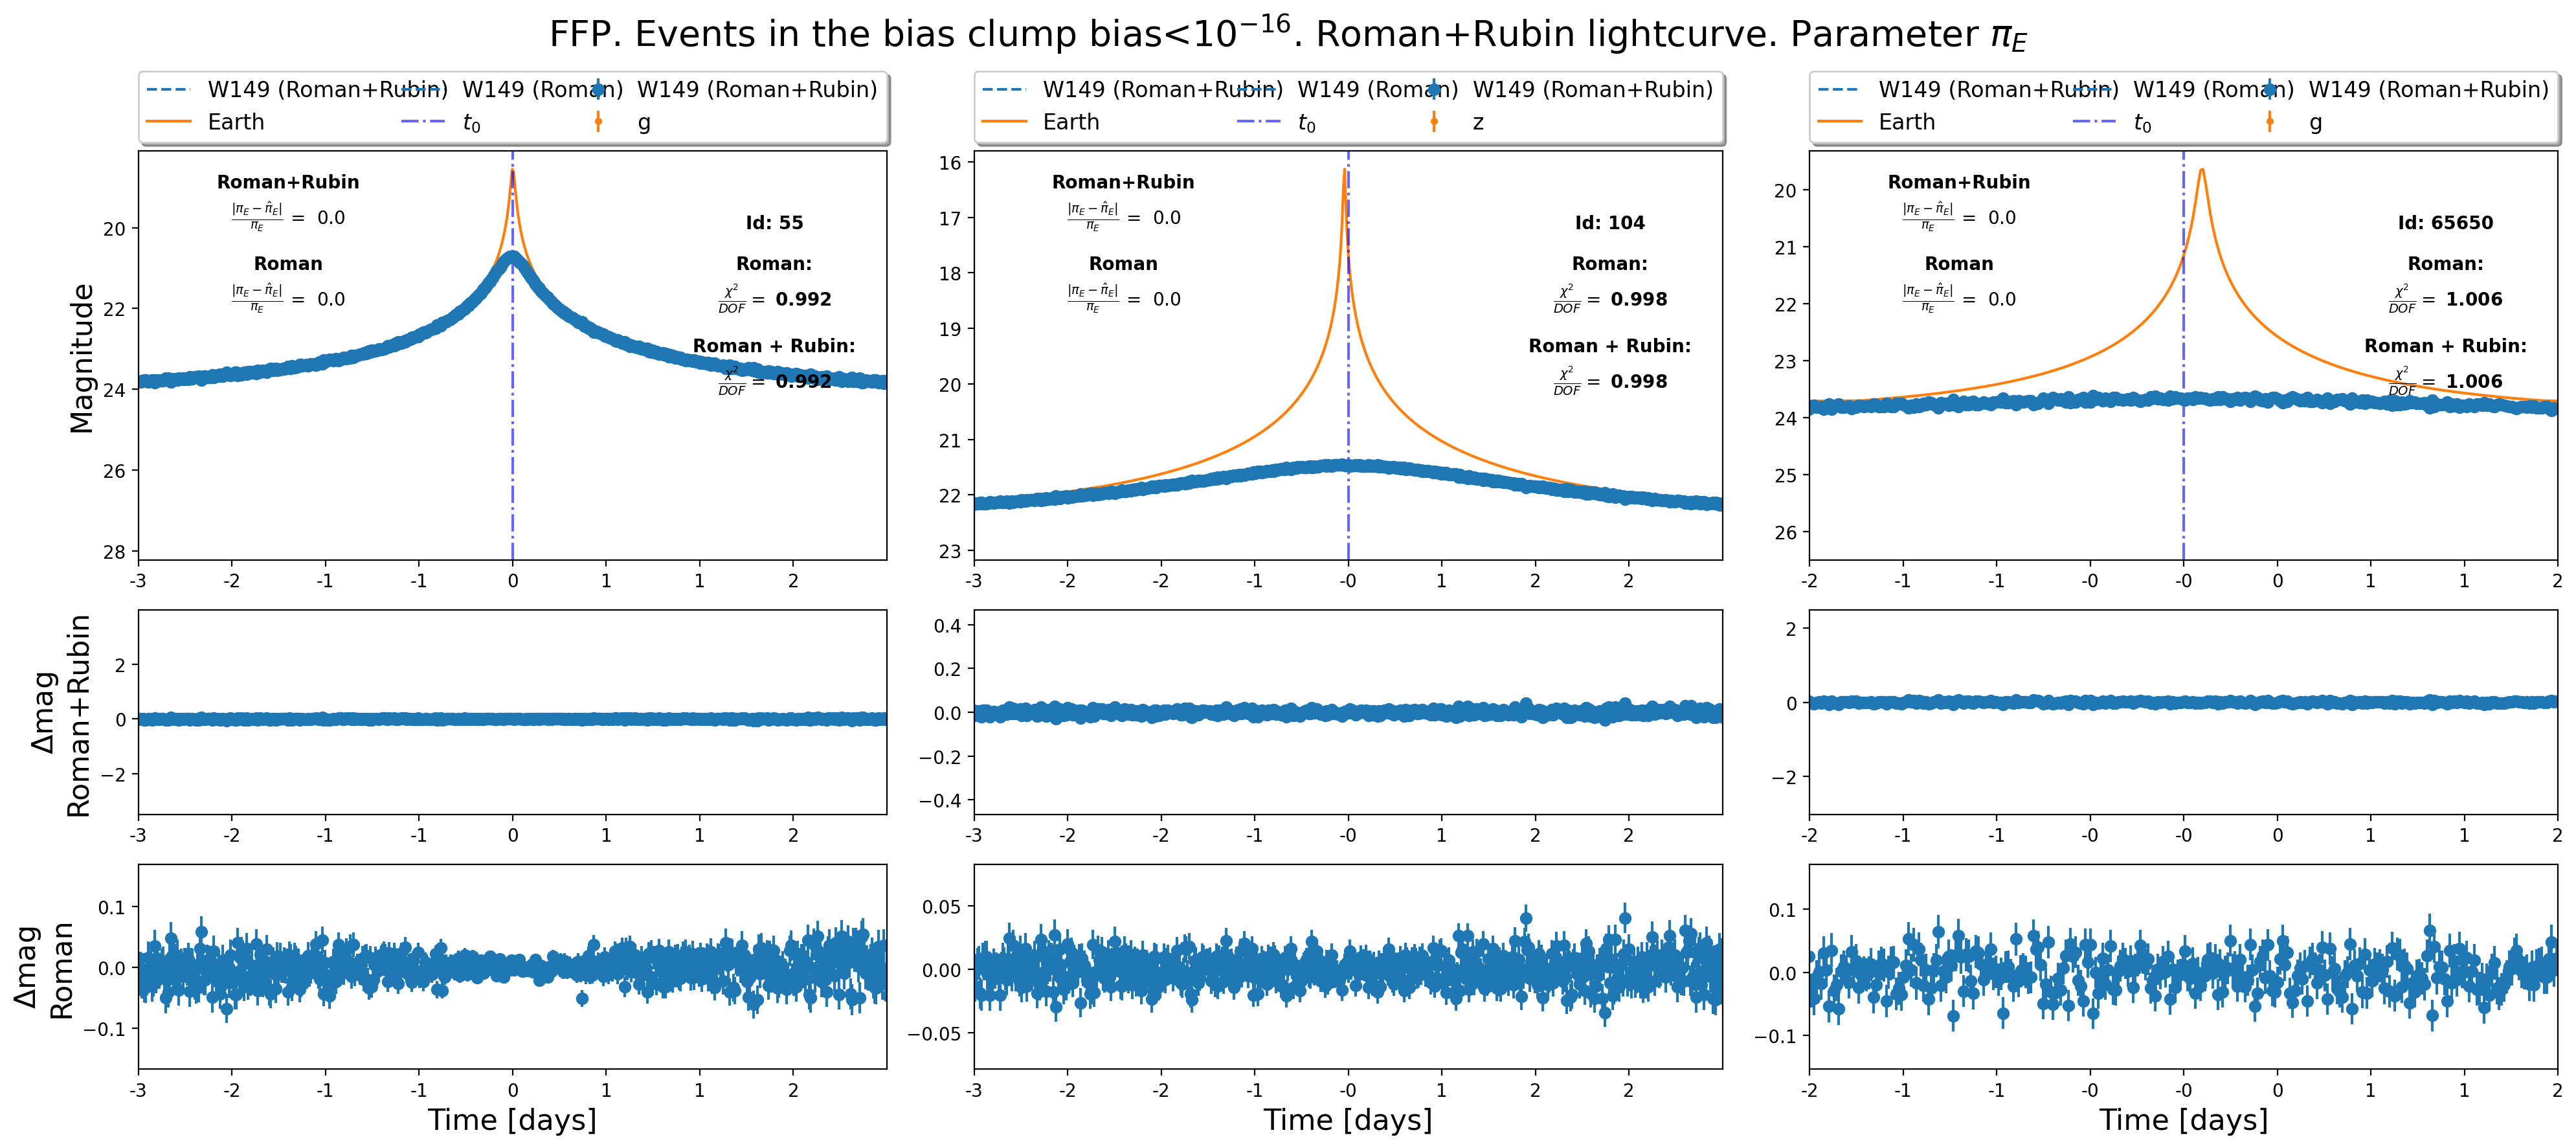

In [80]:
Class = 'FSPL'
a = df_metrics.loc[Class, 'fit_rr']['metric1']
sources = a['Source'][(a['piE']<1e-16)].values
sources = [sources[i] for i in range(3)]
download_data([sources[i] for i in range(3)], Class)
Class = 'FSPL'
# sources = [sources[i] for i in range(3)]
sets= np.array([1,1,1])

"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'FSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')
df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
df2 = df_metrics.loc[Class, 'fit_roman']['metric1']


xcoor = 0.2
bias1_rr = df1[(df1['Source']==sources[0])&(df1['Set']==sets[0])]['piE'].values[0]
bias2_rr =df1[(df1['Source']==sources[1])&(df1['Set']==sets[1])]['piE'].values[0]
bias3_rr =df1[(df1['Source']==sources[2])&(df1['Set']==sets[2])]['piE'].values[0]

bias1_roman = df2[(df2['Source']==sources[0])&(df2['Set']==sets[0])]['piE'].values[0]
bias2_roman = df2[(df2['Source']==sources[1])&(df2['Set']==sets[1])]['piE'].values[0]
bias3_roman = df2[(df2['Source']==sources[2])&(df2['Set']==sets[2])]['piE'].values[0]

axes[0,0].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {bias1_rr}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {bias2_rr}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {bias3_rr}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,0].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {bias1_roman}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {bias2_roman}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {bias3_roman}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
 
# p='piE'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# df_to_plot = create_df_to_plot(sources, Class)   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)   
plt.suptitle('FFP. Events in the bias clump bias<$10^{-16}$. Roman+Rubin lightcurve. Parameter $\pi_E$',fontsize=20)   

plt.tight_layout()  

  0%|          | 0/3 [00:00<?, ?it/s]

done
done
done
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Paral

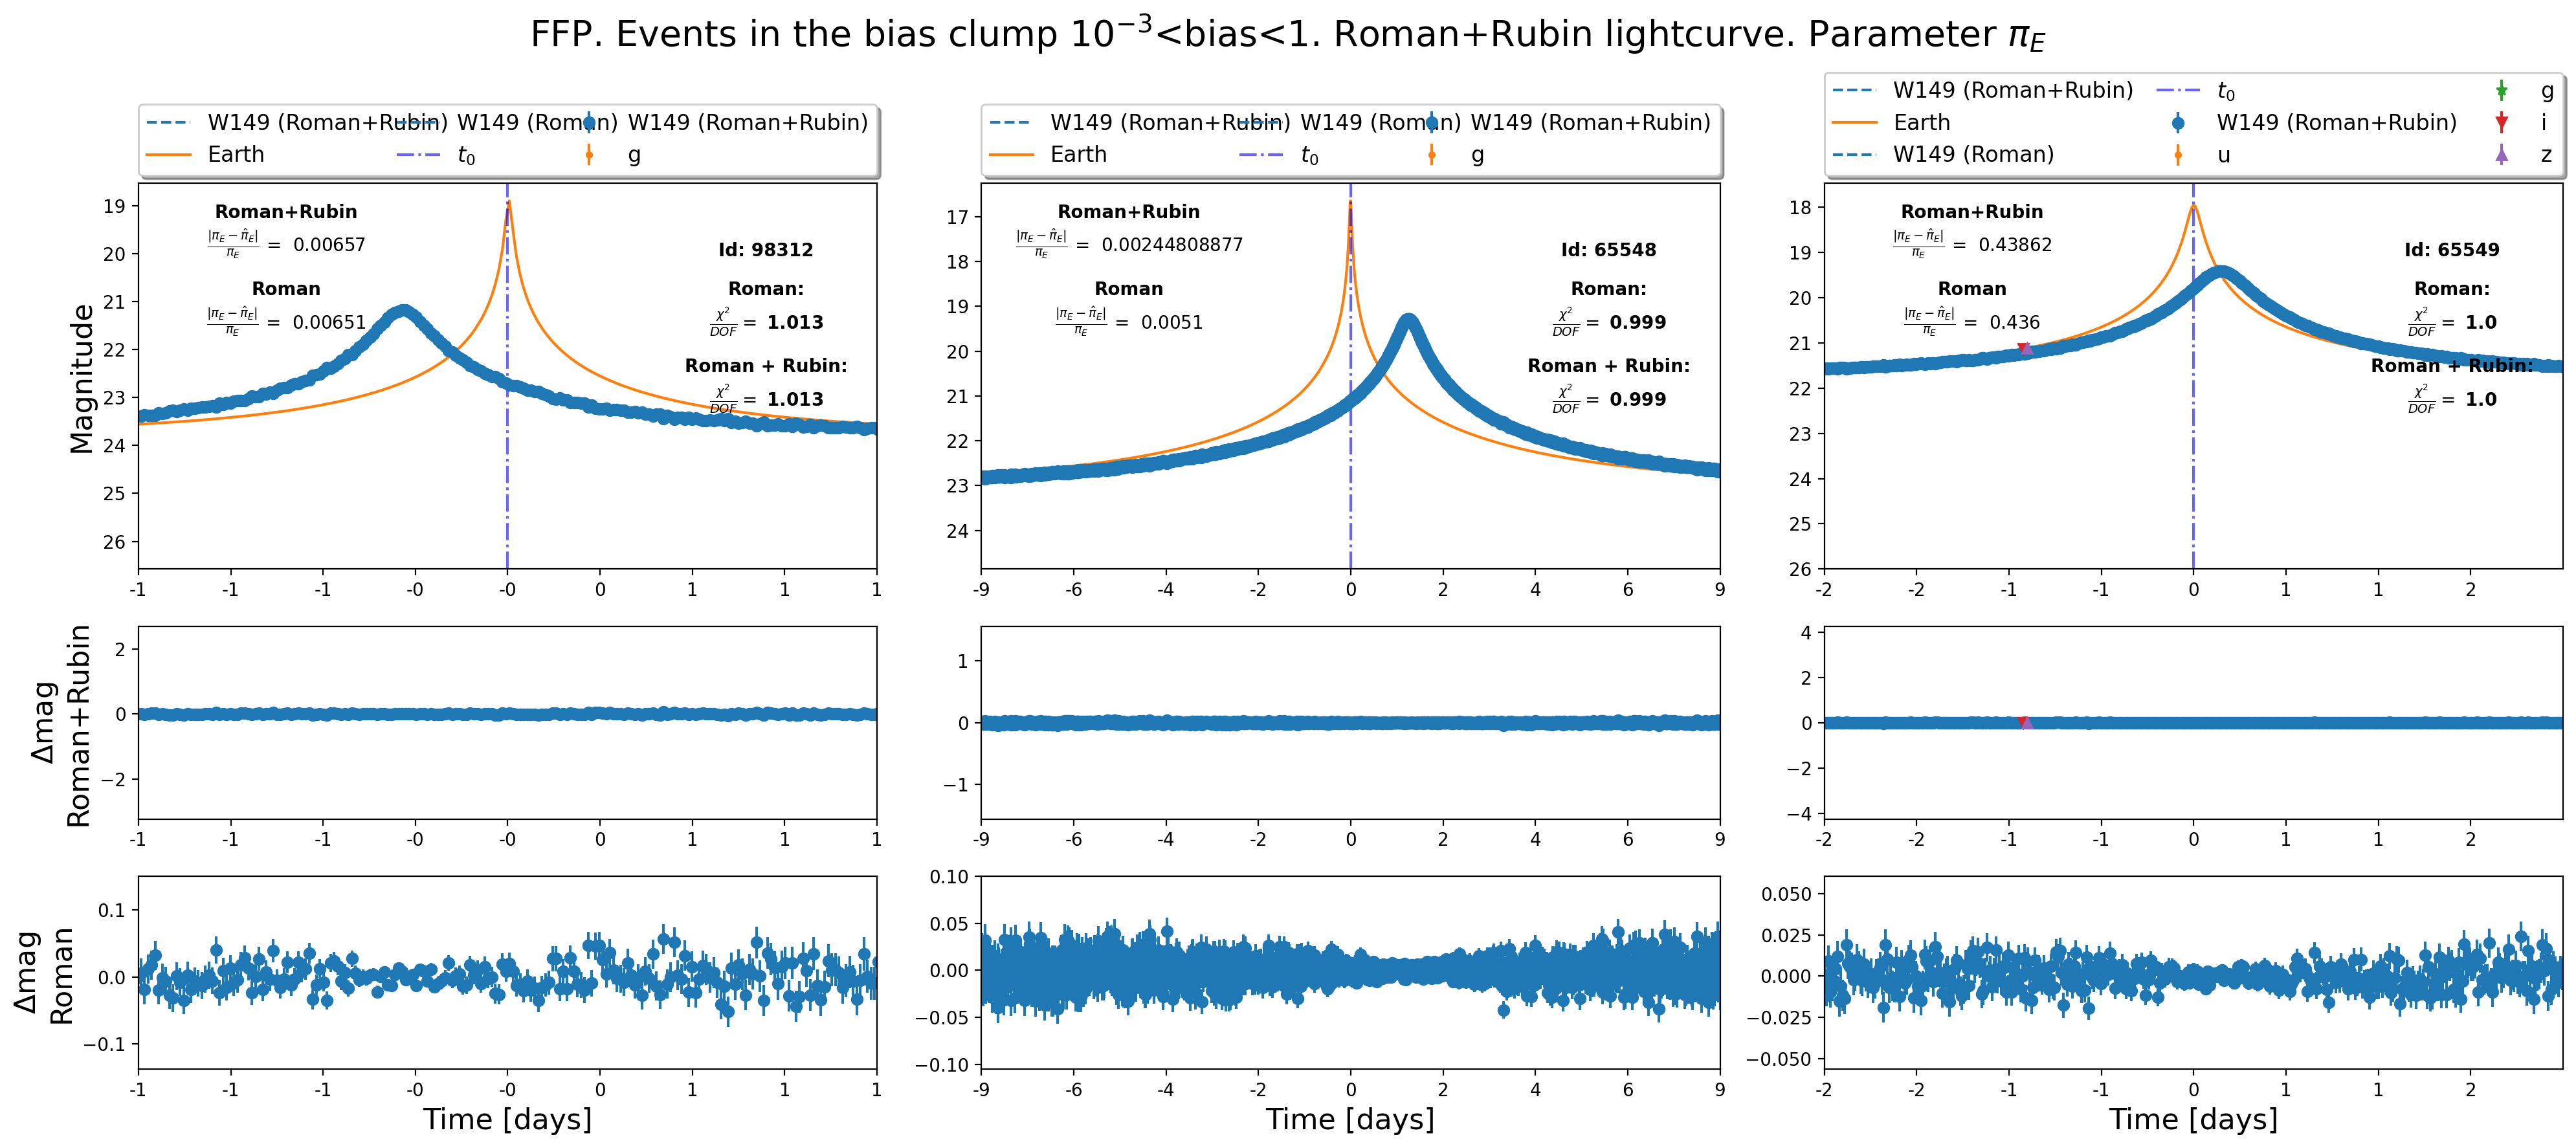

In [79]:
Class = 'FSPL'
a = df_metrics.loc[Class, 'fit_rr']['metric1']
sources = a['Source'][(a['piE']>1e-3)&(a['piE']<1)].values
sources = [sources[i] for i in range(3)]
download_data([sources[i] for i in range(3)], Class)
Class = 'FSPL'
# sources = [sources[i] for i in range(3)]
sets= np.array([1,1,1])

"""
Category B
The criterion used to select these events was the metric 
\[
\frac{|\boldsymbol{\pi}_\mathrm{E} - \hat{\boldsymbol{\pi}}_\mathrm{E}|}{\pi_\mathrm{E}} > 0.9,
\]
which lies close to the boundaries defined for maximize likelihood.
"""
df_to_plot = create_df_to_plot(sources, 'FSPL')
fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],'FSPL')
df1 = df_metrics.loc[Class, 'fit_rr']['metric1']
df2 = df_metrics.loc[Class, 'fit_roman']['metric1']


xcoor = 0.2
bias1_rr = df1[(df1['Source']==sources[0])&(df1['Set']==sets[0])]['piE'].values[0]
bias2_rr =df1[(df1['Source']==sources[1])&(df1['Set']==sets[1])]['piE'].values[0]
bias3_rr =df1[(df1['Source']==sources[2])&(df1['Set']==sets[2])]['piE'].values[0]

bias1_roman = df2[(df2['Source']==sources[0])&(df2['Set']==sets[0])]['piE'].values[0]
bias2_roman = df2[(df2['Source']==sources[1])&(df2['Set']==sets[1])]['piE'].values[0]
bias3_roman = df2[(df2['Source']==sources[2])&(df2['Set']==sets[2])]['piE'].values[0]

axes[0,0].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman+Rubin", 
             xy=(xcoor, 0.9), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_rr,11)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_rr,5)}", 
             xy=(xcoor, 0.8), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')

axes[0,0].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,1].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')
axes[0,2].annotate("Roman", 
             xy=(xcoor, 0.7), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

axes[0,0].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias1_roman,abs(round(np.log10(bias1_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,1].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias2_roman,abs(round(np.log10(bias2_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
axes[0,2].annotate(relative_bias["pi_E"]+r" = "+f" {round(bias3_roman,abs(round(np.log10(bias3_roman)))+3)}", 
             xy=(xcoor, 0.6), xycoords='axes fraction',
             ha='center', va='bottom',
             fontsize=10, fontweight='normal')
 
# p='piE'
# mask = df_metrics.loc[Class, 'fit_rr']['metric1']['Category'] == 'B'
# df1 = df_metrics.loc[Class, 'fit_rr']['metric1'][mask]
# df2 = df_metrics.loc[Class, 'fit_roman']['metric1'][mask]
# sources =df1[(df1[p]<0.25)&((df1[p]/df2[p])  <0.25)]['Source'].head(3).values
# df_to_plot = create_df_to_plot(sources, Class)   
# fig, axes = graph_maker(df_to_plot.iloc[0], df_to_plot.iloc[1], df_to_plot.iloc[2],Class)   
plt.suptitle('FFP. Events in the bias clump $10^{-3}$<bias<1. Roman+Rubin lightcurve. Parameter $\pi_E$',fontsize=20)   

plt.tight_layout()  

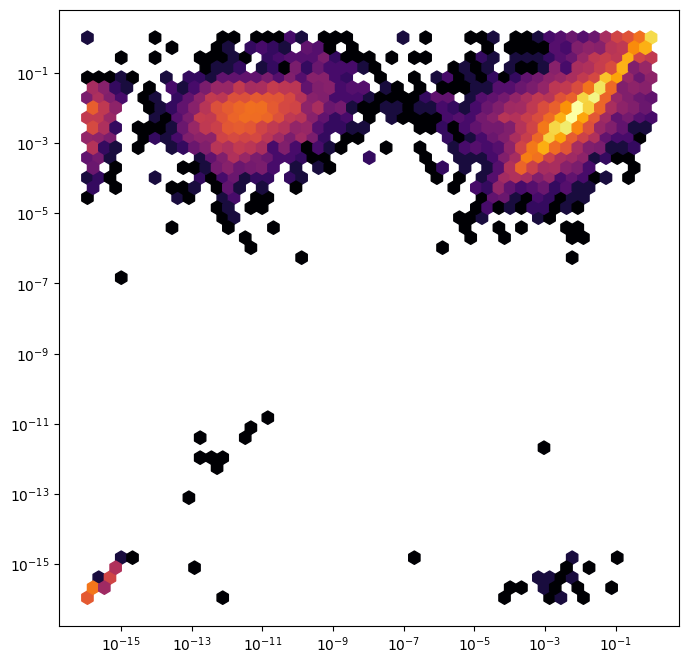

In [43]:
# plt.hist2d(df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE'],df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE'])
a = df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE']
b = df_metrics.loc['FSPL', 'fit_roman']['metric1']['piE']
mask = np.isfinite(a) & np.isfinite(b)& (a > 0) & (b > 0)
a = a[mask]
b = b[mask]

# plt.hist2d(a,b)
fig, ax_main = plt.subplots(figsize=(8, 8))

hb = ax_main.hexbin(a, b, gridsize=50, bins='log', xscale='log', yscale='log', cmap='inferno')

plt.show()

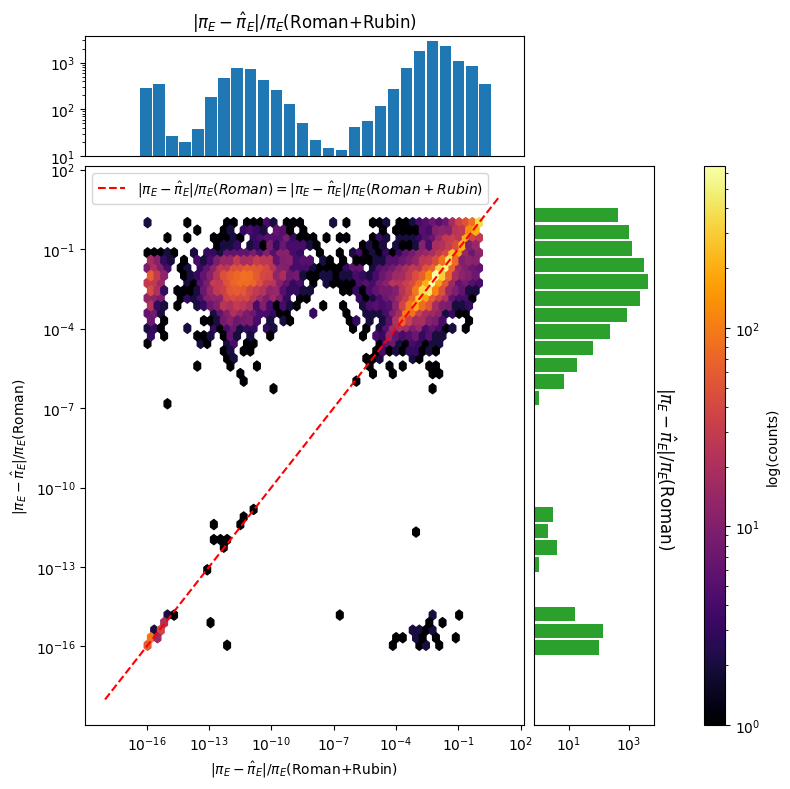

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Data cleanup
a = np.array(df_metrics.loc['FSPL', 'fit_rr']['metric1']['piE'])
b = np.array(df_metrics.loc['FSPL', 'fit_roman']['metric1']['piE'])

mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
a = a[mask]
b = b[mask]

bins = np.logspace(-17, 1.2, 30)

# Create figure and main axis
fig, ax_main = plt.subplots(figsize=(8, 8))

divider = make_axes_locatable(ax_main)
ax_top = divider.append_axes("top", 1.2, pad=0.1, sharex=ax_main)
ax_right = divider.append_axes("right", 1.2, pad=0.1, sharey=ax_main)

# Hide overlapping labels
plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_right.get_yticklabels(), visible=False)

# Main 2D plot
hb = ax_main.hexbin(a, b, gridsize=50, bins='log', xscale='log', yscale='log', cmap='inferno')
ax_main.plot([1e-18, 1e1], [1e-18, 1e1], 'r--', label=r'$|\pi_E-\hat{\pi}_E|/\pi_E (Roman) = |\pi_E-\hat{\pi}_E|/\pi_E (Roman+Rubin)$')
ax_main.set_xlabel('$|\pi_E-\hat{\pi}_E|/\pi_E$(Roman+Rubin)')
ax_main.set_ylabel('$|\pi_E-\hat{\pi}_E|/\pi_E$(Roman)')
ax_main.legend(loc='upper left')

# Add colorbar to side
cax = divider.append_axes("right", size="5%", pad=0.5)
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label('log(counts)')

# Top histogram (a) with log y-scale
ax_top.hist(a, bins=bins, color='tab:blue', rwidth=0.9)
ax_top.set_xscale('log')
ax_top.set_yscale('log')
# ax_top.set_ylabel('Count')
ax_top.set_title('$|\pi_E-\hat{\pi}_E|/\pi_E$(Roman+Rubin)')
ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

ax_right.hist(b, bins=bins, orientation='horizontal', color='tab:green', rwidth=0.9)
ax_right.set_yscale('log')
ax_right.set_xscale('log')
# ax_right.set_xlabel('Count')
ax_right.set_title('$|\pi_E-\hat{\pi}_E|/\pi_E$(Roman)', 
                   rotation=-90, 
                   x=1.1, y=0.3,
                   verticalalignment='bottom',
                   horizontalalignment='center')

ax_right.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.tight_layout()
plt.show()
